In [54]:
import os
os.environ["CRDS_PATH"] = os.path.expanduser("~/crds_cache")
os.makedirs(os.environ["CRDS_PATH"], exist_ok=True)

os.environ["CRDS_SERVER_URL"] = "https://jwst-crds.stsci.edu"
os.environ["CRDS_CONTEXT"] = "jwst_1460.pmap"

from astropy.table import Table
import numpy as np
import matplotlib.pyplot as plt
import astropy.units as u
from astroquery.svo_fps import SvoFps
from astropy.wcs import WCS
from astropy.io import fits
from dust_extinction.averages import RL85_MWGC, CT06_MWLoc
from dust_extinction.parameter_averages import CCM89




def get_mag(catalog, ww, filtername='f140m' ):
    print(ww.proj_plane_pixel_area())
    
    flux= (catalog['flux_fit_' + filtername] * u.MJy/u.sr * ww.proj_plane_pixel_area()).to(u.Jy)
    eflux_jy = (catalog['flux_err_' + filtername] * u.MJy/u.sr *  ww.proj_plane_pixel_area()).to(u.Jy)

    jfilts = SvoFps.get_filter_list('JWST')
    jfilts.add_index('filterID')
    wav = int(filtername[1:-1])

    zeropoint_ab = 3631 * u.Jy  # Default to AB magnitude zero point
 
    if wav < 500:

        zeropoint_vega = u.Quantity(jfilts.loc[f'JWST/NIRCam.{filtername.upper()}']['ZeroPoint'], u.Jy)
    else:
        zeropoint_vega = u.Quantity(jfilts.loc[f'JWST/MIRI.{filtername.upper()}']['ZeroPoint'], u.Jy)
   
    abmag = -2.5 * np.log10(flux / zeropoint_ab) * u.mag
    abmag_err = 2.5 / np.log(10) * np.abs(eflux_jy / flux) * u.mag

    vegamag = -2.5 * np.log10(flux / zeropoint_vega) * u.mag
    vegamag_err = 2.5 / np.log(10) * np.abs(eflux_jy / flux) * u.mag

    return  vegamag, vegamag_err, abmag, abmag_err


image_filenames ={
    "f140m": "/orange/adamginsburg/jwst/w51/images/jw06151-o001_t001_nircam_clear-f140m-merged_i2d.fits",
    "f162m": "/orange/adamginsburg/jwst/w51/images/jw06151-o001_t001_nircam_clear-f162m-merged_i2d.fits",
    "f182m": "/orange/adamginsburg/jwst/w51/images/jw06151-o001_t001_nircam_clear-f182m-merged_i2d.fits",
    "f187n": "/orange/adamginsburg/jwst/w51/images/jw06151-o001_t001_nircam_clear-f187n-merged_i2d.fits",
    "f210m": "/orange/adamginsburg/jwst/w51/images/jw06151-o001_t001_nircam_clear-f210m-merged_i2d.fits",
    "f335m": "/orange/adamginsburg/jwst/w51/images/jw06151-o001_t001_nircam_clear-f335m-merged_i2d.fits",
    "f360m": "/orange/adamginsburg/jwst/w51/images/jw06151-o001_t001_nircam_clear-f360m-merged_i2d.fits",
    "f405n": "/orange/adamginsburg/jwst/w51/images/jw06151-o001_t001_nircam_clear-f405n-merged_i2d.fits",
    "f410m": "/orange/adamginsburg/jwst/w51/images/jw06151-o001_t001_nircam_clear-f410m-merged_i2d.fits", # weird, the filename is different from what is downloaded with the STScI pipeline...
    "f480m": "/orange/adamginsburg/jwst/w51/images/jw06151-o001_t001_nircam_clear-f480m-merged_i2d.fits",
    "f560w": "/orange/adamginsburg/jwst/w51/F560W/pipeline/jw06151-o002_t001_miri_f560w_i2d.fits",
    "f770w": "/orange/adamginsburg/jwst/w51/F770W/pipeline/jw06151-o002_t001_miri_f770w_i2d.fits",
    "f1000w": "/orange/adamginsburg/jwst/w51/F1000W/pipeline/jw06151-o002_t001_miri_f1000w_i2d.fits",
    "f1280w": "/orange/adamginsburg/jwst/w51/F1280W/pipeline/jw06151-o002_t001_miri_f1280w_i2d.fits",
    "f2100w": "/orange/adamginsburg/jwst/w51/F2100W/pipeline/jw06151-o002_t001_miri_f2100w_i2d.fits",
    
}
catalog = Table.read('/orange/adamginsburg/w51/TaehwaYoo/jwst_w51/catalogs/final_catalog_cfitcut.fits')
nmatch = catalog['nmatch_bands']
catalog = catalog[nmatch>3]
print(catalog.colnames)


f140m_header = fits.getheader(image_filenames['f140m'], ext=('SCI', 1))
f162m_header = fits.getheader(image_filenames['f162m'], ext=('SCI', 1))
f182m_header = fits.getheader(image_filenames['f182m'], ext=('SCI', 1))
f210m_header = fits.getheader(image_filenames['f210m'], ext=('SCI', 1))
f335m_header = fits.getheader(image_filenames['f335m'], ext=('SCI', 1))
f360m_header = fits.getheader(image_filenames['f360m'], ext=('SCI', 1))
f405n_header = fits.getheader(image_filenames['f405n'], ext=('SCI', 1))
f410m_header = fits.getheader(image_filenames['f410m'], ext=('SCI', 1))
f480m_header = fits.getheader(image_filenames['f480m'], ext=('SCI', 1))
f560w_header = fits.getheader(image_filenames['f560w'], ext=('SCI', 1))
f770w_header = fits.getheader(image_filenames['f770w'], ext=('SCI', 1))
f1000w_header = fits.getheader(image_filenames['f1000w'], ext=('SCI', 1))
f1280w_header = fits.getheader(image_filenames['f1280w'], ext=('SCI', 1))
f2100w_header = fits.getheader(image_filenames['f2100w'], ext=('SCI', 1))



f140m_mag = get_mag(catalog, WCS(f140m_header), filtername='f140m')
f162m_mag = get_mag(catalog, WCS(f162m_header), filtername='f162m')
f182m_mag = get_mag(catalog, WCS(f182m_header), filtername='f182m')
f210m_mag = get_mag(catalog, WCS(f210m_header), filtername='f210m')
f335m_mag = get_mag(catalog, WCS(f335m_header), filtername='f335m')
f360m_mag = get_mag(catalog, WCS(f360m_header), filtername='f360m')
f405n_mag = get_mag(catalog, WCS(f405n_header), filtername='f405n')
f410m_mag = get_mag(catalog, WCS(f410m_header), filtername='f410m')
f480m_mag = get_mag(catalog, WCS(f480m_header), filtername='f480m')
f560w_mag = get_mag(catalog, WCS(f560w_header), filtername='f560w')
f770w_mag = get_mag(catalog, WCS(f770w_header), filtername='f770w')
f1000w_mag = get_mag(catalog, WCS(f1000w_header), filtername='f1000w')
f1280w_mag = get_mag(catalog, WCS(f1280w_header), filtername='f1280w')
f2100w_mag = get_mag(catalog, WCS(f2100w_header), filtername='f2100w')

f187n_header = fits.getheader(image_filenames['f187n'], ext=('SCI', 1))
f187n_mag = get_mag(catalog, WCS(f187n_header), filtername='f187n')


num_sources = len(catalog)

from dust_extinction.averages import RL85_MWGC, CT06_MWGC
from dust_extinction.parameter_averages import CCM89
import astropy.constants as const

ext = CT06_MWLoc()
def plot_extvec_cmd(ax, color1, mag1, ext=CT06_MWGC(), extvec_scale=200, start=None,
                    color='y', head_width=0.5, color1_data=None, mag1_data=None, label=None, fontsize=15):
    def get_wave(c):
        if c == '410m405': return 4.10*u.um
        if c == '405m410': return 4.05*u.um
        if c == 'Hmag': return 1.634*u.um
        if c == 'Ksmag': return 2.143527*u.um
        return int(c[1:-1])/100*u.um

    w1 = get_wave(color1[0])
    w2 = get_wave(color1[1])
    w3 = get_wave(mag1[0])

    if w1 > w2:
        w1, w2 = w2, w1
        color1 = color1[::-1]
    print(w1,w2,w3)

    # Only plot if all are in valid range
    try:
        e_1 = ext(1/w1) * extvec_scale
        e_2 = ext(1/w2) * extvec_scale
        e_3 = ext(1/w3) * extvec_scale
    except ValueError as e:
        print(f"Extinction vector not plotted: {e}")
        return
    print(w1,w2,w3)
    print(e_1, e_2, e_3)
    if start == None:
        mean_color1 = np.nanmean(color1_data)
        mean_mag1 = np.nanmean(mag1_data)
        std_color1 = np.nanstd(color1_data)
        std_mag1 = np.nanstd(mag1_data)
        if e_1 - e_2 < 0:
            std_color1 *= -1
        
    
        start2 = (mean_color1 + 2*std_color1, mean_mag1 + 2*std_mag1)
    else:
        start2 = start
    
    # Strip units for plotting if present
    if hasattr(start2[0], 'value'):
        start2_x = start2[0].value
        start2_y = start2[1].value
    else:
        start2_x = start2[0]
        start2_y = start2[1]

    ax.annotate(f'$A_V={extvec_scale}$', xy=(start2_x + (e_1 - e_2), start2_y + e_3),
                xytext=(start2_x, start2_y), fontsize=15,
                arrowprops=dict(arrowstyle='-|>', color=color,
                                shrinkA=0, shrinkB=0,
                                mutation_scale=20, linewidth=1.5))
    if label is not None:
        ax.plot([], [], color=color, marker='>', markersize=8,
                label=f'{label}', linestyle='-', linewidth=2)

    else:
        ax.plot([], [], color=color, marker='>', markersize=8,
                linestyle='-', linewidth=2)

imgsavedir = '/orange/adamginsburg/w51/TaehwaYoo/jwst_w51/plots/cmds/'
mags = {
    'f140m': f140m_mag,
    'f162m': f162m_mag,
    'f182m': f182m_mag,
    'f187n': f187n_mag,
    'f210m': f210m_mag,
    'f335m': f335m_mag,
    'f360m': f360m_mag,
    'f405n': f405n_mag,
    'f410m': f410m_mag,
    'f480m': f480m_mag,
    'f560w': f560w_mag,
    'f770w': f770w_mag,
    'f1000w': f1000w_mag,
    'f1280w': f1280w_mag,
    'f2100w': f2100w_mag,
}
filter_names = list(mags.keys())



['skycoord_ref', 'skycoord_ref_filtername', 'sep_f140m', 'id_f140m', 'skycoord_f140m', 'flux_fit_f140m', 'flux_err_f140m', 'mask_f140m', 'qfit_f140m', 'cfit_f140m', 'local_bkg_f140m', 'roundness1_f140m', 'roundness2_f140m', 'sharpness_f140m', 'from_sat_catalog_f140m', 'std_ra_f140m', 'std_dec_f140m', 'nmatch_f140m', 'nmatch_good_f140m', 'flux_err_prop_f140m', 'sep_f162m', 'id_f162m', 'skycoord_f162m', 'flux_fit_f162m', 'flux_err_f162m', 'mask_f162m', 'qfit_f162m', 'cfit_f162m', 'local_bkg_f162m', 'roundness1_f162m', 'roundness2_f162m', 'sharpness_f162m', 'from_sat_catalog_f162m', 'std_ra_f162m', 'std_dec_f162m', 'nmatch_f162m', 'nmatch_good_f162m', 'flux_err_prop_f162m', 'sep_f182m', 'id_f182m', 'skycoord_f182m', 'flux_fit_f182m', 'flux_err_f182m', 'mask_f182m', 'qfit_f182m', 'cfit_f182m', 'local_bkg_f182m', 'roundness1_f182m', 'roundness2_f182m', 'sharpness_f182m', 'from_sat_catalog_f182m', 'std_ra_f182m', 'std_dec_f182m', 'nmatch_f182m', 'nmatch_good_f182m', 'flux_err_prop_f182m', 's

 col1    col2  col3      col4          col5       col6   col7   col8   col9  col10 col11 col12   col13  col14  col15  col16  col17  col18   col19   col20   col21   col22    col23     col24     col25   col26   col27   col28   col29   col30   col31   col32   col33   col34   col35   col36   col37   col38   col39   col40   col41   col42   col43   col44   col45   col46   col47   col48   col49   col50 
------ ------- ---- -------------- ------------ ------- ------ ------ ------ ----- ----- ------ ------- ------ ------ ------ ------ ----- --------- ----- --------- ------ --------- --------- --------- ------ ------- ------- ------- ------- ------- ------- ------- ------- ------- ------- ------- ------- ------- ------- ------- ------- ------- ------- ------- ------- ------- ------- ------- -------
0.0207 0.15867  5.0   0.0908484459 1.0897678296   0.091  -0.78 3.4382  2.881     0   0.0  0.545     0.0    0.0    0.0    0.0    0.0    -1 -2.54e-13   0.0    0.6936 0.2855  0.003749  0.001011  0.009172

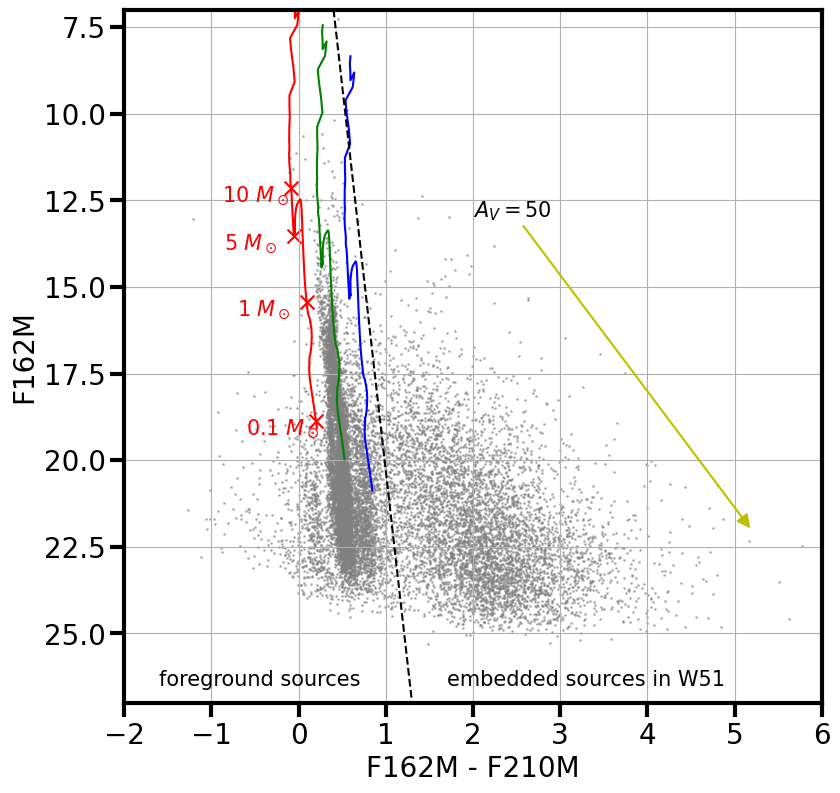

In [55]:
import matplotlib as mpl
from matplotlib.path import Path
from astropy.table import Table
import crds
parsec_av0 = Table.read('/home/t.yoo/parsec_av0.txt', format='ascii')
parsec_av0.pprint(max_width=-1, max_lines=-1)   
m_init = parsec_av0['col4']  
parsec_av0 = parsec_av0[m_init<300]              
logage_av0 = parsec_av0['col3']
mass_av0 = parsec_av0['col6']
print(np.min(m_init), np.max(m_init))
print(np.min(mass_av0), np.max(mass_av0))
F140Mmag_av0 = parsec_av0['col39'] + 5*np.log10(5400)-5
F162Mmag_av0 = parsec_av0['col40']+ 5*np.log10(5400)-5
F182Mmag_av0 = parsec_av0['col41']+ 5*np.log10(5400)-5
F210Mmag_av0 = parsec_av0['col42']+ 5*np.log10(5400)-5
F335Mmag_av0 = parsec_av0['col45']+ 5*np.log10(5400)-5
F360Mmag_av0 = parsec_av0['col46']+ 5*np.log10(5400)-5
F410Mmag_av0 = parsec_av0['col47']+ 5*np.log10(5400)-5
F480Mmag_av0 = parsec_av0['col50']+ 5*np.log10(5400)-5

parsec_miri = Table.read('/blue/adamginsburg/t.yoo/w51_nircam/parsec_miri.dat', format='ascii')
parsec_miri.pprint(max_width=-1, max_lines=-1)
parsec_miri = parsec_miri[parsec_miri['col4']<300]
F560Wmag_av0 = parsec_miri['col38']+ 5*np.log10(5400)-5
F770Wmag_av0 = parsec_miri['col39']+ 5*np.log10(5400)-5

plt.rcParams['axes.labelsize']=20 
plt.rcParams['xtick.labelsize']=20
plt.rcParams['ytick.labelsize']=20
plt.rcParams['axes.titlesize']=20
mpl.rcParams['axes.linewidth'] = 3
plt.rcParams['xtick.major.size'] = 10
plt.rcParams['xtick.major.width'] = 3
plt.rcParams['ytick.major.size'] = 10
plt.rcParams['ytick.major.width'] = 3

fig = plt.figure(figsize=(9, 9))
ax = fig.add_subplot(111)
ax.scatter(f162m_mag[0] - f210m_mag[0], f162m_mag[0], s=1, c='gray', alpha=0.5)

age_idx = logage_av0 == 6
ax.plot(F162Mmag_av0[age_idx] - F210Mmag_av0[age_idx], F162Mmag_av0[age_idx], color='r')

ext = CT06_MWLoc()
#plot isochrone with Av=10
ax.plot(F162Mmag_av0[age_idx] - F210Mmag_av0[age_idx]  + (ext(1/1.62/u.um) - ext(1/2.10/u.um))*5,
F162Mmag_av0[age_idx]+(ext(1/1.62/u.um))*5, color='g')
ax.plot(F162Mmag_av0[age_idx] - F210Mmag_av0[age_idx]  + (ext(1/1.62/u.um) - ext(1/2.10/u.um))*10, 
F162Mmag_av0[age_idx]+(ext(1/1.62/u.um))*10, color='b')

idx_01msun = np.argmin(np.abs(mass_av0[age_idx]-0.1))
idx_20msun = np.argmin(np.abs(mass_av0[age_idx]-20))
print(F140Mmag_av0)
print('age_idx:', age_idx, 'idx_01msun:', idx_01msun, 'idx_20msun:', idx_20msun)
isochrone_x_start = F140Mmag_av0[age_idx][idx_01msun] - F210Mmag_av0[age_idx][idx_01msun]
isochrone_x_end = F140Mmag_av0[age_idx][idx_20msun] - F210Mmag_av0[age_idx][idx_20msun]
isocrhone_y_start = F140Mmag_av0[age_idx][idx_01msun]
isocrhone_y_end = F140Mmag_av0[age_idx][idx_20msun]
color_slope = (isocrhone_y_end - isocrhone_y_start) / (isochrone_x_end - isochrone_x_start)
color_intercept = isocrhone_y_start - color_slope * isochrone_x_start

A_K_scale = 5
A_V_scale = A_K_scale * 10
#ax.plot([isochrone_x_start, isochrone_x_end], [isocrhone_y_start, isocrhone_y_end], color='r', linestyle='--')
#ax1.plot([isochrone_x_start+(ext(1/1.82/u.um)-ext(1/2.10/u.um))*A_V_scale, isochrone_x_end+(ext(1/1.82/u.um)-ext(1/2.10/u.um))*A_V_scale], 
#[isocrhone_y_start+(ext(1/1.82/u.um))*A_V_scale, isocrhone_y_end+(ext(1/1.82/u.um))*A_V_scale], color='r', linestyle='--')
# extrapolate the linear part of the isochrone to the left and right by 0.5 mag in color

# and plot
#x_vals = np.array([-1, 2])
#y_vals = color_slope * x_vals + color_intercept
#ax.plot(x_vals, y_vals, color='r', linestyle='--')
for mass in [0.1, 1, 5, 10]:
    idx_mass = np.argmin(np.abs(mass_av0[age_idx]-mass))
    ax.scatter(F162Mmag_av0[age_idx][idx_mass] - F210Mmag_av0[age_idx][idx_mass], F162Mmag_av0[age_idx][idx_mass], color='r', marker='x', s=100)
    ax.annotate(f'{mass} $M_\odot$', (F162Mmag_av0[age_idx][idx_mass] - F210Mmag_av0[age_idx][idx_mass], F162Mmag_av0[age_idx][idx_mass]), textcoords="offset points", xytext=(-50,-10), ha='left', color='r', fontsize=15)
plot_extvec_cmd(ax, ('f162m', 'f210m'), ('f162m',), extvec_scale=50, start=(2,13))

#ax.text(-0.2, 11, r'$A_V$=0', fontsize=15, color='r')
#ax.text(0.1, 12, r'$A_V$=5', fontsize=15, color='g')
#ax.text(0.5, 13, r'$A_V$=10', fontsize=15, color='b')

ax.text(1.7, 26.5, 'embedded sources in W51', fontsize=15, color='k')
ax.text(-1.6, 26.5, 'foreground sources', fontsize=15, color='k')
#ax.annotate('embedded sources in W51', xy=(2, 26.5), xytext=(1.4, 26.5), ha='left', color='k', fontsize=15)
#ax.annotate('foreground sources', xy=(0, 26.5), xytext=(1, 26.5), ha='left', color='k', fontsize=15)
ax.plot([0.4,1.3], [7, 27], c='k', ls='dashed')
ax.set_xlabel('F162M - F210M')
ax.set_ylabel('F162M')
ax.set_ylim(27,7)
ax.set_xlim(-2,6)
ax.grid()
plt.savefig('cmd_cfit003.png', bbox_inches='tight')
plt.show()





In [56]:
def get_av(color, mag, ext=CT06_MWLoc(), color1=('f140m', 'f162m'), mag1=('f140m',), isochrone_line_params=None):
    # Get the slope and intercept of the isochrone line
    m_iso, b_iso = isochrone_line_params
    print('color1:', color1, 'mag1:', mag1)

    # Get the extinction vector components
    w_color1_1 = int(color1[0][1:-1])/100*u.um
    w_color1_2 = int(color1[1][1:-1])/100*u.um
    w_mag1 = int(mag1[0][1:-1])/100*u.um
    print('w_color1_1:', w_color1_1, 'w_color1_2:', w_color1_2, 'w_mag1:', w_mag1)

    e_color1_1 = ext(1/w_color1_1)
    e_color1_2 = ext(1/w_color1_2)
    e_mag1 = ext(1/w_mag1)

    # get the contact to the isochrone line along the extinction vector
    # the extinction vector can be represented as a line with slope m_ext = e_mag1 / (e_color1_1 - e_color1_2) and passing through the point (color, mag)
    m_ext = e_mag1 / (e_color1_1 - e_color1_2)
    b_ext = mag - m_ext * color

    # find the intersection of the isochrone line and the extinction vector
    x_int = (b_ext - b_iso) / (m_iso - m_ext)
    y_int = m_iso * x_int + b_iso

    # calculate A_V as the distance from (color, mag) to (x_int, y_int) along the extinction vector
    av = (mag - y_int) / ext(1/w_mag1)
    av[av < 0] = 0
    return av
parsec_mags = {
    'f140m': F140Mmag_av0,
    'f162m': F162Mmag_av0,
    'f182m': F182Mmag_av0,
    'f210m': F210Mmag_av0,
    'f335m': F335Mmag_av0,
    'f360m': F360Mmag_av0,
    'f410m': F410Mmag_av0,
    'f480m': F480Mmag_av0,
    'f560w': F560Wmag_av0,
    'f770w': F770Wmag_av0,
}

f162 = f162m_mag[0].to_value(u.mag)
f210 = f210m_mag[0].to_value(u.mag)
f360 = f360m_mag[0].to_value(u.mag)
f480 = f480m_mag[0].to_value(u.mag)
isochrone_x_start = parsec_mags['f162m'][age_idx][idx_01msun] - parsec_mags['f210m'][age_idx][idx_01msun]
isochrone_x_end = parsec_mags['f162m'][age_idx][idx_20msun] - parsec_mags['f210m'][age_idx][idx_20msun]
isochrone_y_start = parsec_mags['f162m'][age_idx][idx_01msun]
isochrone_y_end = parsec_mags['f162m'][age_idx][idx_20msun]

color_slope = (isochrone_y_end - isochrone_y_start) / (isochrone_x_end - isochrone_x_start)
color_intercept = isochrone_y_start - color_slope * isochrone_x_start
av_estimate = get_av(f162 - f210, f162, ext=CT06_MWLoc(), color1=('f162m', 'f210m'), mag1=('f162m',), isochrone_line_params=(color_slope, color_intercept))


color1: ('f162m', 'f210m') mag1: ('f162m',)
w_color1_1: 1.62 um w_color1_2: 2.1 um w_mag1: 1.62 um


1.62 um 2.1 um 1.62 um
1.62 um 2.1 um 1.62 um
8.970550123456789 5.7899519999999995 8.970550123456789


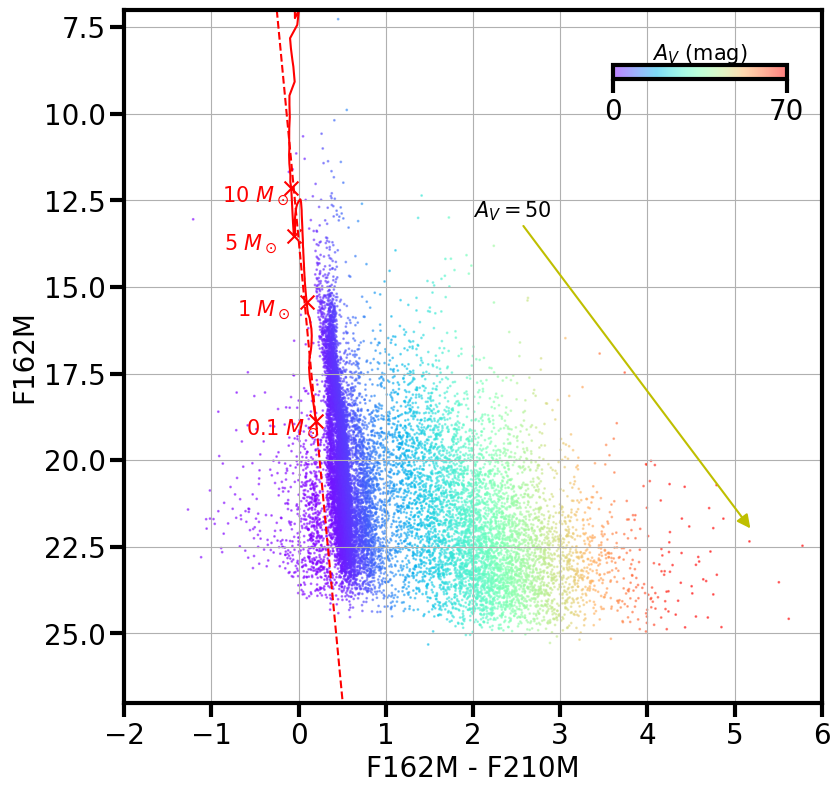

In [57]:
fig = plt.figure(figsize=(9, 9))
ax = fig.add_subplot(111)
av_norm = mpl.colors.Normalize(vmin=0, vmax=70)
xarr = np.linspace(-2, 6, 100)
im = ax.scatter(f162 - f210, f162, s=1, c=av_estimate, cmap='rainbow', alpha=0.5, norm=av_norm)
ax.plot(F162Mmag_av0[age_idx] - F210Mmag_av0[age_idx], F162Mmag_av0[age_idx], color='r')
ax.plot(xarr, xarr*color_slope + color_intercept, color='r', linestyle='--')

# plot colobar in the inset using bbox

cax = ax.inset_axes([0.7, 0.9, 0.25, 0.02], transform=ax.transAxes)  
cbar = plt.colorbar(im, cax=cax, pad=0.05, orientation='horizontal')
cbar.set_ticks([0, 70])
cbar.set_label(r'$A_V$ (mag)', fontsize=15)
cbar.ax.xaxis.set_label_position('top')

for mass in [0.1, 1, 5, 10]:
    idx_mass = np.argmin(np.abs(mass_av0[age_idx]-mass))
    ax.scatter(F162Mmag_av0[age_idx][idx_mass] - F210Mmag_av0[age_idx][idx_mass], F162Mmag_av0[age_idx][idx_mass], color='r', marker='x', s=100)
    ax.annotate(f'{mass} $M_\odot$', (F162Mmag_av0[age_idx][idx_mass] - F210Mmag_av0[age_idx][idx_mass], F162Mmag_av0[age_idx][idx_mass]), textcoords="offset points", xytext=(-50,-10), ha='left', color='r', fontsize=15)
plot_extvec_cmd(ax, ('f162m', 'f210m'), ('f162m',), extvec_scale=50, start=(2,13))
ax.set_xlabel('F162M - F210M')
ax.set_ylabel('F162M')
ax.set_ylim(27,7)
ax.set_xlim(-2,6)
ax.grid()
plt.savefig('cmd_av_cfit003.png', bbox_inches='tight')
plt.show()

Text(0, 0.5, 'Number of sources')

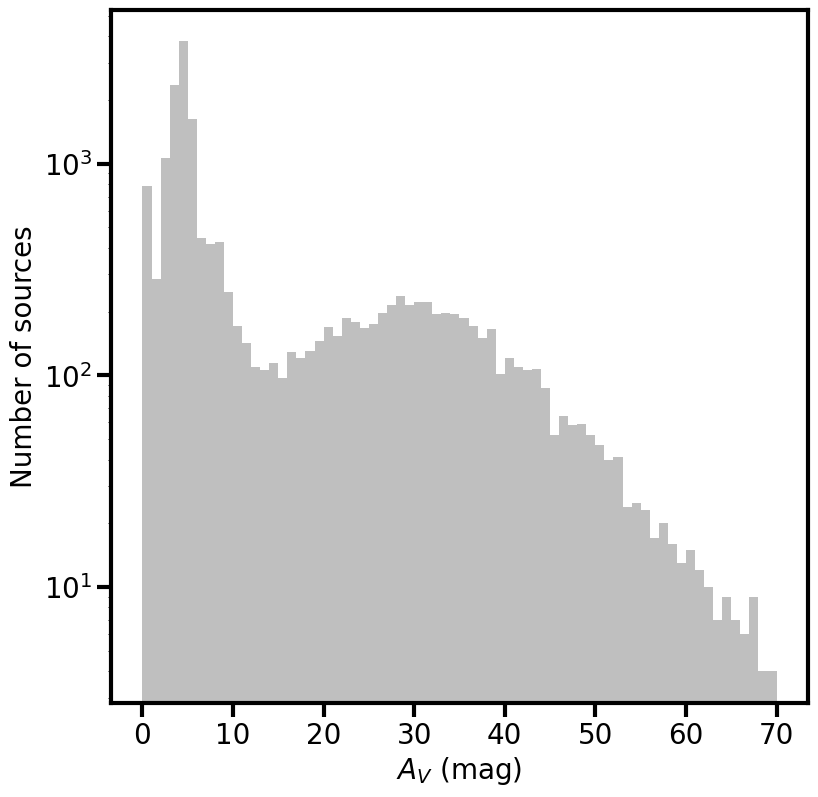

In [58]:
fig = plt.figure(figsize=(9, 9))
ax = fig.add_subplot(111)
ax.hist(av_estimate, bins=np.arange(0, 71, 1), color='gray', alpha=0.5)
ax.set_yscale('log')
ax.set_xlabel(r'$A_V$ (mag)')
ax.set_ylabel('Number of sources')

Best n_components (BIC): 3
Model: CT06_MWLoc
Inputs: ('x',)
Outputs: ('y',)
Model set size: 1
Parameters:
1.62 um 2.1 um 3.6 um 4.8 um
1.62 um 2.1 um 3.6 um 4.8 um
5.382330074074073 3.4739712 1.7993024000000004 1.454796
Model: RL85_MWGC
Inputs: ('x',)
Outputs: ('y',)
Model set size: 1
Parameters:
1.62 um 2.1 um 3.6 um 4.8 um
1.62 um 2.1 um 3.6 um 4.8 um
5.4357638888888875 3.6726315789473687 1.6323076923076927 0.69
Model: G21_MWAvg
Inputs: ('x',)
Outputs: ('y',)
Model set size: 1
Parameters:
1.62 um 2.1 um 3.6 um 4.8 um
1.62 um 2.1 um 3.6 um 4.8 um
5.377005929042962 3.662529750810622 1.6526084768147404 1.0894231111576114
Model: RRP89_MWGC
Inputs: ('x',)
Outputs: ('y',)
Model set size: 1
Parameters:
1.62 um 2.1 um 3.6 um 4.8 um
1.62 um 2.1 um 3.6 um 4.8 um
5.15745734947461 3.598397287717673 1.9293004729897925 0.9708737864077621
Model: G24_SMCAvg
Inputs: ('x',)
Outputs: ('y',)
Model set size: 1
Parameters:
1.62 um 2.1 um 3.6 um 4.8 um
Extinction vector not plotted: Input x outside of rang

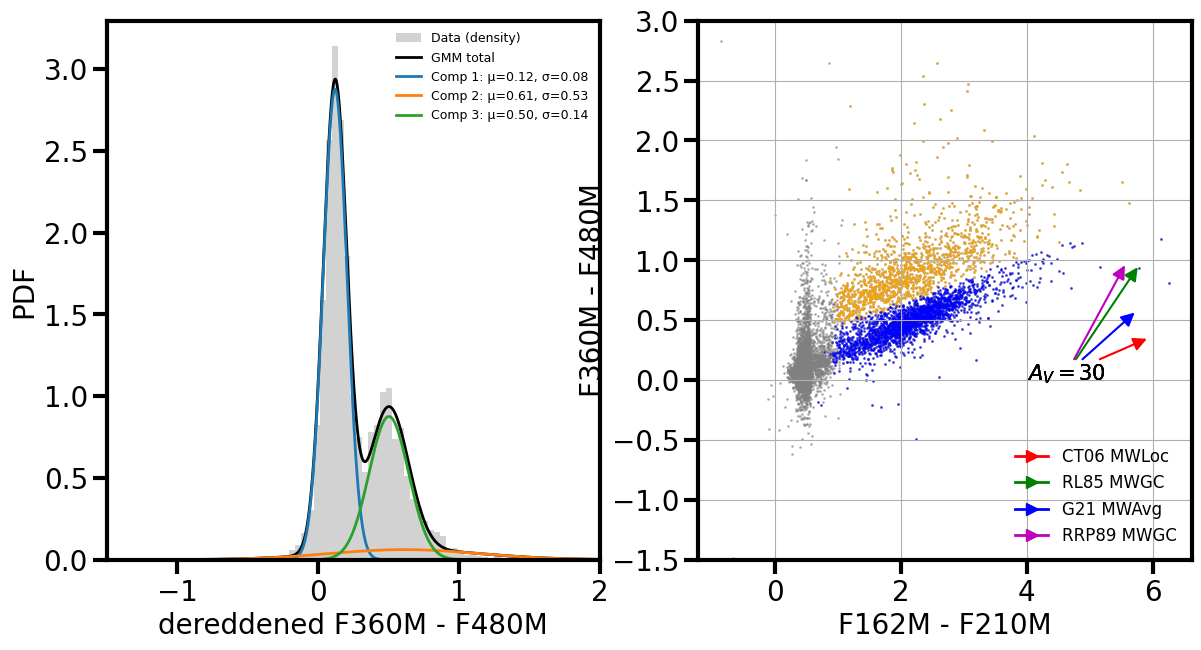

In [59]:
from dust_extinction.averages import RL85_MWGC, CT06_MWLoc, G21_MWAvg,RRP89_MWGC, G24_SMCAvg
from sklearn.mixture import GaussianMixture

def plot_extvec_ccd(ax, color1, color2, ext=CT06_MWLoc(), extvec_scale=30, start=None,
                    color='y', head_width=0.5, color1_data=None, color2_data=None, label=None, fontsize=15):
    def get_wave(c):
        if c == '410m405': return 4.10*u.um
        if c == '405m410': return 4.05*u.um
        if c == 'Hmag': return 1.634*u.um
        if c == 'Ksmag': return 2.143527*u.um
        return int(c[1:-1])/100*u.um

    w1 = get_wave(color1[0])
    w2 = get_wave(color1[1])
    w3 = get_wave(color2[0])
    w4 = get_wave(color2[1])

    if w1 > w2:
        w1, w2 = w2, w1
        color1 = color1[::-1]
    if w3 > w4:
        w3, w4 = w4, w3
        color2 = color2[::-1]
    print(w1,w2,w3,w4)

    # Only plot if all are in valid range
    try:
        e_1 = ext(1/w1) * extvec_scale
        e_2 = ext(1/w2) * extvec_scale
        e_3 = ext(1/w3) * extvec_scale
        e_4 = ext(1/w4) * extvec_scale
    except ValueError as e:
        print(f"Extinction vector not plotted: {e}")
        return
    print(w1,w2,w3,w4)
    print(e_1, e_2, e_3, e_4)
    if start == None:
        mean_color1 = np.nanmean(color1_data)
        mean_color2 = np.nanmean(color2_data)
        std_color1 = np.nanstd(color1_data)
        std_color2 = np.nanstd(color2_data)
        if e_1 - e_2 < 0:
            std_color1 *= -1
        if e_3 - e_4 < 0:
            std_color2 *= -1
    
        start2 = (mean_color1 + 2*std_color1, mean_color2 + 2*std_color2)
    else:
        start2 = start

    ax.annotate(f'$A_V={extvec_scale}$', xy=(start2[0] + (e_1 - e_2), start2[1] + (e_3 - e_4)),
                xytext=(start2[0], start2[1]), fontsize=fontsize,
                arrowprops=dict(arrowstyle='-|>', color=color,
                                shrinkA=0, shrinkB=0,
                                mutation_scale=20, linewidth=1.5))
    
    if label is not None:
        ax.plot([], [], color=color, marker='>', markersize=8,
                label=f'{label}', linestyle='-', linewidth=2)

    else:
        ax.plot([], [], color=color, marker='>', markersize=8,
                linestyle='-', linewidth=2)

def gaussian_decomposition(color, color_label, title=None, n_components=None, return_boundary=False, ax=None):
    
    x = np.asarray(color)
    x = x[np.isfinite(x)].reshape(-1, 1)
    
    n_components_grid = range(1, 6)
    if n_components is None:
        
        models, bics, labels, probs = [], [], [], []
        for k in n_components_grid:
            gmm_k = GaussianMixture(n_components=k, random_state=42, n_init=20)
            gmm_k.fit(x)
            label = gmm_k.predict(x)
            prob = gmm_k.predict_proba(x)
            models.append(gmm_k)
            bics.append(gmm_k.bic(x))
            labels.append(label)
            probs.append(prob)


        gmm = models[np.argmin(bics)]
        probs_best = probs[np.argmin(bics)]
        print(f"Best n_components (BIC): {gmm.n_components}")

    else:

        gmm = GaussianMixture(n_components=n_components, random_state=42, n_init=50)
        gmm.fit(x)
        probs_best = gmm.predict_proba(x)

    # Evaluate total PDF and each component PDF
    xgrid = np.linspace(x.min(), x.max(), 1000).reshape(-1, 1)
    logprob = gmm.score_samples(xgrid)
    pdf = np.exp(logprob)
    resp = gmm.predict_proba(xgrid)
    pdf_components = resp * pdf[:, None]

    # Plot histogram + GMM decomposition
    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 6))
    ax.hist(x.ravel(), bins=80, density=True, alpha=0.35, color='gray', label='Data (density)')
    ax.plot(xgrid, pdf, 'k-', lw=2, label='GMM total')

    for i in range(gmm.n_components):
        ax.plot(
            xgrid, pdf_components[:, i],
            lw=2, label=f'Comp {i+1}: μ={gmm.means_[i,0]:.2f}, σ={np.sqrt(gmm.covariances_[i,0,0]):.2f}'
        )
    ax.set_xlabel(f'dereddened {color_label[0]} - {color_label[1]}')
    ax.set_ylabel('PDF')
    ax.set_title(title)
    ax.legend(fontsize=9, frameon=False)

    

    

    # get the index of component that has highest PDFpeak
    highest_peak_component = np.argmax(np.max(pdf_components, axis=0))
    if return_boundary:
        # get the index of componet that has the second highest PDF peak
        second_highest_peak_component = np.argsort(np.max(pdf_components, axis=0))[-2]

        if gmm.means_[highest_peak_component, 0] > gmm.means_[second_highest_peak_component, 0]:
            cross_section = np.min(np.where((pdf_components[:, highest_peak_component] > pdf_components[:, second_highest_peak_component])&
                                            (xgrid[:, 0] < gmm.means_[highest_peak_component, 0])&
                                            (xgrid[:, 0] > gmm.means_[second_highest_peak_component, 0]))[0])
        else:
            cross_section = np.min(np.where((pdf_components[:, second_highest_peak_component] > pdf_components[:, highest_peak_component])&
                                            (xgrid[:, 0] < gmm.means_[second_highest_peak_component, 0])&
                                            (xgrid[:, 0] > gmm.means_[highest_peak_component, 0]))[0])



        return gmm, highest_peak_component, xgrid[cross_section]
    else:
        return gmm, highest_peak_component

# indexing red sources placted right side of the demarcation line
# demarcation line connecting two points (0.4, 7) and (1.3, 27)


line_slope = (27 - 7) / (1.3 - 0.4)
line_intercept = 7 - line_slope * 0.4

idx_red_sources = f162 - (line_slope * (f162 - f210) + line_intercept) < 0


fig = plt.figure(figsize=(14, 7))

ax_proj = fig.add_subplot(121)
color_long_dereddened = f360-f480 - av_estimate * (ext(1/3.60/u.um) - ext(1/4.80/u.um))

gmm, peak_ind, boundary_long = gaussian_decomposition(color_long_dereddened[idx_red_sources], ('F360M', 'F480M'), title=None, return_boundary=True, ax=ax_proj)
ax_proj.set_xlim(-1.5,2)

idx_upper = color_long_dereddened[idx_red_sources] > boundary_long
idx_lower = color_long_dereddened[idx_red_sources] <= boundary_long

ax = fig.add_subplot(122)
ax.scatter(f162m_mag[0] - f210m_mag[0], f360m_mag[0]-f480m_mag[0], s=1, c='gray', alpha=0.5)
ax.scatter(f162m_mag[0][idx_red_sources][idx_upper] - f210m_mag[0][idx_red_sources][idx_upper], 
        f360m_mag[0][idx_red_sources][idx_upper]-f480m_mag[0][idx_red_sources][idx_upper], s=1, c='orange', alpha=0.5)

ax.scatter(f162m_mag[0][idx_red_sources][idx_lower] - f210m_mag[0][idx_red_sources][idx_lower], 
        f360m_mag[0][idx_red_sources][idx_lower]-f480m_mag[0][idx_red_sources][idx_lower], s=1, c='blue', alpha=0.5)


colorlist = ['r', 'g', 'b', 'm', 'c', 'y']
for ext_model, labels, c in zip([CT06_MWLoc(), RL85_MWGC(), G21_MWAvg(), RRP89_MWGC(), G24_SMCAvg()], ['CT06 MWLoc', 'RL85 MWGC', 'G21 MWAvg', 'RRP89 MWGC', 'G24 SMCAvg'], colorlist):
    print(ext_model)
    plot_extvec_ccd(ax, color1=('f162m', 'f210m'), color2=('f360m', 'f480m'),
                     ext=ext_model, extvec_scale=30, color=c,
                      start=(4,0), label=labels)
"""
vertices_upper = [(2,0.45), (2,0.8), (7, 1.6), (7, 1.1)]
vertices_lower = [(2.2,0.2), (2.2,0.35 ), (7,0.9), (7, 0.6)]
polygon1 = Polygon(vertices_upper, closed=True, fill=False, edgecolor='magenta', linewidth=2, label='upper branch')
polygon2 = Polygon(vertices_lower, closed=True, fill=False, edgecolor='green', linewidth=2, label='lower branch')
ax.add_patch(polygon1)
ax.add_patch(polygon2)
"""
ax.grid()
ax.set_xlabel('F162M - F210M')
ax.set_ylabel('F360M - F480M')
ax.set_ylim(-1.5,3)
plt.savefig('ccd_cfit003.png', bbox_inches='tight')
ax.legend(fontsize=12, frameon=False)
plt.show()




Model: CT06_MWLoc
Inputs: ('x',)
Outputs: ('y',)
Model set size: 1
Parameters:
1.62 um 2.1 um 3.6 um 4.8 um
1.62 um 2.1 um 3.6 um 4.8 um
8.970550123456789 5.7899519999999995 2.998837333333334 2.42466
Model: RL85_MWGC
Inputs: ('x',)
Outputs: ('y',)
Model set size: 1
Parameters:
1.62 um 2.1 um 3.6 um 4.8 um
1.62 um 2.1 um 3.6 um 4.8 um
9.05960648148148 6.121052631578948 2.720512820512821 1.15
Model: G21_MWAvg
Inputs: ('x',)
Outputs: ('y',)
Model set size: 1
Parameters:
1.62 um 2.1 um 3.6 um 4.8 um
1.62 um 2.1 um 3.6 um 4.8 um
8.961676548404936 6.104216251351036 2.754347461357901 1.8157051852626855
Model: RRP89_MWGC
Inputs: ('x',)
Outputs: ('y',)
Model set size: 1
Parameters:
1.62 um 2.1 um 3.6 um 4.8 um
1.62 um 2.1 um 3.6 um 4.8 um
8.59576224912435 5.997328812862788 3.2155007883163207 1.6181229773462702
Model: G24_SMCAvg
Inputs: ('x',)
Outputs: ('y',)
Model set size: 1
Parameters:
1.62 um 2.1 um 3.6 um 4.8 um
Extinction vector not plotted: Input x outside of range defined for G24_SMCAvg 

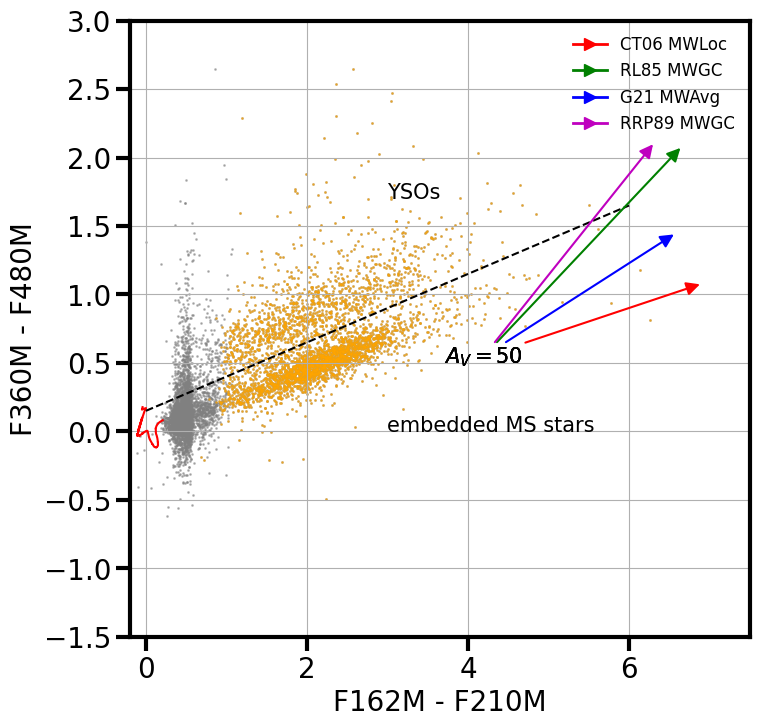

In [60]:
fig = plt.figure(figsize=(8,8))
ax = fig.add_subplot(111)
ax.scatter(f162m_mag[0] - f210m_mag[0], f360m_mag[0]-f480m_mag[0], s=1, c='gray', alpha=0.5)
ax.scatter(f162m_mag[0][idx_red_sources] - f210m_mag[0][idx_red_sources],
        f360m_mag[0][idx_red_sources]-f480m_mag[0][idx_red_sources], s=1, c='orange', alpha=0.5)
ax.plot(parsec_mags['f162m'][age_idx] - parsec_mags['f210m'][age_idx], parsec_mags['f360m'][age_idx]-parsec_mags['f480m'][age_idx], color='r')
for ext_model, labels, c in zip([CT06_MWLoc(), RL85_MWGC(), G21_MWAvg(), RRP89_MWGC(), G24_SMCAvg()], ['CT06 MWLoc', 'RL85 MWGC', 'G21 MWAvg', 'RRP89 MWGC', 'G24 SMCAvg'], colorlist):
    print(ext_model)
    plot_extvec_ccd(ax, color1=('f162m', 'f210m'), color2=('f360m', 'f480m'),
                     ext=ext_model, extvec_scale=50, color=c,
                      start=(3.7,0.5), label=labels)
ax.plot([0,6], [0.15, 1.65], c='k', ls='dashed')
ax.grid()
ax.text(3,1.7, 'YSOs', fontsize=15, color='k')
ax.text(3,0, 'embedded MS stars', fontsize=15, color='k')
plt.xlabel('F162M - F210M')
plt.ylabel('F360M - F480M')
ax.set_ylim(-1.5,3)
ax.set_xlim(-0.2,7.5)
ax.legend(fontsize=12, frameon=False)
plt.savefig('ccd_cfit003.png', bbox_inches='tight')



In [61]:
from astropy.table import Table
from astropy.coordinates import SkyCoord
from astropy import units as u
import numpy as np
import warnings
warnings.filterwarnings('ignore')
#ignore astropy warning



w51e_alma_catalog = '/blue/adamginsburg/t.yoo/from_red/w51/w51_frag_new/dendro/tables/dendro_w51e_master.fits'
#W51-IRS2
w51n_alma_catalog = '/blue/adamginsburg/t.yoo/from_red/w51/w51_frag_new/dendro/tables/dendro_w51n_master.fits'
print(f'len(w51e_alma_catalog), len(w51n_alma_catalog): {len(Table.read(w51e_alma_catalog))}, {len(Table.read(w51n_alma_catalog))}')
w51e_total_idx = np.arange(len(Table.read(w51e_alma_catalog)))
w51n_total_idx = np.arange(len(Table.read(w51n_alma_catalog)))

w51e_matched_idx = [3, 7, 36, 66, 67, 68, 76, 78, 93, 95, 106]
w51n_matched_idx = [19, 22, 29, 30, 58, 59, 64, 66, 76, 87, 90, 91] #90 and 91 are outflow knot


w51e_alma_tab = Table.read(w51e_alma_catalog)
print(w51e_alma_tab.colnames)
w51e_alma_ra = Table.read(w51e_alma_catalog)['ra']
w51e_alma_dec = Table.read(w51e_alma_catalog)['dec']
mag_f140m_w51e_arr = []
mag_f162m_w51e_arr = []
mag_f210m_w51e_arr = []
mag_f335m_w51e_arr = []
mag_f360m_w51e_arr = []
mag_f410m_w51e_arr = []
mag_f480m_w51e_arr = []
mag_f560w_w51e_arr = []
mag_f770w_w51e_arr = []
mag_f1000w_w51e_arr = []
mag_f1280w_w51e_arr = []
mag_f2100w_w51e_arr = []
matching_idx_w51e_arr = []

for ii,id in enumerate(w51e_matched_idx):
   
    skycoord_alma = SkyCoord(ra=w51e_alma_ra[id]*u.deg, dec=w51e_alma_dec[id]*u.deg)
    skycoord_jwst = SkyCoord(ra=catalog['skycoord_ref'].ra, dec=catalog['skycoord_ref'].dec)
    idx, d2d, d3d = skycoord_alma.match_to_catalog_sky(skycoord_jwst)
    is_matched = d2d < 0.1 * u.arcsec
    if not is_matched:
        print(f"W51e ALMA source index: {id}, not matched with JWST catalog")
        matching_idx_w51e_arr.append(np.nan)
        continue
    print(f"W51e ALMA source index: {id}, matched JWST catalog index: {idx}, separation: {d2d.arcsec} arcsec")
    row_jwst = catalog[idx]
    f140m_matched = (row_jwst['flux_fit_f140m']* u.MJy/u.sr * WCS(f140m_header).proj_plane_pixel_area()).to(u.Jy)
    f162m_matched = (row_jwst['flux_fit_f162m']* u.MJy/u.sr * WCS(f162m_header).proj_plane_pixel_area()).to(u.Jy)
    f210m_matched = (row_jwst['flux_fit_f210m']* u.MJy/u.sr * WCS(f210m_header).proj_plane_pixel_area()).to(u.Jy)
    f335m_matched = (row_jwst['flux_fit_f335m']* u.MJy/u.sr * WCS(f335m_header).proj_plane_pixel_area()).to(u.Jy)
    f360m_matched = (row_jwst['flux_fit_f360m']* u.MJy/u.sr * WCS(f360m_header).proj_plane_pixel_area()).to(u.Jy)
    f410m_matched = (row_jwst['flux_fit_f410m']* u.MJy/u.sr * WCS(f410m_header).proj_plane_pixel_area()).to(u.Jy)
    f480m_matched = (row_jwst['flux_fit_f480m']* u.MJy/u.sr * WCS(f480m_header).proj_plane_pixel_area()).to(u.Jy)
    f560w_matched = (row_jwst['flux_fit_f560w']* u.MJy/u.sr * WCS(f560w_header).proj_plane_pixel_area()).to(u.Jy)
    f770w_matched = (row_jwst['flux_fit_f770w']* u.MJy/u.sr * WCS(f770w_header).proj_plane_pixel_area()).to(u.Jy)
    f1000w_matched = (row_jwst['flux_fit_f1000w']* u.MJy/u.sr * WCS(f1000w_header).proj_plane_pixel_area()).to(u.Jy)
    f1280w_matched = (row_jwst['flux_fit_f1280w']* u.MJy/u.sr * WCS(f1280w_header).proj_plane_pixel_area()).to(u.Jy)
    f2100w_matched = (row_jwst['flux_fit_f2100w']* u.MJy/u.sr * WCS(f2100w_header).proj_plane_pixel_area()).to(u.Jy)
    jfilts = SvoFps.get_filter_list('JWST')
    jfilts.add_index('filterID')
    zeropoint_vega_f140m = u.Quantity(jfilts.loc[f'JWST/NIRCam.F140M']['ZeroPoint'], u.Jy)
    zeropoint_vega_f162m = u.Quantity(jfilts.loc[f'JWST/NIRCam.F162M']['ZeroPoint'], u.Jy)
    zeropoint_vega_f210m = u.Quantity(jfilts.loc[f'JWST/NIRCam.F210M']['ZeroPoint'], u.Jy)
    zeropoint_vega_f335m = u.Quantity(jfilts.loc[f'JWST/NIRCam.F335M']['ZeroPoint'], u.Jy)
    zeropoint_vega_f360m = u.Quantity(jfilts.loc[f'JWST/NIRCam.F360M']['ZeroPoint'], u.Jy)
    zeropoint_vega_f410m = u.Quantity(jfilts.loc[f'JWST/NIRCam.F410M']['ZeroPoint'], u.Jy)
    zeropoint_vega_f480m = u.Quantity(jfilts.loc[f'JWST/NIRCam.F480M']['ZeroPoint'], u.Jy)
    zeropoint_vega_f560w = u.Quantity(jfilts.loc[f'JWST/MIRI.F560W']['ZeroPoint'], u.Jy)
    zeropoint_vega_f770w = u.Quantity(jfilts.loc[f'JWST/MIRI.F770W']['ZeroPoint'], u.Jy)
    zeropoint_vega_f1000w = u.Quantity(jfilts.loc[f'JWST/MIRI.F1000W']['ZeroPoint'], u.Jy)
    zeropoint_vega_f1280w = u.Quantity(jfilts.loc[f'JWST/MIRI.F1280W']['ZeroPoint'], u.Jy)
    zeropoint_vega_f2100w = u.Quantity(jfilts.loc[f'JWST/MIRI.F2100W']['ZeroPoint'], u.Jy)

    mag_f140m = -2.5 * np.log10(f140m_matched / zeropoint_vega_f140m)
    mag_f162m = -2.5 * np.log10(f162m_matched / zeropoint_vega_f162m)
    mag_f210m = -2.5 * np.log10(f210m_matched / zeropoint_vega_f210m)
    mag_f335m = -2.5 * np.log10(f335m_matched / zeropoint_vega_f335m)
    mag_f360m = -2.5 * np.log10(f360m_matched / zeropoint_vega_f360m)
    mag_f410m = -2.5 * np.log10(f410m_matched / zeropoint_vega_f410m)
    mag_f480m = -2.5 * np.log10(f480m_matched / zeropoint_vega_f480m)
    mag_f560w = -2.5 * np.log10(f560w_matched / zeropoint_vega_f560w)
    mag_f770w = -2.5 * np.log10(f770w_matched / zeropoint_vega_f770w)
    mag_f1000w = -2.5 * np.log10(f1000w_matched / zeropoint_vega_f1000w)
    mag_f1280w = -2.5 * np.log10(f1280w_matched / zeropoint_vega_f1280w)
    mag_f2100w = -2.5 * np.log10(f2100w_matched / zeropoint_vega_f2100w)
    mag_f140m_w51e_arr.append(mag_f140m)
    mag_f162m_w51e_arr.append(mag_f162m)
    mag_f210m_w51e_arr.append(mag_f210m)
    mag_f335m_w51e_arr.append(mag_f335m)
    mag_f360m_w51e_arr.append(mag_f360m)
    mag_f410m_w51e_arr.append(mag_f410m)
    mag_f480m_w51e_arr.append(mag_f480m)
    mag_f560w_w51e_arr.append(mag_f560w)
    mag_f770w_w51e_arr.append(mag_f770w)
    mag_f1000w_w51e_arr.append(mag_f1000w)
    mag_f1280w_w51e_arr.append(mag_f1280w)
    mag_f2100w_w51e_arr.append(mag_f2100w)
    matching_idx_w51e_arr.append(idx.item())
print('matching_idx_w51e_arr:', matching_idx_w51e_arr)


w51n_alma_tab = Table.read(w51n_alma_catalog)
print(w51n_alma_tab.colnames)
w51n_alma_ra = Table.read(w51n_alma_catalog)['ra']
w51n_alma_dec = Table.read(w51n_alma_catalog)['dec']
mag_f140m_w51n_arr = []
mag_f162m_w51n_arr = []
mag_f210m_w51n_arr = []
mag_f335m_w51n_arr = []
mag_f360m_w51n_arr = []
mag_f410m_w51n_arr = []
mag_f480m_w51n_arr = []
mag_f560w_w51n_arr = []
mag_f770w_w51n_arr = []
mag_f1000w_w51n_arr = []
mag_f1280w_w51n_arr = []
mag_f2100w_w51n_arr = []
matching_idx_w51n_arr = []
for ii,id in enumerate(w51n_matched_idx):
   
    skycoord_alma = SkyCoord(ra=w51n_alma_ra[id]*u.deg, dec=w51n_alma_dec[id]*u.deg)
    skycoord_jwst = SkyCoord(ra=catalog['skycoord_ref'].ra, dec=catalog['skycoord_ref'].dec)
    idx, d2d, d3d = skycoord_alma.match_to_catalog_sky(skycoord_jwst)
    is_matched = d2d < 0.1 * u.arcsec
    if not is_matched:
        print(f"W51n ALMA source index: {id}, not matched with JWST catalog")
        matching_idx_w51n_arr.append(np.nan)
        continue
    print(f"W51n ALMA source index: {id}, matched JWST catalog index: {idx}, separation: {d2d.arcsec} arcsec")
    row_jwst = catalog[idx]

    f140m_matched = (row_jwst['flux_fit_f140m']* u.MJy/u.sr * WCS(f140m_header).proj_plane_pixel_area()).to(u.Jy)
    f162m_matched = (row_jwst['flux_fit_f162m']* u.MJy/u.sr * WCS(f162m_header).proj_plane_pixel_area()).to(u.Jy)
    f210m_matched = (row_jwst['flux_fit_f210m']* u.MJy/u.sr * WCS(f210m_header).proj_plane_pixel_area()).to(u.Jy)
    f335m_matched = (row_jwst['flux_fit_f335m']* u.MJy/u.sr * WCS(f335m_header).proj_plane_pixel_area()).to(u.Jy)
    f360m_matched = (row_jwst['flux_fit_f360m']* u.MJy/u.sr * WCS(f360m_header).proj_plane_pixel_area()).to(u.Jy)
    f410m_matched = (row_jwst['flux_fit_f410m']* u.MJy/u.sr * WCS(f410m_header).proj_plane_pixel_area()).to(u.Jy)
    f480m_matched = (row_jwst['flux_fit_f480m']* u.MJy/u.sr * WCS(f480m_header).proj_plane_pixel_area()).to(u.Jy)
    f560w_matched = (row_jwst['flux_fit_f560w']* u.MJy/u.sr * WCS(f560w_header).proj_plane_pixel_area()).to(u.Jy)
    f770w_matched = (row_jwst['flux_fit_f770w']* u.MJy/u.sr * WCS(f770w_header).proj_plane_pixel_area()).to(u.Jy)
    f1000w_matched = (row_jwst['flux_fit_f1000w']* u.MJy/u.sr * WCS(f1000w_header).proj_plane_pixel_area()).to(u.Jy)
    f1280w_matched = (row_jwst['flux_fit_f1280w']* u.MJy/u.sr * WCS(f1280w_header).proj_plane_pixel_area()).to(u.Jy)
    f2100w_matched = (row_jwst['flux_fit_f2100w']* u.MJy/u.sr * WCS(f2100w_header).proj_plane_pixel_area()).to(u.Jy)

    zeropoint_vega_f140m = u.Quantity(jfilts.loc[f'JWST/NIRCam.F140M']['ZeroPoint'], u.Jy)
    zeropoint_vega_f162m = u.Quantity(jfilts.loc[f'JWST/NIRCam.F162M']['ZeroPoint'], u.Jy)
    zeropoint_vega_f210m = u.Quantity(jfilts.loc[f'JWST/NIRCam.F210M']['ZeroPoint'], u.Jy)
    zeropoint_vega_f335m = u.Quantity(jfilts.loc[f'JWST/NIRCam.F335M']['ZeroPoint'], u.Jy)
    zeropoint_vega_f360m = u.Quantity(jfilts.loc[f'JWST/NIRCam.F360M']['ZeroPoint'], u.Jy)
    zeropoint_vega_f410m = u.Quantity(jfilts.loc[f'JWST/NIRCam.F410M']['ZeroPoint'], u.Jy)
    zeropoint_vega_f480m = u.Quantity(jfilts.loc[f'JWST/NIRCam.F480M']['ZeroPoint'], u.Jy)
    zeropoint_vega_f560w = u.Quantity(jfilts.loc[f'JWST/MIRI.F560W']['ZeroPoint'], u.Jy)
    zeropoint_vega_f770w = u.Quantity(jfilts.loc[f'JWST/MIRI.F770W']['ZeroPoint'], u.Jy)
    zeropoint_vega_f1000w = u.Quantity(jfilts.loc[f'JWST/MIRI.F1000W']['ZeroPoint'], u.Jy)
    zeropoint_vega_f1280w = u.Quantity(jfilts.loc[f'JWST/MIRI.F1280W']['ZeroPoint'], u.Jy)
    zeropoint_vega_f2100w = u.Quantity(jfilts.loc[f'JWST/MIRI.F2100W']['ZeroPoint'], u.Jy)

    mag_f140m = -2.5 * np.log10(f140m_matched / zeropoint_vega_f140m)
    mag_f162m = -2.5 * np.log10(f162m_matched / zeropoint_vega_f162m)
    mag_f210m = -2.5 * np.log10(f210m_matched / zeropoint_vega_f210m)
    mag_f335m = -2.5 * np.log10(f335m_matched / zeropoint_vega_f335m)
    mag_f360m = -2.5 * np.log10(f360m_matched / zeropoint_vega_f360m)
    mag_f410m = -2.5 * np.log10(f410m_matched / zeropoint_vega_f410m)
    mag_f480m = -2.5 * np.log10(f480m_matched / zeropoint_vega_f480m)
    mag_f560w = -2.5 * np.log10(f560w_matched / zeropoint_vega_f560w)
    mag_f770w = -2.5 * np.log10(f770w_matched / zeropoint_vega_f770w)
    mag_f1000w = -2.5 * np.log10(f1000w_matched / zeropoint_vega_f1000w)
    mag_f1280w = -2.5 * np.log10(f1280w_matched / zeropoint_vega_f1280w)
    mag_f2100w = -2.5 * np.log10(f2100w_matched / zeropoint_vega_f2100w)

    mag_f140m_w51n_arr.append(mag_f140m)
    mag_f162m_w51n_arr.append(mag_f162m)
    mag_f210m_w51n_arr.append(mag_f210m)
    mag_f335m_w51n_arr.append(mag_f335m)
    mag_f360m_w51n_arr.append(mag_f360m)
    mag_f410m_w51n_arr.append(mag_f410m)
    mag_f480m_w51n_arr.append(mag_f480m)
    mag_f560w_w51n_arr.append(mag_f560w)
    mag_f770w_w51n_arr.append(mag_f770w)
    mag_f1000w_w51n_arr.append(mag_f1000w)
    mag_f1280w_w51n_arr.append(mag_f1280w)
    mag_f2100w_w51n_arr.append(mag_f2100w)
    matching_idx_w51n_arr.append(idx.item())
print('matching_idx_w51n_arr:', matching_idx_w51n_arr)

len(w51e_alma_catalog), len(w51n_alma_catalog): 118, 93
['b3_id', 'b6_id', 'b3_xpix', 'b3_ypix', 'b6_xpix', 'b6_ypix', 'b3_xsky', 'b3_ysky', 'b6_xsky', 'b6_ysky', 'ra', 'dec', 'b3_afwhm', 'b3_bfwhm', 'b3_pa', 'b6_afwhm', 'b6_bfwhm', 'b6_pa', 'is_matched', 'is_overlap', 'flux_peak_b3', 'flux_peak_b6', 'alpha', 'alphaerr', 'group', 'temp', 'constT_mass', 'MBBT_mass', 'constT_mass_err', 'MBBT_mass_err', 'inincore_b3fov', 'flux_b3', 'flux_err_b3', 'pa_b3', 'pa_err_b3', 'fitted_major_b3', 'fitted_major_err_b3', 'fitted_minor_b3', 'fitted_minor_err_b3', 'deconvolved_major_b3', 'deconvolved_minor_b3', 'deconvolved_angle_b3', 'peak_flux_b3', 'least_chi_square_b3', 'flux_b6', 'flux_err_b6', 'pa_b6', 'pa_err_b6', 'fitted_major_b6', 'fitted_major_err_b6', 'fitted_minor_b6', 'fitted_minor_err_b6', 'deconvolved_major_b6', 'deconvolved_minor_b6', 'deconvolved_angle_b6', 'peak_flux_b6', 'least_chi_square_b6', 'flux_b6_conv', 'flux_err_b6_conv', 'pa_b6_conv', 'pa_err_b6_conv', 'fitted_major_b6_conv', 

In [62]:
vla_cat_file = '/blue/adamginsburg/t.yoo/w51_nircam/analysis/vla_updated_with_radius.fits'
vla_cat = Table.read(vla_cat_file)
vla_ra = vla_cat['GRAdeg']
vla_dec = vla_cat['GDEdeg']
finite_idx = np.isfinite(vla_ra) & np.isfinite(vla_dec)
vla_cat_updated = vla_cat[finite_idx]
vla_skycoord = SkyCoord(ra=vla_cat_updated['GRAdeg'], dec=vla_cat_updated['GDEdeg'])
i2d, d2d, d3d = vla_skycoord.match_to_catalog_sky(skycoord_jwst)
matched_vla_idx = i2d[d2d < 0.1*u.arcsec]
jwst_cat_matched_vla = catalog[matched_vla_idx]

print('matched_vla_idx:', matched_vla_idx)

#print skycoord in h:m:s format
print(jwst_cat_matched_vla['skycoord_ref'].to_string('hmsdms'))
f140m_matched_vla = (jwst_cat_matched_vla['flux_fit_f140m']* u.MJy/u.sr * WCS(f140m_header).proj_plane_pixel_area()).to(u.Jy)
f162m_matched_vla = (jwst_cat_matched_vla['flux_fit_f162m']* u.MJy/u.sr * WCS(f162m_header).proj_plane_pixel_area()).to(u.Jy)
f210m_matched_vla = (jwst_cat_matched_vla['flux_fit_f210m']* u.MJy/u.sr * WCS(f210m_header).proj_plane_pixel_area()).to(u.Jy)
f335m_matched_vla = (jwst_cat_matched_vla['flux_fit_f335m']* u.MJy/u.sr * WCS(f335m_header).proj_plane_pixel_area()).to(u.Jy)
f360m_matched_vla = (jwst_cat_matched_vla['flux_fit_f360m']* u.MJy/u.sr * WCS(f360m_header).proj_plane_pixel_area()).to(u.Jy)
f410m_matched_vla = (jwst_cat_matched_vla['flux_fit_f410m']* u.MJy/u.sr * WCS(f410m_header).proj_plane_pixel_area()).to(u.Jy)
f480m_matched_vla = (jwst_cat_matched_vla['flux_fit_f480m']* u.MJy/u.sr * WCS(f480m_header).proj_plane_pixel_area()).to(u.Jy)

f140m_matched_vla_mag = -2.5 * np.log10(f140m_matched_vla / zeropoint_vega_f140m)
f162m_matched_vla_mag = -2.5 * np.log10(f162m_matched_vla / zeropoint_vega_f162m)
f210m_matched_vla_mag = -2.5 * np.log10(f210m_matched_vla / zeropoint_vega_f210m)
f335m_matched_vla_mag = -2.5 * np.log10(f335m_matched_vla / zeropoint_vega_f335m)
f360m_matched_vla_mag = -2.5 * np.log10(f360m_matched_vla / zeropoint_vega_f360m)
f410m_matched_vla_mag = -2.5 * np.log10(f410m_matched_vla / zeropoint_vega_f410m)
f480m_matched_vla_mag = -2.5 * np.log10(f480m_matched_vla / zeropoint_vega_f480m)
f560w_matched_vla = (jwst_cat_matched_vla['flux_fit_f560w']* u.MJy/u.sr * WCS(f560w_header).proj_plane_pixel_area()).to(u.Jy)
f560w_matched_vla_mag = -2.5 * np.log10(f560w_matched_vla / zeropoint_vega_f560w)
f770w_matched_vla = (jwst_cat_matched_vla['flux_fit_f770w']* u.MJy/u.sr * WCS(f770w_header).proj_plane_pixel_area()).to(u.Jy)
f770w_matched_vla_mag = -2.5 * np.log10(f770w_matched_vla / zeropoint_vega_f770w)
f1000w_matched_vla = (jwst_cat_matched_vla['flux_fit_f1000w']* u.MJy/u.sr * WCS(f1000w_header).proj_plane_pixel_area()).to(u.Jy)
f1000w_matched_vla_mag = -2.5 * np.log10(f1000w_matched_vla / zeropoint_vega_f1000w)
f1280w_matched_vla = (jwst_cat_matched_vla['flux_fit_f1280w']* u.MJy/u.sr * WCS(f1280w_header).proj_plane_pixel_area()).to(u.Jy)
f1280w_matched_vla_mag = -2.5 * np.log10(f1280w_matched_vla / zeropoint_vega_f1280w)
f2100w_matched_vla = (jwst_cat_matched_vla['flux_fit_f2100w']* u.MJy/u.sr * WCS(f2100w_header).proj_plane_pixel_area()).to(u.Jy)
f2100w_matched_vla_mag = -2.5 * np.log10(f2100w_matched_vla / zeropoint_vega_f2100w)
print(f410m_matched_vla_mag-f480m_matched_vla_mag)
print(f162m_matched_vla_mag-f210m_matched_vla_mag)



matched_vla_idx: [17834  7193  7193  6874  6874  6874  6874  6874  5628  5628 17549 17550
 17549 17549 17549 17549  6071  6093  6071  6071  6071  6071 18726 13463
 13463 13463 13810 18916 24862 24862 24862 24862 24862 12700 12700 26260
 26260 13527 13527 13527 13527 13527 13527 13527 13527 13527 13537 13537
 13537 13537 21728 13551 13551 23020 23020 23020 23020 23020 23020 23020
 23020 23020 23020 23020 23020 26029 26029 26029 26029 26029 19303 19303
 19303 19303 19303 19303 19303 19303]
['19h23m39.83070721s +14d31m05.91787674s', '19h23m39.83110311s +14d31m05.47492599s', '19h23m39.83110311s +14d31m05.47492599s', '19h23m39.63617425s +14d31m30.559644s', '19h23m39.63617425s +14d31m30.559644s', '19h23m39.63617425s +14d31m30.559644s', '19h23m39.63617425s +14d31m30.559644s', '19h23m39.63617425s +14d31m30.559644s', '19h23m41.7752142s +14d31m27.4786237s', '19h23m41.7752142s +14d31m27.4786237s', '19h23m41.23777455s +14d31m11.54802859s', '19h23m41.24042149s +14d31m10.85206631s', '19h23m41.237774

(-0.2, 6.0)

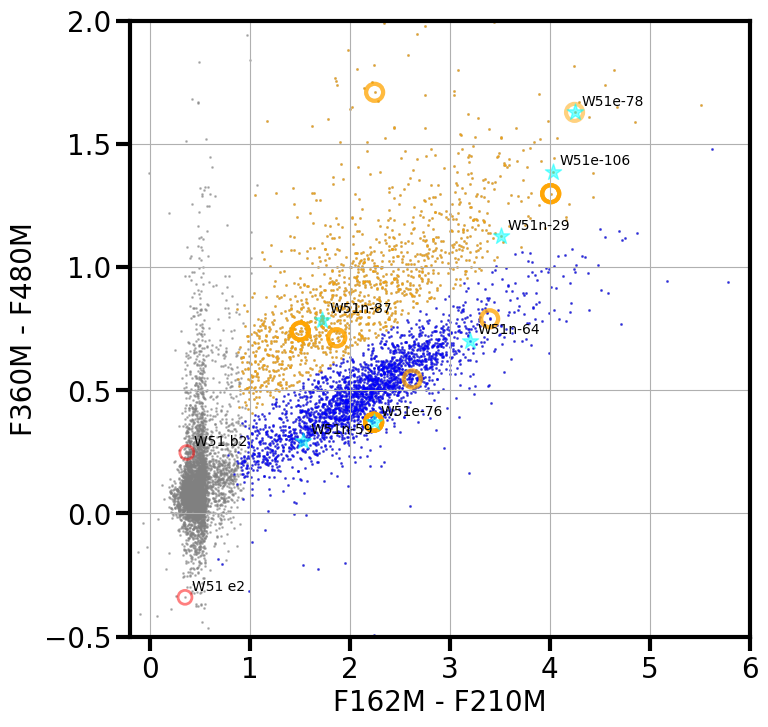

In [63]:
finite_matching_idx_w51e_arr = np.array(matching_idx_w51e_arr)[np.isfinite(matching_idx_w51e_arr)].astype(int)
finite_matching_idx_w51n_arr = np.array(matching_idx_w51n_arr)[np.isfinite(matching_idx_w51n_arr)].astype(int)
upper_idx = np.where((f360-f480 > 0.15 + (1.5/6)*(f162-f210)) & (av_estimate > 12))
lower_idx = np.where((f360-f480 <= 0.15 + (1.5/6)*(f162-f210)) & (av_estimate > 12))

fig = plt.figure(figsize=(8,8))
ax = fig.add_subplot(111)
ax.scatter(f162m_mag[0] - f210m_mag[0], f360m_mag[0]-f480m_mag[0], s=1, c='gray', alpha=0.5)
ax.scatter(f162m_mag[0][upper_idx] - f210m_mag[0][upper_idx], f360m_mag[0][upper_idx]-f480m_mag[0][upper_idx], s=1, c='orange', alpha=0.5, label='Upper branch')
ax.scatter(f162m_mag[0][lower_idx] - f210m_mag[0][lower_idx], f360m_mag[0][lower_idx]-f480m_mag[0][lower_idx], s=1, c='blue', alpha=0.5, label='Lower branch')
ax.scatter(f162m_matched_vla_mag - f210m_matched_vla_mag, f360m_matched_vla_mag-f480m_matched_vla_mag, s=150, edgecolor='orange', lw=3, facecolor='none',  alpha=0.5, label='VLA sources')
ax.scatter(f162m_mag[0][7220]-f210m_mag[0][7220], f360m_mag[0][7220]-f480m_mag[0][7220], s=150, edgecolor='orange', lw=3, facecolor='none',  alpha=0.5, label='VLA sources')
ax.scatter(np.array(mag_f162m_w51e_arr) - np.array(mag_f210m_w51e_arr), np.array(mag_f360m_w51e_arr)-np.array(mag_f480m_w51e_arr), s=150, c='cyan', marker='*',alpha=0.5, label='W51e ALMA sources')
ax.scatter(np.array(mag_f162m_w51n_arr) - np.array(mag_f210m_w51n_arr), np.array(mag_f360m_w51n_arr)-np.array(mag_f480m_w51n_arr), s=150, c='cyan', marker='*', alpha=0.5, label='W51n ALMA sources')
ii=0
for alma_idx, jwst_idx in zip(w51e_matched_idx, matching_idx_w51e_arr):
    if jwst_idx is not np.nan:
        ax.annotate(f'W51e-{alma_idx}', (np.array(mag_f162m_w51e_arr)[ii] - np.array(mag_f210m_w51e_arr)[ii],
                                np.array(mag_f360m_w51e_arr)[ii]-np.array(mag_f480m_w51e_arr)[ii]),
                textcoords="offset points", xytext=(5,5), ha='left', color='k', fontsize=10)
        ii += 1
ii=0 
for alma_idx, jwst_idx in zip(w51n_matched_idx, matching_idx_w51n_arr):
    if jwst_idx is not np.nan:
        ax.annotate(f'W51n-{alma_idx}', (np.array(mag_f162m_w51n_arr)[ii] - np.array(mag_f210m_w51n_arr)[ii],
                                np.array(mag_f360m_w51n_arr)[ii]-np.array(mag_f480m_w51n_arr)[ii]),
                textcoords="offset points", xytext=(5,5), ha='left', color='k', fontsize=10)
        ii += 1
# HeI(1-0) and Br gamma, O9.5 (Barbosa+22)
ax.scatter(f162m_mag[0][2889] - f210m_mag[0][2889], f360m_mag[0][2889]-f480m_mag[0][2889], s=100, edgecolor='red', facecolor='none',lw=2, alpha=0.5)
ax.annotate('W51 b2', (f162m_mag[0].value[2889] - f210m_mag[0].value[2889], f360m_mag[0].value[2889]-f480m_mag[0].value[2889]), textcoords="offset points", xytext=(5,5), ha='left', color='k', fontsize=10)
# HeI and Br gamma emission, O9.5 star  (Barbosa+22)
ax.scatter(f162m_mag[0][2899] - f210m_mag[0][2899], f360m_mag[0][2899]-f480m_mag[0][2899], s=100, edgecolor='red', facecolor='none',lw=2, alpha=0.5)
ax.annotate('W51 b1', (f162m_mag[0].value[2899] - f210m_mag[0].value[2899], f360m_mag[0].value[2899]-f480m_mag[0].value[2899]), textcoords="offset points", xytext=(5,5), ha='left', color='k', fontsize=10)
# c1 - not sure if it is driving source, O9 star (Barbosa+22)
ax.scatter(f162m_mag[0][7656] - f210m_mag[0][7656], f360m_mag[0][7656]-f480m_mag[0][7656], s=100, edgecolor='red', facecolor='none',lw=2,alpha=0.5)
ax.annotate('W51 c1', (f162m_mag[0].value[7656] - f210m_mag[0].value[7656], f360m_mag[0].value[7656]-f480m_mag[0].value[7656]), textcoords="offset points", xytext=(5,5), ha='left', color='k', fontsize=10)
# e7 - O9.5 (Barbosa+22), B star (Bik+19)
ax.scatter(f162m_mag[0][7220] - f210m_mag[0][7220], f360m_mag[0][7220]-f480m_mag[0][7220], s=100, edgecolor='red', facecolor='none', lw=2,alpha=0.5)
ax.annotate('W51 e7', (f162m_mag[0].value[7220] - f210m_mag[0].value[7220], f360m_mag[0].value[7220]-f480m_mag[0].value[7220]), textcoords="offset points", xytext=(5,5), ha='left', color='k', fontsize=10)
ax.scatter(f162m_mag[0][13814] - f210m_mag[0][13814], f360m_mag[0][13814]-f480m_mag[0][13814], s=100, edgecolor='red', facecolor='none', lw=2,alpha=0.5)
ax.annotate('W51 e2', (f162m_mag[0].value[13814] - f210m_mag[0].value[13814], f360m_mag[0].value[13814]-f480m_mag[0].value[13814]), textcoords="offset points", xytext=(5,5), ha='left', color='k', fontsize=10)


ax.grid()
ax.set_xlabel('F162M - F210M')
ax.set_ylabel('F360M - F480M')
ax.set_ylim(-0.5,2)
ax.set_xlim(-0.2,6)

Text(0, 0.5, 'F360M - F480M')

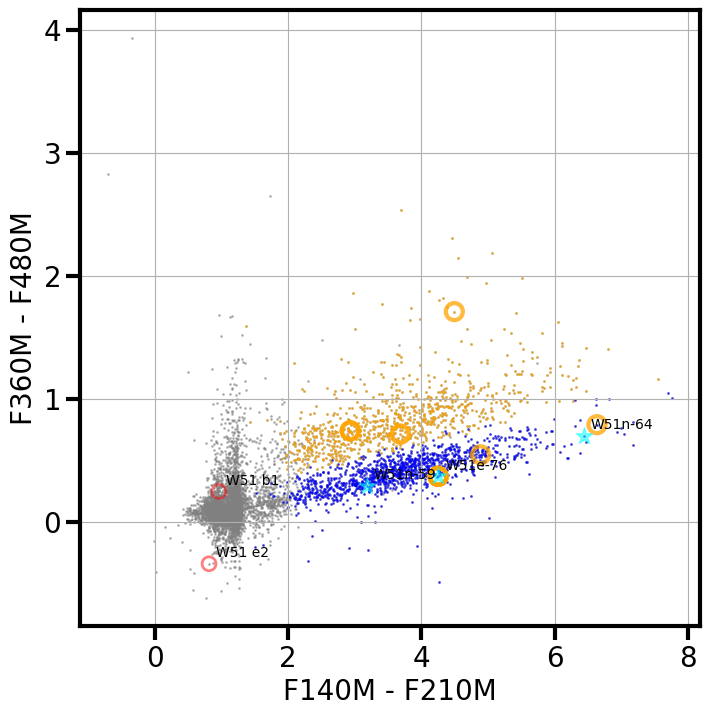

In [64]:
# 140 vs 210 vs 360 -480
fig = plt.figure(figsize=(8,8))
ax = fig.add_subplot(111)
ax.scatter(f140m_mag[0] - f210m_mag[0], f360m_mag[0]-f480m_mag[0], s=1, c='gray', alpha=0.5)
ax.scatter(f140m_mag[0][upper_idx] - f210m_mag[0][upper_idx], f360m_mag[0][upper_idx]-f480m_mag[0][upper_idx], s=1, c='orange', alpha=0.5, label='Upper branch')
ax.scatter(f140m_mag[0][lower_idx] - f210m_mag[0][lower_idx], f360m_mag[0][lower_idx]-f480m_mag[0][lower_idx], s=1, c='blue', alpha=0.5, label='Lower branch')
ax.scatter(f140m_matched_vla_mag - f210m_matched_vla_mag, f360m_matched_vla_mag-f480m_matched_vla_mag, s=150, edgecolor='orange', lw=3, facecolor='none',  alpha=0.5, label='VLA sources')
ax.scatter(np.array(mag_f140m_w51e_arr) - np.array(mag_f210m_w51e_arr), np.array(mag_f360m_w51e_arr)-np.array(mag_f480m_w51e_arr), s=150, c='cyan', marker='*',alpha=0.5, label='W51e ALMA sources')
ax.scatter(np.array(mag_f140m_w51n_arr) - np.array(mag_f210m_w51n_arr), np.array(mag_f360m_w51n_arr)-np.array(mag_f480m_w51n_arr), s=150, c='cyan', marker='*', alpha=0.5, label='W51n ALMA sources')
ii=0
for alma_idx, jwst_idx in zip(w51e_matched_idx, matching_idx_w51e_arr):
    if jwst_idx is not np.nan:
        ax.annotate(f'W51e-{alma_idx}', (np.array(mag_f140m_w51e_arr)[ii] - np.array(mag_f210m_w51e_arr)[ii],
                                np.array(mag_f360m_w51e_arr)[ii]-np.array(mag_f480m_w51e_arr)[ii]),
                textcoords="offset points", xytext=(5,5), ha='left', color='k', fontsize=10)
        ii += 1
ii=0
for alma_idx, jwst_idx in zip(w51n_matched_idx, matching_idx_w51n_arr):
    if jwst_idx is not np.nan:
        ax.annotate(f'W51n-{alma_idx}', (np.array(mag_f140m_w51n_arr)[ii] - np.array(mag_f210m_w51n_arr)[ii],
                                np.array(mag_f360m_w51n_arr)[ii]-np.array(mag_f480m_w51n_arr)[ii]),
                textcoords="offset points", xytext=(5,5), ha='left', color='k', fontsize=10)
        ii += 1
ax.scatter(f140m_mag[0][2889] - f210m_mag[0][2889], f360m_mag[0][2889]-f480m_mag[0][2889], s=100, edgecolor='red', facecolor='none',lw=2, alpha=0.5)
ax.annotate('W51 b1', (f140m_mag[0].value[2889] - f210m_mag[0].value[2889], f360m_mag[0].value[2889]-f480m_mag[0].value[2889]), textcoords="offset points", xytext=(5,5), ha='left', color='k', fontsize=10)
ax.scatter(f140m_mag[0][2899] - f210m_mag[0][2899], f360m_mag[0][2899]-f480m_mag[0][2899], s=100, edgecolor='red', facecolor='none',lw=2, alpha=0.5)
ax.annotate('W51 b2', (f140m_mag[0].value[2899] - f210m_mag[0].value[2899], f360m_mag[0].value[2899]-f480m_mag[0].value[2899]), textcoords="offset points", xytext=(5,5), ha='left', color='k', fontsize=10)
ax.scatter(f140m_mag[0][7656] - f210m_mag[0][7656], f360m_mag[0][7656]-f480m_mag[0][7656], s=100, edgecolor='red', facecolor='none',lw=2,alpha=0.5)
ax.annotate('W51 c1', (f140m_mag[0].value[7656] - f210m_mag[0].value[7656], f360m_mag[0].value[7656]-f480m_mag[0].value[7656]), textcoords="offset points", xytext=(5,5), ha='left', color='k', fontsize=10)
ax.scatter(f140m_mag[0][7220] - f210m_mag[0][7220], f360m_mag[0][7220]-f480m_mag[0][7220], s=100, edgecolor='red', facecolor='none', lw=2,alpha=0.5)    
ax.annotate('W51 e7', (f140m_mag[0].value[7220] - f210m_mag[0].value[7220], f360m_mag[0].value[7220]-f480m_mag[0].value[7220]), textcoords="offset points", xytext=(5,5), ha='left', color='k', fontsize=10)    
ax.scatter(f140m_mag[0][13814] - f210m_mag[0][13814], f360m_mag[0][13814]-f480m_mag[0][13814], s=100, edgecolor='red', facecolor='none', lw=2,alpha=0.5)
ax.annotate('W51 e2', (f140m_mag[0].value[13814] - f210m_mag[0].value[13814], f360m_mag[0].value[13814]-f480m_mag[0].value[13814]), textcoords="offset points", xytext=(5,5), ha='left', color='k', fontsize=10)
ax.grid()
ax.set_xlabel('F140M - F210M')
ax.set_ylabel('F360M - F480M')

Text(0, 0.5, 'F162M - F210M')

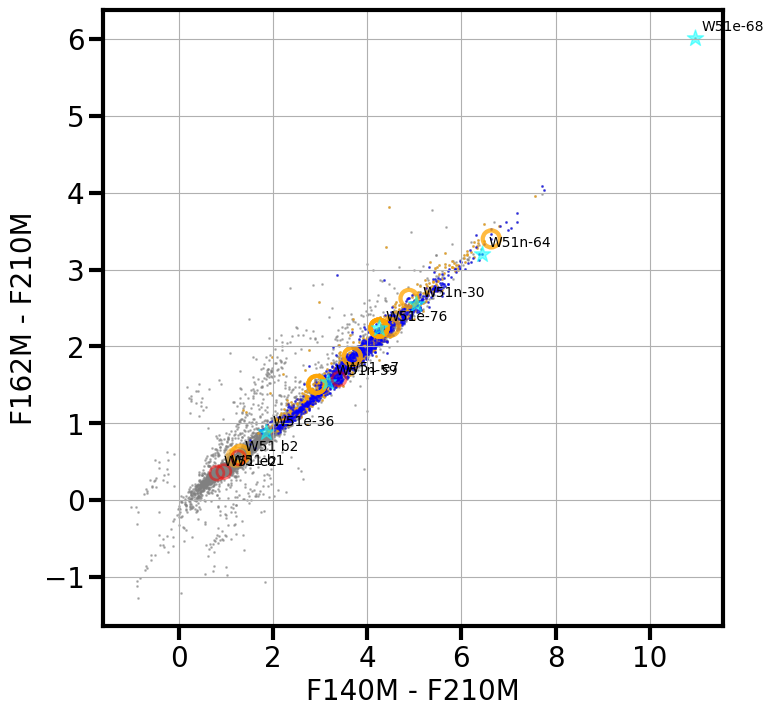

In [65]:
# 140-210 vs 162-210
fig = plt.figure(figsize=(8,8))
ax = fig.add_subplot(111)
ax.scatter(f140m_mag[0] - f210m_mag[0], f162m_mag[0]-f210m_mag[0], s=1, c='gray', alpha=0.5)
ax.scatter(f140m_mag[0][upper_idx] - f210m_mag[0][upper_idx], f162m_mag[0][upper_idx]-f210m_mag[0][upper_idx], s=1, c='orange', alpha=0.5, label='Upper branch')
ax.scatter(f140m_mag[0][lower_idx] - f210m_mag[0][lower_idx], f162m_mag[0][lower_idx]-f210m_mag[0][lower_idx], s=1, c='blue', alpha=0.5, label='Lower branch')
ax.scatter(f140m_matched_vla_mag - f210m_matched_vla_mag, f162m_matched_vla_mag-f210m_matched_vla_mag, s=150, edgecolor='orange', lw=3, facecolor='none',  alpha=0.5, label='VLA sources')
ax.scatter(np.array(mag_f140m_w51e_arr) - np.array(mag_f210m_w51e_arr), np.array(mag_f162m_w51e_arr)-np.array(mag_f210m_w51e_arr), s=150, c='cyan', marker='*',alpha=0.5, label='W51e ALMA sources')
ax.scatter(np.array(mag_f140m_w51n_arr) - np.array(mag_f210m_w51n_arr), np.array(mag_f162m_w51n_arr)-np.array(mag_f210m_w51n_arr), s=150, c='cyan', marker='*', alpha=0.5, label='W51n ALMA sources')
ii=0
for alma_idx, jwst_idx in zip(w51e_matched_idx, matching_idx_w51e_arr):
    if jwst_idx is not np.nan:
        ax.annotate(f'W51e-{alma_idx}', (np.array(mag_f140m_w51e_arr)[ii] - np.array(mag_f210m_w51e_arr)[ii],
                                np.array(mag_f162m_w51e_arr)[ii]-np.array(mag_f210m_w51e_arr)[ii]),
                textcoords="offset points", xytext=(5,5), ha='left', color='k', fontsize=10)
        ii += 1
ii=0
for alma_idx, jwst_idx in zip(w51n_matched_idx, matching_idx_w51n_arr):
    if jwst_idx is not np.nan:
        ax.annotate(f'W51n-{alma_idx}', (np.array(mag_f140m_w51n_arr)[ii] - np.array(mag_f210m_w51n_arr)[ii],
                                np.array(mag_f162m_w51n_arr)[ii]-np.array(mag_f210m_w51n_arr)[ii]),
                textcoords="offset points", xytext=(5,5), ha='left', color='k', fontsize=10)
        ii += 1
ax.scatter(f140m_mag[0][2889] - f210m_mag[0][2889], f162m_mag[0][2889]-f210m_mag[0][2889], s=100, edgecolor='red', facecolor='none',lw=2, alpha=0.5)
ax.annotate('W51 b1', (f140m_mag[0].value[2889] - f210m_mag[0].value[2889], f162m_mag[0].value[2889]-f210m_mag[0].value[2889]), textcoords="offset points", xytext=(5,5), ha='left', color='k', fontsize=10)
ax.scatter(f140m_mag[0][2899] - f210m_mag[0][2899], f162m_mag[0][2899]-f210m_mag[0][2899], s=100, edgecolor='red', facecolor='none',lw=2, alpha=0.5)
ax.annotate('W51 b2', (f140m_mag[0].value[2899] - f210m_mag[0].value[2899], f162m_mag[0].value[2899]-f210m_mag[0].value[2899]), textcoords="offset points", xytext=(5,5), ha='left', color='k', fontsize=10)
ax.scatter(f140m_mag[0][7656] - f210m_mag[0][7656], f162m_mag[0][7656]-f210m_mag[0][7656], s=100, edgecolor='red', facecolor='none',lw=2,alpha=0.5)
ax.annotate('W51 c1', (f140m_mag[0].value[7656] - f210m_mag[0].value[7656], f162m_mag[0].value[7656]-f210m_mag[0].value[7656]), textcoords="offset points", xytext=(5,5), ha='left', color='k', fontsize=10)
ax.scatter(f140m_mag[0][7220] - f210m_mag[0][7220], f162m_mag[0][7220]-f210m_mag[0][7220], s=100, edgecolor='red', facecolor='none', lw=2,alpha=0.5)    
ax.annotate('W51 e7', (f140m_mag[0].value[7220] - f210m_mag[0].value[7220], f162m_mag[0].value[7220]-f210m_mag[0].value[7220]), textcoords="offset points", xytext=(5,5), ha='left', color='k', fontsize=10)    
ax.scatter(f140m_mag[0][13814] - f210m_mag[0][13814], f162m_mag[0][13814]-f210m_mag[0][13814], s=100, edgecolor='red', facecolor='none', lw=2,alpha=0.5)
ax.annotate('W51 e2', (f140m_mag[0].value[13814] - f210m_mag[0].value[13814], f162m_mag[0].value[13814]-f210m_mag[0].value[13814]), textcoords="offset points", xytext=(5,5), ha='left', color='k', fontsize=10)
ax.grid()
ax.set_xlabel('F140M - F210M')
ax.set_ylabel('F162M - F210M')

(-0.5, 1.5)

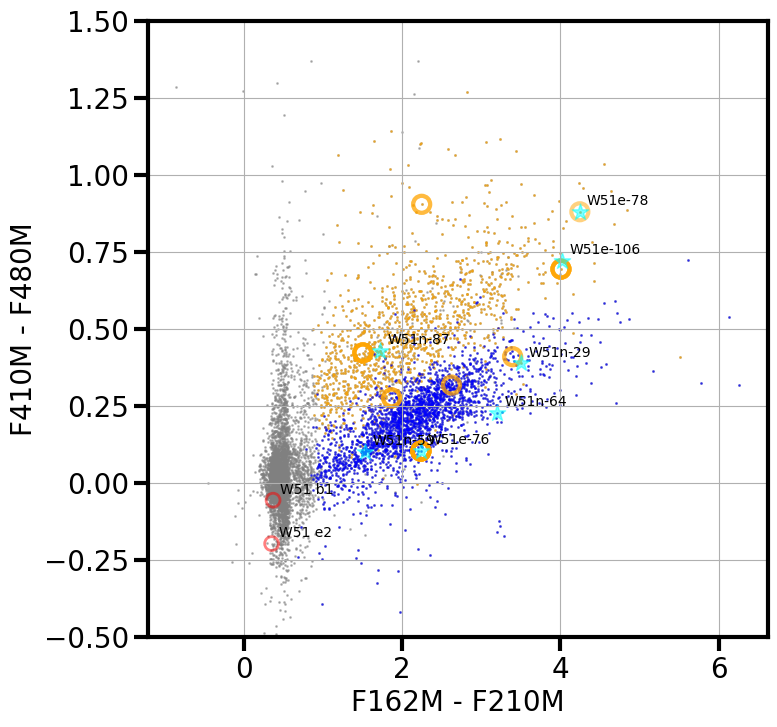

In [66]:
# 162 vs 210 vs 410 - 480
fig = plt.figure(figsize=(8,8))
ax = fig.add_subplot(111)
ax.scatter(f162m_mag[0] - f210m_mag[0], f410m_mag[0]-f480m_mag[0], s=1, c='gray', alpha=0.5)
ax.scatter(f162m_mag[0][upper_idx] - f210m_mag[0][upper_idx], f410m_mag[0][upper_idx]-f480m_mag[0][upper_idx], s=1, c='orange', alpha=0.5, label='Upper branch')
ax.scatter(f162m_mag[0][lower_idx] - f210m_mag[0][lower_idx], f410m_mag[0][lower_idx]-f480m_mag[0][lower_idx], s=1, c='blue', alpha=0.5, label='Lower branch')
ax.scatter(f162m_matched_vla_mag - f210m_matched_vla_mag, f410m_matched_vla_mag-f480m_matched_vla_mag, s=150, edgecolor='orange', lw=3, facecolor='none',  alpha=0.5, label='VLA sources')
ax.scatter(np.array(mag_f162m_w51e_arr) - np.array(mag_f210m_w51e_arr), np.array(mag_f410m_w51e_arr)-np.array(mag_f480m_w51e_arr), s=150, c='cyan', marker='*',alpha=0.5, label='W51e ALMA sources')
ax.scatter(np.array(mag_f162m_w51n_arr) - np.array(mag_f210m_w51n_arr), np.array(mag_f410m_w51n_arr)-np.array(mag_f480m_w51n_arr), s=150, c='cyan', marker='*', alpha=0.5, label='W51n ALMA sources')
ii=0
for alma_idx, jwst_idx in zip(w51e_matched_idx, matching_idx_w51e_arr):
    if jwst_idx is not np.nan:
        ax.annotate(f'W51e-{alma_idx}', (np.array(mag_f162m_w51e_arr)[ii] - np.array(mag_f210m_w51e_arr)[ii],
                                np.array(mag_f410m_w51e_arr)[ii]-np.array(mag_f480m_w51e_arr)[ii]),
                textcoords="offset points", xytext=(5,5), ha='left', color='k', fontsize=10)
        ii += 1
ii=0
for alma_idx, jwst_idx in zip(w51n_matched_idx, matching_idx_w51n_arr):
    if jwst_idx is not np.nan:
        ax.annotate(f'W51n-{alma_idx}', (np.array(mag_f162m_w51n_arr)[ii] - np.array(mag_f210m_w51n_arr)[ii],
                                np.array(mag_f410m_w51n_arr)[ii]-np.array(mag_f480m_w51n_arr)[ii]),
                textcoords="offset points", xytext=(5,5), ha='left', color='k', fontsize=10)
        ii += 1
# HeI(1-0) and Br gamma, O9.5 (Barbosa+22)
ax.scatter(f162m_mag[0][2889] - f210m_mag[0][2889], f410m_mag[0][2889]-f480m_mag[0][2889], s=100, edgecolor='red', facecolor='none',lw=2, alpha=0.5)
ax.annotate('W51 b1', (f162m_mag[0].value[2889] - f210m_mag[0].value[2889], f410m_mag[0].value[2889]-f480m_mag[0].value[2889]), textcoords="offset points", xytext=(5,5), ha='left', color='k', fontsize=10)
# HeI and Br gamma emission, O9.5 star  (Barbosa+22)
ax.scatter(f162m_mag[0][2899] - f210m_mag[0][2899], f410m_mag[0][2899]-f480m_mag[0][2899], s=100, edgecolor='red', facecolor='none',lw=2, alpha=0.5)
ax.annotate('W51 b2', (f162m_mag[0].value[2899] - f210m_mag[0].value[2899], f410m_mag[0].value[2899]-f480m_mag[0].value[2899]), textcoords="offset points", xytext=(5,5), ha='left', color='k', fontsize=10)
# c1 - not sure if it is driving source, O9 star (Barbosa+22)
ax.scatter(f162m_mag[0][7656] - f210m_mag[0][7656], f410m_mag[0][7656]-f480m_mag[0][7656], s=100, edgecolor='red', facecolor='none',lw=2,alpha=0.5)
ax.annotate('W51 c1', (f162m_mag[0].value[7656] - f210m_mag[0].value[7656], f410m_mag[0].value[7656]-f480m_mag[0].value[7656]), textcoords="offset points", xytext=(5,5), ha='left', color='k', fontsize=10)  
ax.scatter(f162m_mag[0][7220] - f210m_mag[0][7220], f410m_mag[0][7220]-f480m_mag[0][7220], s=100, edgecolor='red', facecolor='none', lw=2,alpha=0.5)
ax.annotate('W51 e7', (f162m_mag[0].value[7220] - f210m_mag[0].value[7220], f410m_mag[0].value[7220]-f480m_mag[0].value[7220]), textcoords="offset points", xytext=(5,5), ha='left', color='k', fontsize=10)
ax.scatter(f162m_mag[0][13814] - f210m_mag[0][13814], f410m_mag[0][13814]-f480m_mag[0][13814], s=100, edgecolor='red', facecolor='none', lw=2,alpha=0.5)
ax.annotate('W51 e2', (f162m_mag[0].value[13814] - f210m_mag[0].value[13814], f410m_mag[0].value[13814]-f480m_mag[0].value[13814]), textcoords="offset points", xytext=(5,5), ha='left', color='k', fontsize=10)  
ax.grid()
ax.set_xlabel('F162M - F210M')
ax.set_ylabel('F410M - F480M')  
ax.set_ylim(-0.5,1.5)

Text(0, 0.5, 'F360M - F410M')

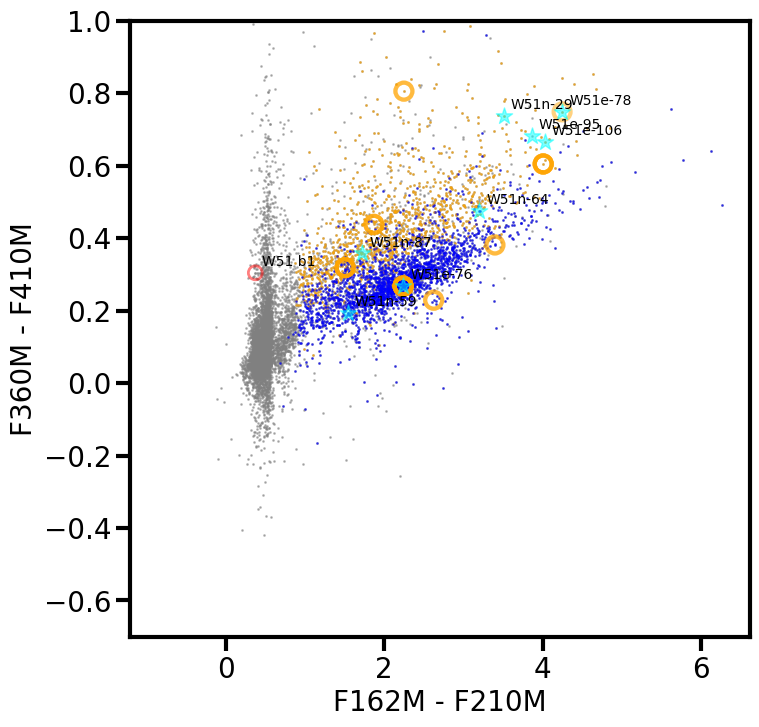

In [67]:


# 162 - 210 vs 360 - 410
fig = plt.figure(figsize=(8,8))
ax = fig.add_subplot(111)
ax.scatter(f162m_mag[0] - f210m_mag[0], f360m_mag[0]-f410m_mag[0], s=1, c='gray', alpha=0.5)
ax.scatter(f162m_mag[0][upper_idx] - f210m_mag[0][upper_idx], f360m_mag[0][upper_idx]-f410m_mag[0][upper_idx], s=1, c='orange', alpha=0.5, label='Upper branch')
ax.scatter(f162m_mag[0][lower_idx] - f210m_mag[0][lower_idx], f360m_mag[0][lower_idx]-f410m_mag[0][lower_idx], s=1, c='blue', alpha=0.5, label='Lower branch')
ax.scatter(f162m_matched_vla_mag - f210m_matched_vla_mag, f360m_matched_vla_mag-f410m_matched_vla_mag, s=150, edgecolor='orange', lw=3, facecolor='none',  alpha=0.5, label='VLA sources')
ax.scatter(np.array(mag_f162m_w51e_arr) - np.array(mag_f210m_w51e_arr), np.array(mag_f360m_w51e_arr)-np.array(mag_f410m_w51e_arr), s=150, c='cyan', marker='*',alpha=0.5, label='W51e ALMA sources')
ax.scatter(np.array(mag_f162m_w51n_arr) - np.array(mag_f210m_w51n_arr), np.array(mag_f360m_w51n_arr)-np.array(mag_f410m_w51n_arr), s=150, c='cyan', marker='*', alpha=0.5, label='W51n ALMA sources')
ii=0
for alma_idx, jwst_idx in zip(w51e_matched_idx, matching_idx_w51e_arr):
    if jwst_idx is not np.nan:
        ax.annotate(f'W51e-{alma_idx}', (np.array(mag_f162m_w51e_arr)[ii] - np.array(mag_f210m_w51e_arr)[ii],
                                np.array(mag_f360m_w51e_arr)[ii]-np.array(mag_f410m_w51e_arr)[ii]),
                textcoords="offset points", xytext=(5,5), ha='left', color='k', fontsize=10)
        ii += 1
ii=0
for alma_idx, jwst_idx in zip(w51n_matched_idx, matching_idx_w51n_arr):
    if jwst_idx is not np.nan:
        ax.annotate(f'W51n-{alma_idx}', (np.array(mag_f162m_w51n_arr)[ii] - np.array(mag_f210m_w51n_arr)[ii],
                                np.array(mag_f360m_w51n_arr)[ii]-np.array(mag_f410m_w51n_arr)[ii]),
                textcoords="offset points", xytext=(5,5), ha='left', color='k', fontsize=10)
        ii += 1
# HeI(1-0) and Br gamma, O9.5 (Barbosa+22)
ax.scatter(f162m_mag[0][2889] - f210m_mag[0][2889], f360m_mag[0][2889]-f410m_mag[0][2889], s=100, edgecolor='red', facecolor='none',lw=2, alpha=0.5)
ax.annotate('W51 b1', (f162m_mag[0].value[2889] - f210m_mag[0].value[2889], f360m_mag[0].value[2889]-f410m_mag[0].value[2889]), textcoords="offset points", xytext=(5,5), ha='left', color='k', fontsize=10)
# HeI and Br gamma emission, O9.5 star  (Barbosa+22)
ax.scatter(f162m_mag[0][2899] - f210m_mag[0][2899], f360m_mag[0][2899]-f410m_mag[0][2899], s=100, edgecolor='red', facecolor='none',lw=2, alpha=0.5)
ax.annotate('W51 b2', (f162m_mag[0].value[2899] - f210m_mag[0].value[2899], f360m_mag[0].value[2899]-f410m_mag[0].value[2899]), textcoords="offset points", xytext=(5,5), ha='left', color='k', fontsize=10)
# c1 - not sure if it is driving source, O9 star (Barbosa+22)
ax.scatter(f162m_mag[0][7656] - f210m_mag[0][7656], f360m_mag[0][7656]-f410m_mag[0][7656], s=100, edgecolor='red', facecolor='none',lw=2,alpha=0.5)
ax.annotate('W51 c1', (f162m_mag[0].value[7656] - f210m_mag[0].value[7656], f360m_mag[0].value[7656]-f410m_mag[0].value[7656]), textcoords="offset points", xytext=(5,5), ha='left', color='k', fontsize=10)
# e7 - O9.5 (Barbosa+22), B star (Bik+19)
ax.scatter(f162m_mag[0][7220] - f210m_mag[0][7220], f360m_mag[0][7220]-f410m_mag[0][7220], s=100, edgecolor='red', facecolor='none', lw=2,alpha=0.5)
ax.annotate('W51 e7', (f162m_mag[0].value[7220] - f210m_mag[0].value[7220], f360m_mag[0].value[7220]-f410m_mag[0].value[7220]), textcoords="offset points", xytext=(5,5), ha='left', color='k', fontsize=10) 
ax.set_ylim(-0.7,1.0)
ax.set_xlabel('F162M - F210M')
ax.set_ylabel('F360M - F410M')

Model: CT06_MWLoc
Inputs: ('x',)
Outputs: ('y',)
Model set size: 1
Parameters:
4.1 um 4.8 um 3.6 um 4.1 um
4.1 um 4.8 um 3.6 um 4.1 um
2.691064975609756 2.42466 2.998837333333334 2.691064975609756
Model: RL85_MWGC
Inputs: ('x',)
Outputs: ('y',)
Model set size: 1
Parameters:
4.1 um 4.8 um 3.6 um 4.1 um
4.1 um 4.8 um 3.6 um 4.1 um
1.9544090056285186 1.15 2.720512820512821 1.9544090056285186
Model: G21_MWAvg
Inputs: ('x',)
Outputs: ('y',)
Model set size: 1
Parameters:
4.1 um 4.8 um 3.6 um 4.1 um
4.1 um 4.8 um 3.6 um 4.1 um
2.277132533294349 1.8157051852626855 2.754347461357901 2.277132533294349
Model: RRP89_MWGC
Inputs: ('x',)
Outputs: ('y',)
Model set size: 1
Parameters:
4.1 um 4.8 um 3.6 um 4.1 um
4.1 um 4.8 um 3.6 um 4.1 um
2.4362921000382474 1.6181229773462702 3.2155007883163207 2.4362921000382474
Model: G24_SMCAvg
Inputs: ('x',)
Outputs: ('y',)
Model set size: 1
Parameters:
4.1 um 4.8 um 3.6 um 4.1 um
Extinction vector not plotted: Input x outside of range defined for G24_SMCAvg [0.3

(-0.5, 3.0)

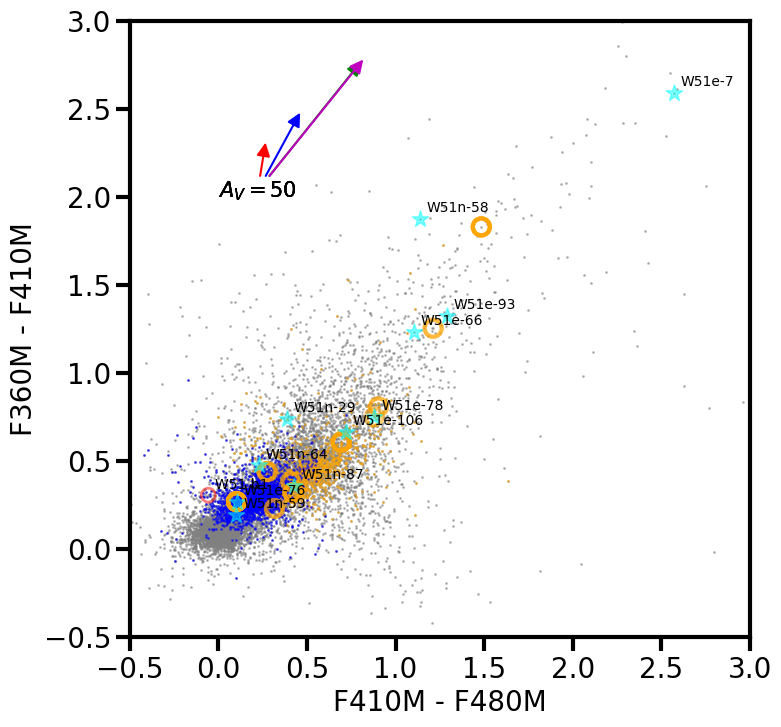

In [68]:
#410-480 vs 360-410

fig = plt.figure(figsize=(8,8))
ax = fig.add_subplot(111)
ax.scatter(f410m_mag[0] - f480m_mag[0], f360m_mag[0]-f410m_mag[0], s=1, c='gray', alpha=0.5)
ax.scatter(f410m_mag[0][upper_idx] - f480m_mag[0][upper_idx], f360m_mag[0][upper_idx]-f410m_mag[0][upper_idx], s=1, c='orange', alpha=0.5, label='Upper branch')
ax.scatter(f410m_mag[0][lower_idx] - f480m_mag[0][lower_idx], f360m_mag[0][lower_idx]-f410m_mag[0][lower_idx], s=1, c='blue', alpha=0.5, label='Lower branch')
ax.scatter(f410m_matched_vla_mag - f480m_matched_vla_mag, f360m_matched_vla_mag-f410m_matched_vla_mag, s=150, edgecolor='orange', lw=3, facecolor='none',  alpha=0.5, label='VLA sources')
ax.scatter(np.array(mag_f410m_w51e_arr) - np.array(mag_f480m_w51e_arr), np.array(mag_f360m_w51e_arr)-np.array(mag_f410m_w51e_arr), s=150, c='cyan', marker='*',alpha=0.5, label='W51e ALMA sources')
ax.scatter(np.array(mag_f410m_w51n_arr) - np.array(mag_f480m_w51n_arr), np.array(mag_f360m_w51n_arr)-np.array(mag_f410m_w51n_arr), s=150, c='cyan', marker='*', alpha=0.5, label='W51n ALMA sources')
ii=0
for alma_idx, jwst_idx in zip(w51e_matched_idx, matching_idx_w51e_arr):
    if jwst_idx is not np.nan:
        ax.annotate(f'W51e-{alma_idx}', (np.array(mag_f410m_w51e_arr)[ii] - np.array(mag_f480m_w51e_arr)[ii],
                                np.array(mag_f360m_w51e_arr)[ii]-np.array(mag_f410m_w51e_arr)[ii]),
                textcoords="offset points", xytext=(5,5), ha='left', color='k', fontsize=10)
        ii += 1
ii=0
for alma_idx, jwst_idx in zip(w51n_matched_idx, matching_idx_w51n_arr):
    if jwst_idx is not np.nan:
        ax.annotate(f'W51n-{alma_idx}', (np.array(mag_f410m_w51n_arr)[ii] - np.array(mag_f480m_w51n_arr)[ii],
                                np.array(mag_f360m_w51n_arr)[ii]-np.array(mag_f410m_w51n_arr)[ii]),
                textcoords="offset points", xytext=(5,5), ha='left', color='k', fontsize=10)
        ii += 1
# HeI(1-0) and Br gamma, O9.5 (Barbosa+22)
ax.scatter(f410m_mag[0][2889] - f480m_mag[0][2889], f360m_mag[0][2889]-f410m_mag[0][2889], s=100, edgecolor='red', facecolor='none',lw=2, alpha=0.5)
ax.annotate('W51 b1', (f410m_mag[0].value[2889] - f480m_mag[0].value[2889], f360m_mag[0].value[2889]-f410m_mag[0].value[2889]), textcoords="offset points", xytext=(5,5), ha='left', color='k', fontsize=10)
# HeI and Br gamma emission, O9.5 star  (Barbosa+22)
ax.scatter(f410m_mag[0][2899] - f480m_mag[0][2899], f360m_mag[0][2899]-f410m_mag[0][2899], s=100, edgecolor='red', facecolor='none',lw=2, alpha=0.5)
ax.annotate('W51 b2', (f410m_mag[0].value[2899] - f480m_mag[0].value[2899], f360m_mag[0].value[2899]-f410m_mag[0].value[2899]), textcoords="offset points", xytext=(5,5), ha='left', color='k', fontsize=10)
# c1 - not sure if it is driving source, O9 star (Barbosa+22)
ax.scatter(f410m_mag[0][7656] - f480m_mag[0][7656], f360m_mag[0][7656]-f410m_mag[0][7656], s=100, edgecolor='red', facecolor='none',lw=2,alpha=0.5)
ax.annotate('W51 c1', (f410m_mag[0].value[7656] - f480m_mag[0].value[7656], f360m_mag[0].value[7656]-f410m_mag[0].value[7656]), textcoords="offset points", xytext=(5,5), ha='left', color='k', fontsize=10)
# e7 - O9.5 (Barbosa+22), B star (Bik+19)
ax.scatter(f410m_mag[0][7220] - f480m_mag[0][7220], f360m_mag[0][7220]-f410m_mag[0][7220], s=100, edgecolor='red', facecolor='none', lw=2,alpha=0.5)
ax.annotate('W51 e7', (f410m_mag[0].value[7220] - f480m_mag[0].value[7220], f360m_mag[0].value[7220]-f410m_mag[0].value[7220]), textcoords="offset points", xytext=(5,5), ha='left', color='k', fontsize=10)
ax.set_xlabel('F410M - F480M')
ax.set_ylabel('F360M - F410M')
for ext_model, labels, c in zip([CT06_MWLoc(), RL85_MWGC(), G21_MWAvg(), RRP89_MWGC(), G24_SMCAvg()], ['CT06 MWLoc', 'RL85 MWGC', 'G21 MWAvg', 'RRP89 MWGC', 'G24 SMCAvg'], colorlist):
    print(ext_model)
    plot_extvec_ccd(ax, color1=('f410m', 'f480m'), color2=('f360m', 'f410m'),
                     ext=ext_model, extvec_scale=50, color=c,
                      start=(0,2), label=labels)
ax.set_xlim(-0.5,3)
ax.set_ylim(-0.5,3)

Text(0, 0.5, 'F360M - F480M')

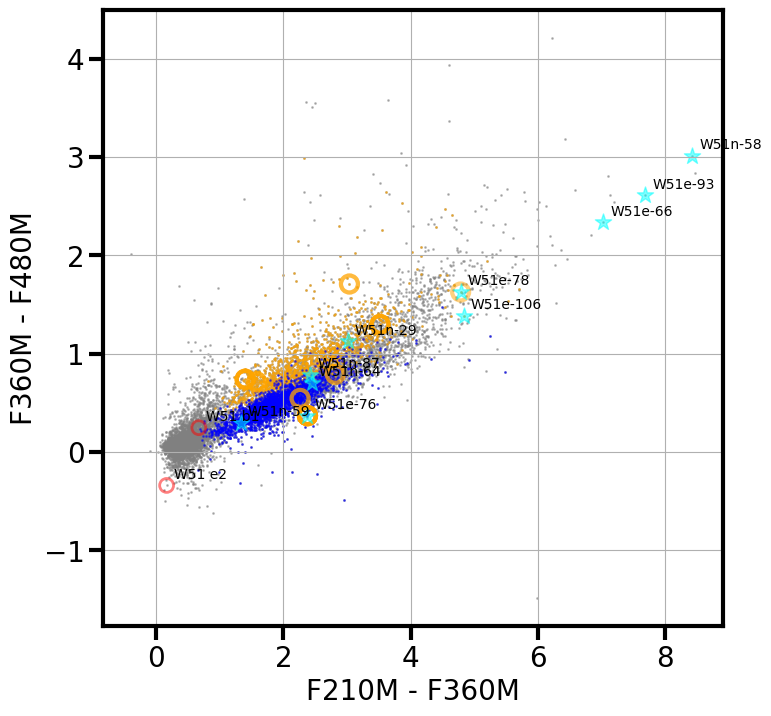

In [69]:
#plot f210-f360 vs f360-f480
fig = plt.figure(figsize=(8,8))
ax = fig.add_subplot(111)
ax.scatter(f210m_mag[0] - f360m_mag[0], f360m_mag[0]-f480m_mag[0], s=1, c='gray', alpha=0.5)
ax.scatter(f210m_mag[0][upper_idx] - f360m_mag[0][upper_idx], f360m_mag[0][upper_idx]-f480m_mag[0][upper_idx], s=1, c='orange', alpha=0.5, label='Upper branch')
ax.scatter(f210m_mag[0][lower_idx] - f360m_mag[0][lower_idx], f360m_mag[0][lower_idx]-f480m_mag[0][lower_idx], s=1, c='blue', alpha=0.5, label='Lower branch')
ax.scatter(f210m_matched_vla_mag - f360m_matched_vla_mag, f360m_matched_vla_mag-f480m_matched_vla_mag, s=150, edgecolor='orange', lw=3, facecolor='none',  alpha=0.5, label='VLA sources')
ax.scatter(np.array(mag_f210m_w51e_arr) - np.array(mag_f360m_w51e_arr), np.array(mag_f360m_w51e_arr)-np.array(mag_f480m_w51e_arr), s=150, c='cyan', marker='*',alpha=0.5, label='W51e ALMA sources')
ax.scatter(np.array(mag_f210m_w51n_arr) - np.array(mag_f360m_w51n_arr), np.array(mag_f360m_w51n_arr)-np.array(mag_f480m_w51n_arr), s=150, c='cyan', marker='*', alpha=0.5, label='W51n ALMA sources')
ii=0
for alma_idx, jwst_idx in zip(w51e_matched_idx, matching_idx_w51e_arr):
    if jwst_idx is not np.nan:
        ax.annotate(f'W51e-{alma_idx}', (np.array(mag_f210m_w51e_arr)[ii] - np.array(mag_f360m_w51e_arr)[ii],
                                np.array(mag_f360m_w51e_arr)[ii]-np.array(mag_f480m_w51e_arr)[ii]),
                textcoords="offset points", xytext=(5,5), ha='left', color='k', fontsize=10)
        ii += 1
ii=0
for alma_idx, jwst_idx in zip(w51n_matched_idx, matching_idx_w51n_arr):
    if jwst_idx is not np.nan:
        ax.annotate(f'W51n-{alma_idx}', (np.array(mag_f210m_w51n_arr)[ii] - np.array(mag_f360m_w51n_arr)[ii],
                                np.array(mag_f360m_w51n_arr)[ii]-np.array(mag_f480m_w51n_arr)[ii]),
                textcoords="offset points", xytext=(5,5), ha='left', color='k', fontsize=10)
        ii += 1
# HeI(1-0) and Br gamma, O9.5 (Barbosa+22)
ax.scatter(f210m_mag[0][2889] - f360m_mag[0][2889], f360m_mag[0][2889]-f480m_mag[0][2889], s=100, edgecolor='red', facecolor='none',lw=2, alpha=0.5)
ax.annotate('W51 b1', (f210m_mag[0].value[2889] - f360m_mag[0].value[2889], f360m_mag[0].value[2889]-f480m_mag[0].value[2889]), textcoords="offset points", xytext=(5,5), ha='left', color='k', fontsize=10)
# HeI and Br gamma emission, O9.5 star  (Barbosa+22)
ax.scatter(f210m_mag[0][2899] - f360m_mag[0][2899], f360m_mag[0][2899]-f480m_mag[0][2899], s=100, edgecolor='red', facecolor='none',lw=2, alpha=0.5)
ax.annotate('W51 b2', (f210m_mag[0].value[2899] - f360m_mag[0].value[2899], f360m_mag[0].value[2899]-f480m_mag[0].value[2899]), textcoords="offset points", xytext=(5,5), ha='left', color='k', fontsize=10)
# c1 - not sure if it is driving source, O9 star (Barbosa+22)
ax.scatter(f210m_mag[0][7656] - f360m_mag[0][7656], f360m_mag[0][7656]-f480m_mag[0][7656], s=100, edgecolor='red', facecolor='none',lw=2,alpha=0.5)
ax.annotate('W51 c1', (f210m_mag[0].value[7656] - f360m_mag[0].value[7656], f360m_mag[0].value[7656]-f480m_mag[0].value[7656]), textcoords="offset points", xytext=(5,5), ha='left', color='k', fontsize=10)
# e7 - O9.5 (Barbosa+22), B star (Bik+19)
ax.scatter(f210m_mag[0][7220] - f360m_mag[0][7220], f360m_mag[0][7220]-f480m_mag[0][7220], s=100, edgecolor='red', facecolor='none', lw=2,alpha=0.5)
ax.annotate('W51 e7', (f210m_mag[0].value[7220] - f360m_mag[0].value[7220], f360m_mag[0].value[7220]-f480m_mag[0].value[7220]), textcoords="offset points", xytext=(5,5), ha='left', color='k', fontsize=10)
ax.scatter(f210m_mag[0][13814] - f360m_mag[0][13814], f360m_mag[0][13814]-f480m_mag[0][13814], s=100, edgecolor='red', facecolor='none', lw=2,alpha=0.5)
ax.annotate('W51 e2', (f210m_mag[0].value[13814] - f360m_mag[0].value[13814], f360m_mag[0].value[13814]-f480m_mag[0].value[13814]), textcoords="offset points", xytext=(5,5), ha='left', color='k', fontsize=10)
ax.grid()
ax.set_xlabel('F210M - F360M')
ax.set_ylabel('F360M - F480M')

Text(0, 0.5, 'F480M - f2100w')

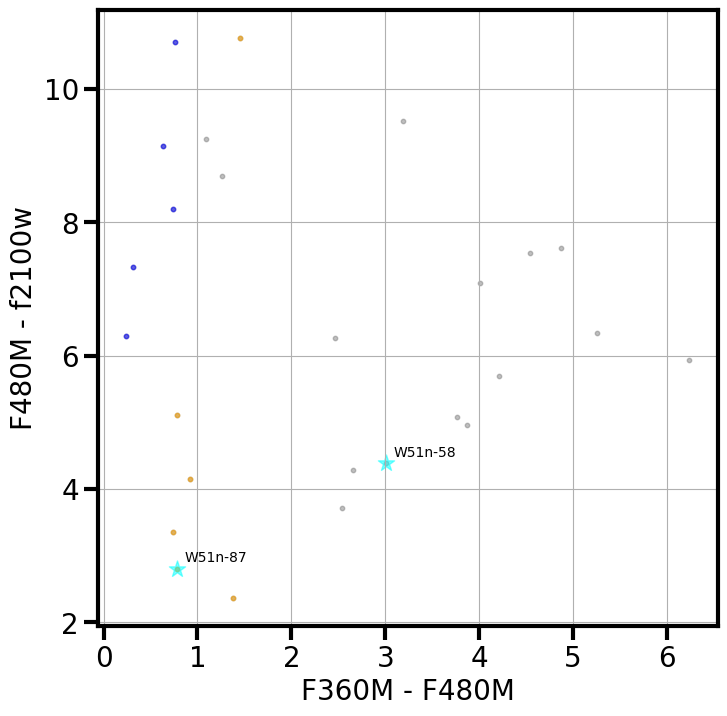

In [70]:
# 360-480 vs 480-2100
fig = plt.figure(figsize=(8,8))
ax = fig.add_subplot(111)
ax.scatter(f360m_mag[0] - f480m_mag[0], f480m_mag[0]-f2100w_mag[0], s=10, c='gray', alpha=0.5)
ax.scatter(f360m_mag[0][upper_idx] - f480m_mag[0][upper_idx], f480m_mag[0][upper_idx]-f2100w_mag[0][upper_idx], s=10, c='orange', alpha=0.5, label='Upper branch')
ax.scatter(f360m_mag[0][lower_idx] - f480m_mag[0][lower_idx], f480m_mag[0][lower_idx]-f2100w_mag[0][lower_idx], s=10, c='blue', alpha=0.5, label='Lower branch')
ax.scatter(f360m_matched_vla_mag - f480m_matched_vla_mag, f480m_matched_vla_mag-f2100w_matched_vla_mag, s=150, edgecolor='orange', lw=3, facecolor='none',  alpha=0.5, label='VLA sources')
ax.scatter(np.array(mag_f360m_w51e_arr) - np.array(mag_f480m_w51e_arr), np.array(mag_f480m_w51e_arr)-np.array(mag_f2100w_w51e_arr), s=150, c='cyan', marker='*',alpha=0.5, label='W51e ALMA sources')
ax.scatter(np.array(mag_f360m_w51n_arr) - np.array(mag_f480m_w51n_arr), np.array(mag_f480m_w51n_arr)-np.array(mag_f2100w_w51n_arr), s=150, c='cyan', marker='*', alpha=0.5, label='W51n ALMA sources')  
ii=0
for alma_idx, jwst_idx in zip(w51e_matched_idx, matching_idx_w51e_arr):
    if jwst_idx is not np.nan:
        ax.annotate(f'W51e-{alma_idx}', (np.array(mag_f360m_w51e_arr)[ii] - np.array(mag_f480m_w51e_arr)[ii],
                                np.array(mag_f480m_w51e_arr)[ii]-np.array(mag_f2100w_w51e_arr)[ii]),
                textcoords="offset points", xytext=(5,5), ha='left', color='k', fontsize=10)
        ii += 1 
ii=0
for alma_idx, jwst_idx in zip(w51n_matched_idx, matching_idx_w51n_arr):
    if jwst_idx is not np.nan:
        ax.annotate(f'W51n-{alma_idx}', (np.array(mag_f360m_w51n_arr)[ii] - np.array(mag_f480m_w51n_arr)[ii],
                                np.array(mag_f480m_w51n_arr)[ii]-np.array(mag_f2100w_w51n_arr)[ii]),
                textcoords="offset points", xytext=(5,5), ha='left', color='k', fontsize=10)
        ii += 1
# HeI(1-0) and Br gamma, O9.5 (Barbosa+22)
ax.scatter(f360m_mag[0][2889] - f480m_mag[0][2889], f480m_mag[0][2889]-f2100w_mag[0][2889], s=100, edgecolor='red', facecolor='none',lw=2, alpha=0.5)
ax.annotate('W51 b1', (f360m_mag[0].value[2889] - f480m_mag[0].value[2889], f480m_mag[0].value[2889]-f2100w_mag[0].value[2889]), textcoords="offset points", xytext=(5,5), ha='left', color='k', fontsize=10)
# HeI and Br gamma emission, O9.5 star  (Barbosa+22)
ax.scatter(f360m_mag[0][2899] - f480m_mag[0][2899], f480m_mag[0][2899]-f2100w_mag[0][2899], s=100, edgecolor='red', facecolor='none',lw=2, alpha=0.5)
ax.annotate('W51 b2', (f360m_mag[0].value[2899] - f480m_mag[0].value[2899], f480m_mag[0].value[2899]-f2100w_mag[0].value[2899]), textcoords="offset points", xytext=(5,5), ha='left', color='k', fontsize=10)
# c1 - not sure if it is driving source, O9 star (Barbosa+22)
ax.scatter(f360m_mag[0][7656] - f480m_mag[0][7656], f480m_mag[0][7656]-f2100w_mag[0][7656], s=100, edgecolor='red', facecolor='none',lw=2,alpha=0.5)
ax.annotate('W51 c1', (f360m_mag[0].value[7656] - f480m_mag[0].value[7656], f480m_mag[0].value[7656]-f2100w_mag[0].value[7656]), textcoords="offset points", xytext=(5,5), ha='left', color='k', fontsize=10)
# e7 - O9.5 (Barbosa+22), B star (Bik+19)
ax.scatter(f360m_mag[0][7220] - f480m_mag[0][7220], f480m_mag[0][7220]-f2100w_mag[0][7220], s=100, edgecolor='red', facecolor='none', lw=2,alpha=0.5)
ax.annotate('W51 e7', (f360m_mag[0].value[7220] - f480m_mag[0].value[7220], f480m_mag[0].value[7220]-f2100w_mag[0].value[7220]), textcoords="offset points", xytext=(5,5), ha='left', color='k', fontsize=10)
ax.scatter(f360m_mag[0][13814] - f480m_mag[0][13814], f480m_mag[0][13814]-f2100w_mag[0][13814], s=100, edgecolor='red', facecolor='none', lw=2,alpha=0.5)
ax.annotate('W51 e2', (f360m_mag[0].value[13814] - f480m_mag[0].value[13814], f480m_mag[0].value[13814]-f2100w_mag[0].value[13814]), textcoords="offset points", xytext=(5,5), ha='left', color='k', fontsize=10)
ax.grid()
ax.set_xlabel('F360M - F480M')
ax.set_ylabel('F480M - f2100w')


Text(0, 0.5, 'F360M - F480M')

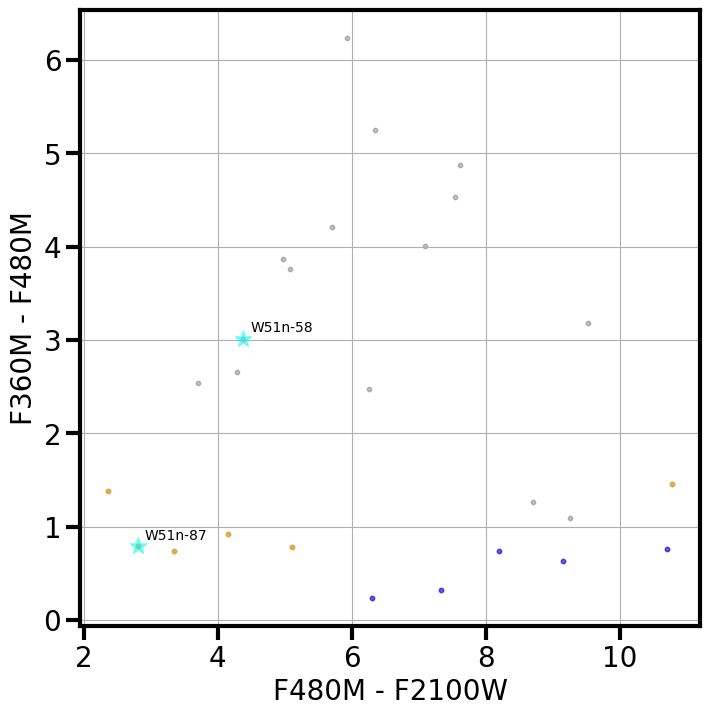

In [71]:
#480-2100 vs 360-480
fig = plt.figure(figsize=(8,8))
ax = fig.add_subplot(111)
ax.scatter(f480m_mag[0] - f2100w_mag[0], f360m_mag[0]-f480m_mag[0], s=10, c='gray', alpha=0.5)
ax.scatter(f480m_mag[0][upper_idx] - f2100w_mag[0][upper_idx], f360m_mag[0][upper_idx]-f480m_mag[0][upper_idx], s=10, c='orange', alpha=0.5, label='Upper branch')
ax.scatter(f480m_mag[0][lower_idx] - f2100w_mag[0][lower_idx], f360m_mag[0][lower_idx]-f480m_mag[0][lower_idx], s=10, c='blue', alpha=0.5, label='Lower branch')
ax.scatter(f480m_matched_vla_mag - f2100w_matched_vla_mag, f360m_matched_vla_mag-f480m_matched_vla_mag, s=150, edgecolor='orange', lw=3, facecolor='none',  alpha=0.5, label='VLA sources')
ax.scatter(np.array(mag_f480m_w51e_arr) - np.array(mag_f2100w_w51e_arr), np.array(mag_f360m_w51e_arr)-np.array(mag_f480m_w51e_arr), s=150, c='cyan', marker='*',alpha=0.5, label='W51e ALMA sources')
ax.scatter(np.array(mag_f480m_w51n_arr) - np.array(mag_f2100w_w51n_arr), np.array(mag_f360m_w51n_arr)-np.array(mag_f480m_w51n_arr), s=150, c='cyan', marker='*', alpha=0.5, label='W51n ALMA sources')
ii=0
for alma_idx, jwst_idx in zip(w51e_matched_idx, matching_idx_w51e_arr):
    if jwst_idx is not np.nan:
        ax.annotate(f'W51e-{alma_idx}', (np.array(mag_f480m_w51e_arr)[ii] - np.array(mag_f2100w_w51e_arr)[ii],
                                np.array(mag_f360m_w51e_arr)[ii]-np.array(mag_f480m_w51e_arr)[ii]),
                textcoords="offset points", xytext=(5,5), ha='left', color='k', fontsize=10)
        ii += 1
ii=0
for alma_idx, jwst_idx in zip(w51n_matched_idx, matching_idx_w51n_arr):
    if jwst_idx is not np.nan:
        ax.annotate(f'W51n-{alma_idx}', (np.array(mag_f480m_w51n_arr)[ii] - np.array(mag_f2100w_w51n_arr)[ii],
                                np.array(mag_f360m_w51n_arr)[ii]-np.array(mag_f480m_w51n_arr)[ii]),
                textcoords="offset points", xytext=(5,5), ha='left', color='k', fontsize=10)
        ii += 1
# HeI(1-0) and Br gamma, O9.5 (Barbosa+22)
ax.scatter(f480m_mag[0][2889] - f2100w_mag[0][2889], f360m_mag[0][2889]-f480m_mag[0][2889], s=100, edgecolor='red', facecolor='none',lw=2, alpha=0.5)
ax.annotate('W51 b1', (f480m_mag[0].value[2889] - f2100w_mag[0].value[2889], f360m_mag[0].value[2889]-f480m_mag[0].value[2889]), textcoords="offset points", xytext=(5,5), ha='left', color='k', fontsize=10)
# HeI and Br gamma emission, O9.5 star  (Barbosa+22)
ax.scatter(f480m_mag[0][2899] - f2100w_mag[0][2899], f360m_mag[0][2899]-f480m_mag[0][2899], s=100, edgecolor='red', facecolor='none',lw=2, alpha=0.5)
ax.annotate('W51 b2', (f480m_mag[0].value[2899] - f2100w_mag[0].value[2899], f360m_mag[0].value[2899]-f480m_mag[0].value[2899]), textcoords="offset points", xytext=(5,5), ha='left', color='k', fontsize=10)
# c1 - not sure if it is driving source, O9 star (Barbosa+22)
ax.scatter(f480m_mag[0][7656] - f2100w_mag[0][7656], f360m_mag[0][7656]-f480m_mag[0][7656], s=100, edgecolor='red', facecolor='none',lw=2,alpha=0.5)
ax.annotate('W51 c1', (f480m_mag[0].value[7656] - f2100w_mag[0].value[7656], f360m_mag[0].value[7656]-f480m_mag[0].value[7656]), textcoords="offset points", xytext=(5,5), ha='left', color='k', fontsize=10)
# e7 - O9.5 (Barbosa+22), B star (Bik+19)
ax.scatter(f480m_mag[0][7220] - f2100w_mag[0][7220], f360m_mag[0][7220]-f480m_mag[0][7220], s=100, edgecolor='red', facecolor='none', lw=2,alpha=0.5)
ax.annotate('W51 e7', (f480m_mag[0].value[7220] - f2100w_mag[0].value[7220], f360m_mag[0].value[7220]-f480m_mag[0].value[7220]), textcoords="offset points", xytext=(5,5), ha='left', color='k', fontsize=10)
ax.scatter(f480m_mag[0][13814] - f2100w_mag[0][13814], f360m_mag[0][13814]-f480m_mag[0][13814], s=100, edgecolor='red', facecolor='none', lw=2,alpha=0.5)
ax.annotate('W51 e2', (f480m_mag[0].value[13814] - f2100w_mag[0].value[13814], f360m_mag[0].value[13814]-f480m_mag[0].value[13814]), textcoords="offset points", xytext=(5,5), ha='left', color='k', fontsize=10)
ax.grid()
ax.set_xlabel('F480M - F2100W')
ax.set_ylabel('F360M - F480M')

3.6 um 4.8 um 3.6 um
3.6 um 4.8 um 3.6 um
2.998837333333334 2.42466 2.998837333333334
3.6 um 4.8 um 3.6 um
3.6 um 4.8 um 3.6 um
2.720512820512821 1.15 2.720512820512821
3.6 um 4.8 um 3.6 um
3.6 um 4.8 um 3.6 um
2.754347461357901 1.8157051852626855 2.754347461357901
3.6 um 4.8 um 3.6 um
3.6 um 4.8 um 3.6 um
3.2155007883163207 1.6181229773462702 3.2155007883163207
3.6 um 4.8 um 3.6 um
Extinction vector not plotted: Input x outside of range defined for G24_SMCAvg [0.3 <= x <= 10.0, x has units 1/micron]


(22.0, 10.0)

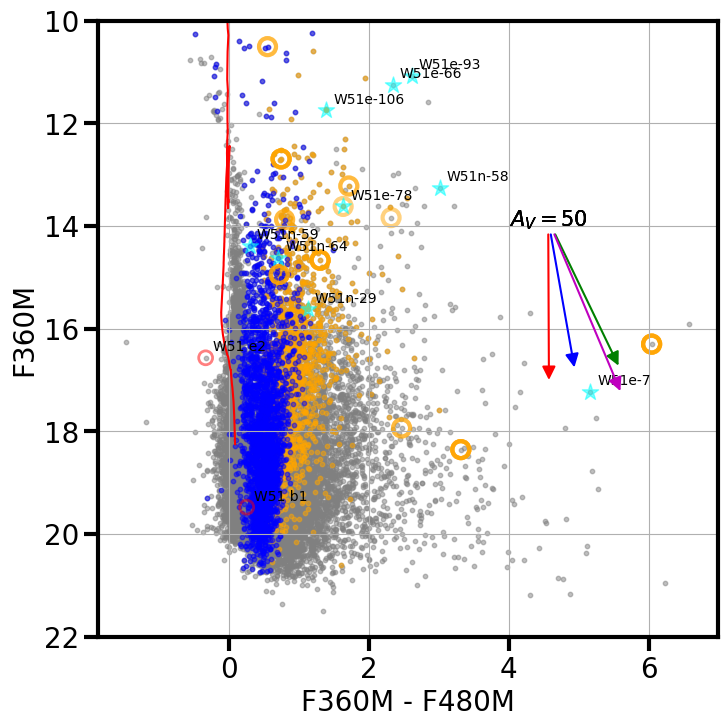

In [72]:
#360-480 vs 360

fig = plt.figure(figsize=(8,8))
ax = fig.add_subplot(111)
ax.scatter(f360m_mag[0] - f480m_mag[0], f360m_mag[0], s=10, c='gray', alpha=0.5)
ax.scatter(f360m_mag[0][upper_idx] - f480m_mag[0][upper_idx], f360m_mag[0][upper_idx], s=10, c='orange', alpha=0.5, label='Upper branch')
ax.scatter(f360m_mag[0][lower_idx] - f480m_mag[0][lower_idx], f360m_mag[0][lower_idx], s=10, c='blue', alpha=0.5, label='Lower branch')
ax.scatter(f360m_matched_vla_mag - f480m_matched_vla_mag, f360m_matched_vla_mag, s=150, edgecolor='orange', lw=3, facecolor='none',  alpha=0.5, label='VLA sources')
ax.scatter(np.array(mag_f360m_w51e_arr) - np.array(mag_f480m_w51e_arr), np.array(mag_f360m_w51e_arr), s=150, c='cyan', marker='*',alpha=0.5, label='W51e ALMA sources')
ax.scatter(np.array(mag_f360m_w51n_arr) - np.array(mag_f480m_w51n_arr), np.array(mag_f360m_w51n_arr), s=150, c='cyan', marker='*', alpha=0.5, label='W51n ALMA sources')  
ii=0
for alma_idx, jwst_idx in zip(w51e_matched_idx, matching_idx_w51e_arr):
    if jwst_idx is not np.nan:
        ax.annotate(f'W51e-{alma_idx}', (np.array(mag_f360m_w51e_arr)[ii] - np.array(mag_f480m_w51e_arr)[ii],
                                np.array(mag_f360m_w51e_arr)[ii]),
                textcoords="offset points", xytext=(5,5), ha='left', color='k', fontsize=10)
        ii += 1
ii=0
for alma_idx, jwst_idx in zip(w51n_matched_idx, matching_idx_w51n_arr):
    if jwst_idx is not np.nan:
        ax.annotate(f'W51n-{alma_idx}', (np.array(mag_f360m_w51n_arr)[ii] - np.array(mag_f480m_w51n_arr)[ii],
                                np.array(mag_f360m_w51n_arr)[ii]),
                textcoords="offset points", xytext=(5,5), ha='left', color='k', fontsize=10)
        ii += 1
# HeI(1-0) and Br gamma, O9.5 (Barbosa+22)
ax.scatter(f360m_mag[0][2889] - f480m_mag[0][2889], f360m_mag[0][2889], s=100, edgecolor='red', facecolor='none',lw=2, alpha=0.5)
ax.annotate('W51 b1', (f360m_mag[0].value[2889] - f480m_mag[0].value[2889], f360m_mag[0].value[2889]), textcoords="offset points", xytext=(5,5), ha='left', color='k', fontsize=10)
# HeI and Br gamma emission, O9.5 star  (Barbosa+22)
ax.scatter(f360m_mag[0][2899] - f480m_mag[0][2899], f360m_mag[0][2899], s=100, edgecolor='red', facecolor='none',lw=2, alpha=0.5)
ax.annotate('W51 b2', (f360m_mag[0].value[2899] - f480m_mag[0].value[2899], f360m_mag[0].value[2899]), textcoords="offset points", xytext=(5,5), ha='left', color='k', fontsize=10)
# c1 - not sure if it is driving source, O9 star (Barbosa+22)
ax.scatter(f360m_mag[0][7656] - f480m_mag[0][7656], f360m_mag[0][7656], s=100, edgecolor='red', facecolor='none',lw=2,alpha=0.5)
ax.annotate('W51 c1', (f360m_mag[0].value[7656] - f480m_mag[0].value[7656], f360m_mag[0].value[7656]), textcoords="offset points", xytext=(5,5), ha='left', color='k', fontsize=10)
# e7 - O9.5 (Barbosa+22), B star (Bik+19)
ax.scatter(f360m_mag[0][7220] - f480m_mag[0][7220], f360m_mag[0][7220], s=100, edgecolor='red', facecolor='none', lw=2,alpha=0.5)
ax.annotate('W51 e7', (f360m_mag[0].value[7220] - f480m_mag[0].value[7220], f360m_mag[0].value[7220]), textcoords="offset points", xytext=(5,5), ha='left', color='k', fontsize=10)
ax.scatter(f360m_mag[0][13814] - f480m_mag[0][13814], f360m_mag[0][13814], s=100, edgecolor='red', facecolor='none', lw=2,alpha=0.5)
ax.annotate('W51 e2', (f360m_mag[0].value[13814] - f480m_mag[0].value[13814], f360m_mag[0].value[13814]), textcoords="offset points", xytext=(5,5), ha='left', color='k', fontsize=10)
ax.grid()
ax.set_xlabel('F360M - F480M')
ax.set_ylabel('F360M')
for ext_model, labels, c in zip([CT06_MWLoc(), RL85_MWGC(), G21_MWAvg(), RRP89_MWGC(), G24_SMCAvg()], ['CT06 MWLoc', 'RL85 MWGC', 'G21 MWAvg', 'RRP89 MWGC', 'G24 SMCAvg'], colorlist):
    plot_extvec_cmd(ax, color1=('f360m', 'f480m'), mag1=('f360m',),
                     ext=ext_model, extvec_scale=50, color=c,
                      start=(4,14), label=labels)

ax.plot(F360Mmag_av0[age_idx] - F480Mmag_av0[age_idx], F360Mmag_av0[age_idx], color='r')
ax.set_ylim(22, 10)

# select the sources 

Model: CT06_MWLoc
Inputs: ('x',)
Outputs: ('y',)
Model set size: 1
Parameters:
4.1 um 4.8 um 4.1 um
4.1 um 4.8 um 4.1 um
2.691064975609756 2.42466 2.691064975609756
Model: RL85_MWGC
Inputs: ('x',)
Outputs: ('y',)
Model set size: 1
Parameters:
4.1 um 4.8 um 4.1 um
4.1 um 4.8 um 4.1 um
1.9544090056285186 1.15 1.9544090056285186
Model: G21_MWAvg
Inputs: ('x',)
Outputs: ('y',)
Model set size: 1
Parameters:
4.1 um 4.8 um 4.1 um
4.1 um 4.8 um 4.1 um
2.277132533294349 1.8157051852626855 2.277132533294349
Model: RRP89_MWGC
Inputs: ('x',)
Outputs: ('y',)
Model set size: 1
Parameters:
4.1 um 4.8 um 4.1 um
4.1 um 4.8 um 4.1 um
2.4362921000382474 1.6181229773462702 2.4362921000382474
Model: G24_SMCAvg
Inputs: ('x',)
Outputs: ('y',)
Model set size: 1
Parameters:
4.1 um 4.8 um 4.1 um
Extinction vector not plotted: Input x outside of range defined for G24_SMCAvg [0.3 <= x <= 10.0, x has units 1/micron]


(22.0, 7.0)

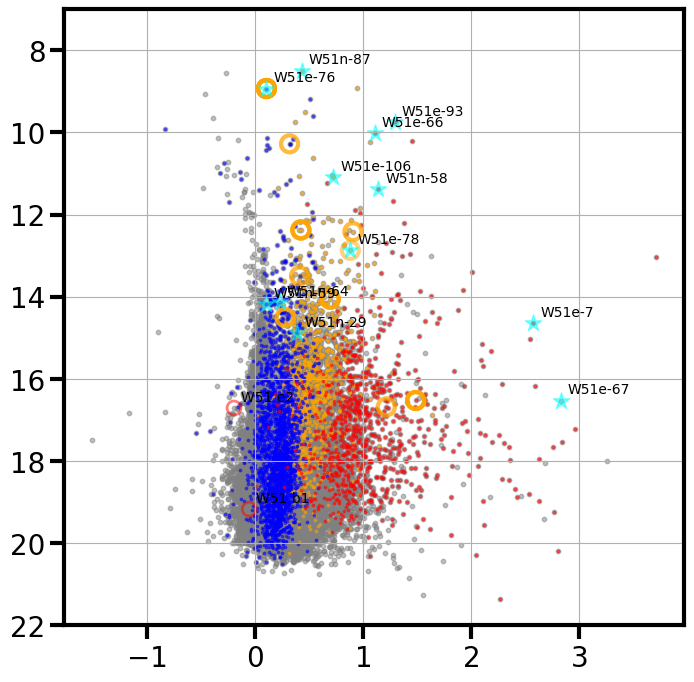

In [73]:
#410 vs 410-480
missing_nir_idx = ~np.isfinite(f162) | ~np.isfinite(f210)
missing_nir_idx_red = missing_nir_idx & (f360m_mag[0].value - f480m_mag[0].value > 1.5)
fig = plt.figure(figsize=(8,8))
ax = fig.add_subplot(111)
ax.scatter(f410m_mag[0] - f480m_mag[0], f410m_mag[0], s=10, c='gray', alpha=0.5)
ax.scatter(f410m_mag[0][upper_idx] - f480m_mag[0][upper_idx], f410m_mag[0][upper_idx], s=3, c='orange', alpha=0.5, label='Upper branch')
ax.scatter(f410m_mag[0][lower_idx] - f480m_mag[0][lower_idx], f410m_mag[0][lower_idx], s=3, c='blue', alpha=0.5, label='Lower branch')
ax.scatter(f410m_mag[0][missing_nir_idx_red] - f480m_mag[0][missing_nir_idx_red], f410m_mag[0][missing_nir_idx_red], s=3, c='r', alpha=0.5, label='Missing NIR')
ax.scatter(f410m_matched_vla_mag - f480m_matched_vla_mag, f410m_matched_vla_mag, s=150, edgecolor='orange', lw=3, facecolor='none',  alpha=0.5, label='VLA sources')
ax.scatter(np.array(mag_f410m_w51e_arr) - np.array(mag_f480m_w51e_arr), np.array(mag_f410m_w51e_arr), s=150, c='cyan', marker='*',alpha=0.5, label='W51e ALMA sources')
ax.scatter(np.array(mag_f410m_w51n_arr) - np.array(mag_f480m_w51n_arr), np.array(mag_f410m_w51n_arr), s=150, c='cyan', marker='*', alpha=0.5, label='W51n ALMA sources')  
ii=0
for alma_idx, jwst_idx in zip(w51e_matched_idx, matching_idx_w51e_arr):
    if jwst_idx is not np.nan:
        ax.annotate(f'W51e-{alma_idx}', (np.array(mag_f410m_w51e_arr)[ii] - np.array(mag_f480m_w51e_arr)[ii],
                                np.array(mag_f410m_w51e_arr)[ii]),
                textcoords="offset points", xytext=(5,5), ha='left', color='k', fontsize=10)
        ii += 1
ii=0
for alma_idx, jwst_idx in zip(w51n_matched_idx, matching_idx_w51n_arr):
    if jwst_idx is not np.nan:
        ax.annotate(f'W51n-{alma_idx}', (np.array(mag_f410m_w51n_arr)[ii] - np.array(mag_f480m_w51n_arr)[ii],
                                np.array(mag_f410m_w51n_arr)[ii]),
                textcoords="offset points", xytext=(5,5), ha='left', color='k', fontsize=10)
        ii += 1 
ax.scatter(f410m_mag[0][2889] - f480m_mag[0][2889], f410m_mag[0][2889], s=100, edgecolor='red', facecolor='none',lw=2, alpha=0.5)
ax.annotate('W51 b1', (f410m_mag[0].value[2889] - f480m_mag[0].value[2889], f410m_mag[0].value[2889]), textcoords="offset points", xytext=(5,5), ha='left', color='k', fontsize=10)
ax.scatter(f410m_mag[0][2899] - f480m_mag[0][2899], f410m_mag[0][2899], s=100, edgecolor='red', facecolor='none',lw=2, alpha=0.5)
ax.annotate('W51 b2', (f410m_mag[0].value[2899] - f480m_mag[0].value[2899], f410m_mag[0].value[2899]), textcoords="offset points", xytext=(5,5), ha='left', color='k', fontsize=10)
ax.scatter(f410m_mag[0][7656] - f480m_mag[0][7656], f410m_mag[0][7656], s=100, edgecolor='red', facecolor='none',lw=2,alpha=0.5)
ax.annotate('W51 c1', (f410m_mag[0].value[7656] - f480m_mag[0].value[7656], f410m_mag[0].value[7656]), textcoords="offset points", xytext=(5,5), ha='left', color='k', fontsize=10)
ax.scatter(f410m_mag[0][7220] - f480m_mag[0][7220], f410m_mag[0][7220], s=100, edgecolor='red', facecolor='none', lw=2,alpha=0.5)
ax.annotate('W51 e7', (f410m_mag[0].value[7220] - f480m_mag[0].value[7220], f410m_mag[0].value[7220]), textcoords="offset points", xytext=(5,5), ha='left', color='k', fontsize=10)
ax.scatter(f410m_mag[0][13814] - f480m_mag[0][13814], f410m_mag[0][13814], s=100, edgecolor='red', facecolor='none', lw=2,alpha=0.5)
ax.annotate('W51 e2', (f410m_mag[0].value[13814] - f480m_mag[0].value[13814], f410m_mag[0].value[13814]), textcoords="offset points", xytext=(5,5), ha='left', color='k', fontsize=10)  

for ext_model, labels, c in zip([CT06_MWLoc(), RL85_MWGC(), G21_MWAvg(), RRP89_MWGC(), G24_SMCAvg()], ['CT06 MWLoc', 'RL85 MWGC', 'G21 MWAvg', 'RRP89 MWGC', 'G24 SMCAvg'], colorlist):
    print(ext_model)
    plot_extvec_cmd(ax, color1=('f410m', 'f480m'), mag1=('f410m',),
                     ext=ext_model, extvec_scale=50, color=c,
                      start=(4,14), label=labels)
ax.grid()
ax.set_ylim(22, 7)

1.62 um 2.1 um 1.62 um
1.62 um 2.1 um 1.62 um
8.970550123456789 5.7899519999999995 8.970550123456789
1.62 um 2.1 um 1.62 um
1.62 um 2.1 um 1.62 um
9.05960648148148 6.121052631578948 9.05960648148148
1.62 um 2.1 um 1.62 um
1.62 um 2.1 um 1.62 um
8.961676548404936 6.104216251351036 8.961676548404936
1.62 um 2.1 um 1.62 um
1.62 um 2.1 um 1.62 um
8.59576224912435 5.997328812862788 8.59576224912435
1.62 um 2.1 um 1.62 um
1.62 um 2.1 um 1.62 um
6.669645348527434 3.366017286325327 6.669645348527434


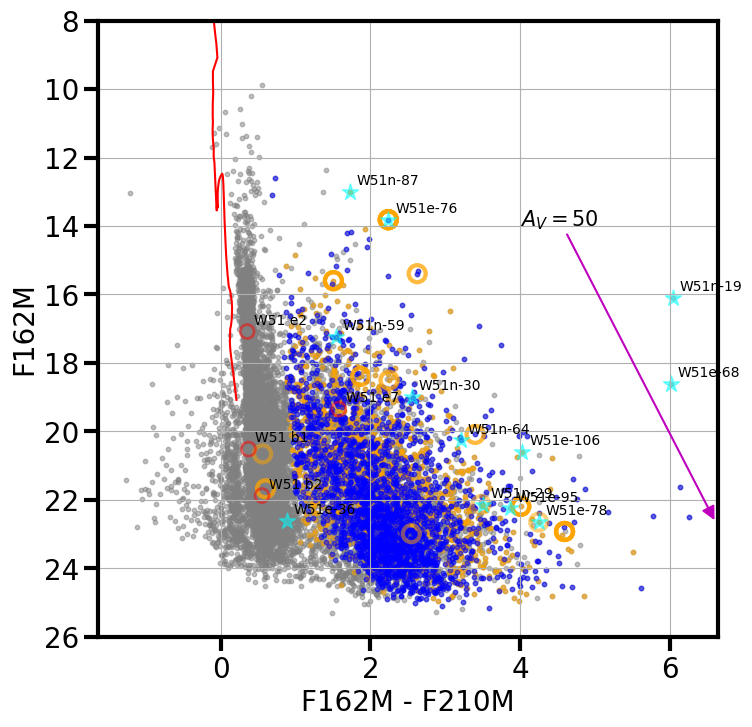

In [74]:
#162-210 vs 162
fig = plt.figure(figsize=(8,8))
ax = fig.add_subplot(111)
ax.scatter(f162m_mag[0] - f210m_mag[0], f162m_mag[0], s=10, c='gray', alpha=0.5)
ax.scatter(f162m_mag[0][upper_idx] - f210m_mag[0][upper_idx], f162m_mag[0][upper_idx], s=10, c='orange', alpha=0.5, label='Upper branch')
ax.scatter(f162m_mag[0][lower_idx] - f210m_mag[0][lower_idx], f162m_mag[0][lower_idx], s=10, c='blue', alpha=0.5, label='Lower branch')
ax.scatter(f162m_matched_vla_mag - f210m_matched_vla_mag, f162m_matched_vla_mag, s=150, edgecolor='orange', lw=3, facecolor='none',  alpha=0.5, label='VLA sources')
ax.scatter(np.array(mag_f162m_w51e_arr) - np.array(mag_f210m_w51e_arr), np.array(mag_f162m_w51e_arr), s=150, c='cyan', marker='*',alpha=0.5, label='W51e ALMA sources')
ax.scatter(np.array(mag_f162m_w51n_arr) - np.array(mag_f210m_w51n_arr), np.array(mag_f162m_w51n_arr), s=150, c='cyan', marker='*', alpha=0.5, label='W51n ALMA sources')  
ii=0
for alma_idx, jwst_idx in zip(w51e_matched_idx, matching_idx_w51e_arr):
    if jwst_idx is not np.nan:
        ax.annotate(f'W51e-{alma_idx}', (np.array(mag_f162m_w51e_arr)[ii] - np.array(mag_f210m_w51e_arr)[ii],
                                np.array(mag_f162m_w51e_arr)[ii]),
                textcoords="offset points", xytext=(5,5), ha='left', color='k', fontsize=10)
        ii += 1
ii=0
for alma_idx, jwst_idx in zip(w51n_matched_idx, matching_idx_w51n_arr):
    if jwst_idx is not np.nan:
        ax.annotate(f'W51n-{alma_idx}', (np.array(mag_f162m_w51n_arr)[ii] - np.array(mag_f210m_w51n_arr)[ii],
                                np.array(mag_f162m_w51n_arr)[ii]),
                textcoords="offset points", xytext=(5,5), ha='left', color='k', fontsize=10)
        ii += 1
ax.scatter(f162m_mag[0][2889] - f210m_mag[0][2889], f162m_mag[0][2889], s=100, edgecolor='red', facecolor='none',lw=2, alpha=0.5)
ax.annotate('W51 b1', (f162m_mag[0].value[2889] - f210m_mag[0].value[2889], f162m_mag[0].value[2889]), textcoords="offset points", xytext=(5,5), ha='left', color='k', fontsize=10)
ax.scatter(f162m_mag[0][2899] - f210m_mag[0][2899], f162m_mag[0][2899], s=100, edgecolor='red', facecolor='none',lw=2, alpha=0.5)
ax.annotate('W51 b2', (f162m_mag[0].value[2899] - f210m_mag[0].value[2899], f162m_mag[0].value[2899]), textcoords="offset points", xytext=(5,5), ha='left', color='k', fontsize=10)
ax.scatter(f162m_mag[0][7656] - f210m_mag[0][7656], f162m_mag[0][7656], s=100, edgecolor='red', facecolor='none',lw=2,alpha=0.5)
ax.annotate('W51 c1', (f162m_mag[0].value[7656] - f210m_mag[0].value[7656], f162m_mag[0].value[7656]), textcoords="offset points", xytext=(5,5), ha='left', color='k', fontsize=10)
ax.scatter(f162m_mag[0][7220] - f210m_mag[0][7220], f162m_mag[0][7220], s=100, edgecolor='red', facecolor='none', lw=2,alpha=0.5)
ax.annotate('W51 e7', (f162m_mag[0].value[7220] - f210m_mag[0].value[7220], f162m_mag[0].value[7220]), textcoords="offset points", xytext=(5,5), ha='left', color='k', fontsize=10)
ax.scatter(f162m_mag[0][13814] - f210m_mag[0][13814], f162m_mag[0][13814], s=100, edgecolor='red', facecolor='none', lw=2,alpha=0.5)
ax.annotate('W51 e2', (f162m_mag[0].value[13814] - f210m_mag[0].value[13814], f162m_mag[0].value[13814]), textcoords="offset points", xytext=(5,5), ha='left', color='k', fontsize=10)  
ax.grid()
ax.set_xlabel('F162M - F210M')
ax.set_ylabel('F162M')
for ext_model, labels, c in zip([CT06_MWLoc(), RL85_MWGC(), G21_MWAvg(), RRP89_MWGC(), G24_SMCAvg()], ['CT06 MWLoc', 'RL85 MWGC', 'G21 MWAvg', 'RRP89 MWGC', 'G24 SMCAvg'], colorlist):
    plot_extvec_cmd(ax, color1=('f162m', 'f210m'), mag1=('f162m',),
                     ext=ext_model, extvec_scale=50, color=c,
                      start=(4,14), label=labels)
ax.set_ylim(26, 8)
ax.plot(F162Mmag_av0[age_idx] - F210Mmag_av0[age_idx], F162Mmag_av0[age_idx], color='r')

3.35 um 3.6 um 4.1 um 4.8 um
3.35 um 3.6 um 4.1 um 4.8 um
3.21022423880597 2.998837333333334 2.691064975609756 2.42466
3.35 um 3.6 um 4.1 um 4.8 um
3.35 um 3.6 um 4.1 um 4.8 um
3.109678171641791 2.720512820512821 1.9544090056285186 1.15
3.35 um 3.6 um 4.1 um 4.8 um
3.35 um 3.6 um 4.1 um 4.8 um
3.0619208740799215 2.754347461357901 2.277132533294349 1.8157051852626855
3.35 um 3.6 um 4.1 um 4.8 um
3.35 um 3.6 um 4.1 um 4.8 um
3.5648122345702387 3.2155007883163207 2.4362921000382474 1.6181229773462702
3.35 um 3.6 um 4.1 um 4.8 um
Extinction vector not plotted: Input x outside of range defined for G24_SMCAvg [0.3 <= x <= 10.0, x has units 1/micron]


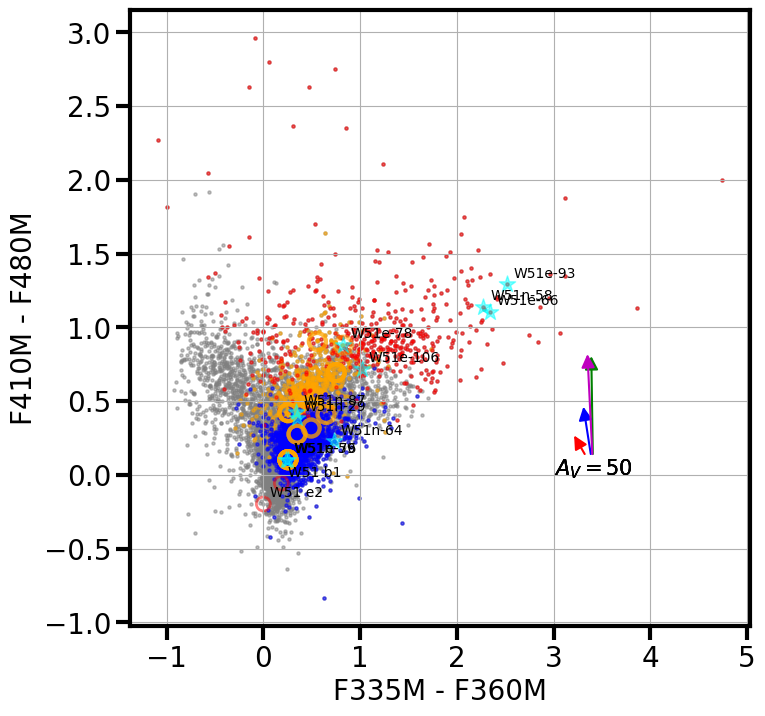

In [75]:
#335-360 vs 410-480
fig = plt.figure(figsize=(8,8))
ax = fig.add_subplot(111)
ax.scatter(f335m_mag[0] - f360m_mag[0], f410m_mag[0]-f480m_mag[0], s=5, c='gray', alpha=0.5)
ax.scatter(f335m_mag[0][upper_idx] - f360m_mag[0][upper_idx], f410m_mag[0][upper_idx]-f480m_mag[0][upper_idx], s=5, c='orange', alpha=0.5, label='Upper branch')
ax.scatter(f335m_mag[0][lower_idx] - f360m_mag[0][lower_idx], f410m_mag[0][lower_idx]-f480m_mag[0][lower_idx], s=5, c='blue', alpha=0.5, label='Lower branch')
ax.scatter(f335m_mag[0][missing_nir_idx_red] - f360m_mag[0][missing_nir_idx_red], f410m_mag[0][missing_nir_idx_red]-f480m_mag[0][missing_nir_idx_red], s=5, c='r', alpha=0.5, label='Missing NIR')
ax.scatter(f335m_matched_vla_mag - f360m_matched_vla_mag, f410m_matched_vla_mag-f480m_matched_vla_mag, s=150, edgecolor='orange', lw=3, facecolor='none',  alpha=0.5, label='VLA sources')
ax.scatter(np.array(mag_f335m_w51e_arr) - np.array(mag_f360m_w51e_arr), np.array(mag_f410m_w51e_arr)-np.array(mag_f480m_w51e_arr), s=150, c='cyan', marker='*',alpha=0.5, label='W51e ALMA sources')
ax.scatter(np.array(mag_f335m_w51n_arr) - np.array(mag_f360m_w51n_arr), np.array(mag_f410m_w51n_arr)-np.array(mag_f480m_w51n_arr), s=150, c='cyan', marker='*', alpha=0.5, label='W51n ALMA sources')  
ii=0
for alma_idx, jwst_idx in zip(w51e_matched_idx, matching_idx_w51e_arr):
    if jwst_idx is not np.nan:
        ax.annotate(f'W51e-{alma_idx}', (np.array(mag_f335m_w51e_arr)[ii] - np.array(mag_f360m_w51e_arr)[ii],
                                np.array(mag_f410m_w51e_arr)[ii]-np.array(mag_f480m_w51e_arr)[ii]),
                textcoords="offset points", xytext=(5,5), ha='left', color='k', fontsize=10)
        ii += 1
ii=0
for alma_idx, jwst_idx in zip(w51n_matched_idx, matching_idx_w51n_arr):
    if jwst_idx is not np.nan:
        ax.annotate(f'W51n-{alma_idx}', (np.array(mag_f335m_w51n_arr)[ii] - np.array(mag_f360m_w51n_arr)[ii],
                                np.array(mag_f410m_w51n_arr)[ii]-np.array(mag_f480m_w51n_arr)[ii]),
                textcoords="offset points", xytext=(5,5), ha='left', color='k', fontsize=10)
        ii += 1
ax.scatter(f335m_mag[0][2889] - f360m_mag[0][2889], f410m_mag[0][2889]-f480m_mag[0][2889], s=100, edgecolor='red', facecolor='none',lw=2, alpha=0.5)
ax.annotate('W51 b1', (f335m_mag[0].value[2889] - f360m_mag[0].value[2889], f410m_mag[0].value[2889]-f480m_mag[0].value[2889]), textcoords="offset points", xytext=(5,5), ha='left', color='k', fontsize=10)
ax.scatter(f335m_mag[0][2899] - f360m_mag[0][2899], f410m_mag[0][2899]-f480m_mag[0][2899], s=100, edgecolor='red', facecolor='none',lw=2, alpha=0.5)
ax.annotate('W51 b2', (f335m_mag[0].value[2899] - f360m_mag[0].value[2899], f410m_mag[0].value[2899]-f480m_mag[0].value[2899]), textcoords="offset points", xytext=(5,5), ha='left', color='k', fontsize=10)
ax.scatter(f335m_mag[0][7656] - f360m_mag[0][7656], f410m_mag[0][7656]-f480m_mag[0][7656], s=100, edgecolor='red', facecolor='none',lw=2,alpha=0.5)
ax.annotate('W51 c1', (f335m_mag[0].value[7656] - f360m_mag[0].value[7656], f410m_mag[0].value[7656]-f480m_mag[0].value[7656]), textcoords="offset points", xytext=(5,5), ha='left', color='k', fontsize=10)
ax.scatter(f335m_mag[0][7220] - f360m_mag[0][7220], f410m_mag[0][7220]-f480m_mag[0][7220], s=100, edgecolor='red', facecolor='none', lw=2,alpha=0.5)
ax.annotate('W51 e7', (f335m_mag[0].value[7220] - f360m_mag[0].value[7220], f410m_mag[0].value[7220]-f480m_mag[0].value[7220]), textcoords="offset points", xytext=(5,5), ha='left', color='k', fontsize=10)
ax.scatter(f335m_mag[0][13814] - f360m_mag[0][13814], f410m_mag[0][13814]-f480m_mag[0][13814], s=100, edgecolor='red', facecolor='none', lw=2,alpha=0.5)
ax.annotate('W51 e2', (f335m_mag[0].value[13814] - f360m_mag[0].value[13814], f410m_mag[0].value[13814]-f480m_mag[0].value[13814]), textcoords="offset points", xytext=(5,5), ha='left', color='k', fontsize=10)  
ax.grid()
ax.set_xlabel('F335M - F360M')
ax.set_ylabel('F410M - F480M')
for ext_model, labels, c in zip([CT06_MWLoc(), RL85_MWGC(), G21_MWAvg(), RRP89_MWGC(), G24_SMCAvg()], ['CT06 MWLoc', 'RL85 MWGC', 'G21 MWAvg', 'RRP89 MWGC', 'G24 SMCAvg'], colorlist):
    plot_extvec_ccd(ax, color1=('f335m', 'f360m'), color2=('f410m', 'f480m'),
                     ext=ext_model, extvec_scale=50, color=c,
                      start=(3,0), label=labels)

10 10 10
W51e-7 0.5845638808545989
W51e-36 1.8025945475490766
W51e-66 1.2278095524720471
W51e-67 2.6489891862258297
W51e-68 2.060299668623665
W51e-76 --
W51e-78 --
W51e-93 --
W51e-95 --
W51e-106 --
W51n-19 1.752137024567224
W51n-29 --
W51n-30 --
W51n-58 --
W51n-59 --
W51n-64 --
W51n-66 --
W51n-76 --
W51n-87 --
Model: CT06_MWLoc
Inputs: ('x',)
Outputs: ('y',)
Model set size: 1
Parameters:
3.6 um 4.8 um 4.8 um 5.6 um
3.6 um 4.8 um 4.8 um 5.6 um
2.998837333333334 2.42466 2.42466 2.2466480000000004
Model: RL85_MWGC
Inputs: ('x',)
Outputs: ('y',)
Model set size: 1
Parameters:
3.6 um 4.8 um 4.8 um 5.6 um
3.6 um 4.8 um 4.8 um 5.6 um
2.720512820512821 1.15 1.15 1.0964285714285715
Model: G21_MWAvg
Inputs: ('x',)
Outputs: ('y',)
Model set size: 1
Parameters:
3.6 um 4.8 um 4.8 um 5.6 um
3.6 um 4.8 um 4.8 um 5.6 um
2.754347461357901 1.8157051852626855 1.8157051852626855 1.4747379647261287
Model: RRP89_MWGC
Inputs: ('x',)
Outputs: ('y',)
Model set size: 1
Parameters:
3.6 um 4.8 um 4.8 um 5.6 um
3.6

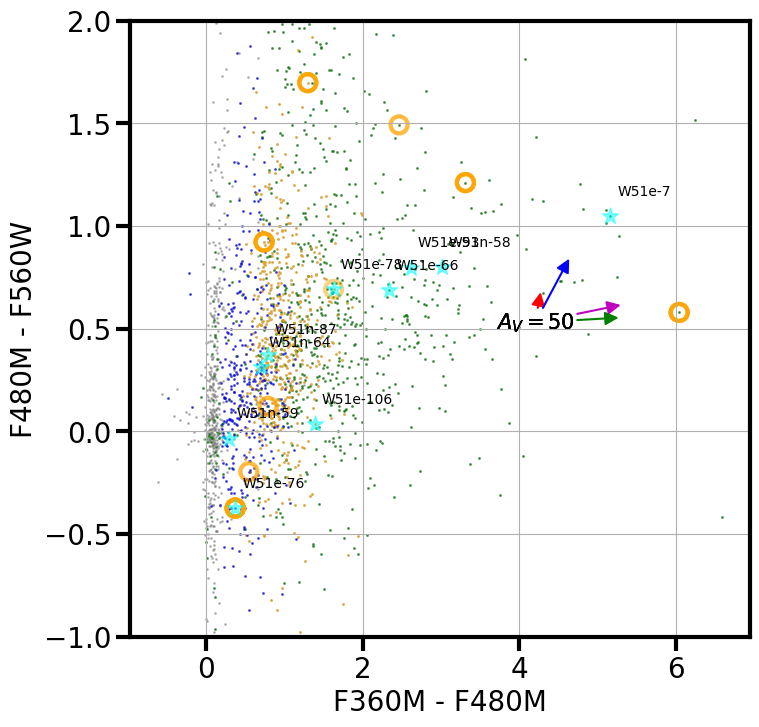

In [76]:
#plot f360-f480 vs f480-f560
fig = plt.figure(figsize=(8,8))
ax = fig.add_subplot(111)
ax.scatter(f360m_mag[0] - f480m_mag[0], f480m_mag[0]-f560w_mag[0], s=1, c='gray', alpha=0.5)
# plot sources in upper and lower without finite f162 or f210 magnitudes
missing_nir_idx = ~np.isfinite(f162) | ~np.isfinite(f210)
ax.scatter(f360m_mag[0][missing_nir_idx] - f480m_mag[0][missing_nir_idx],
           f480m_mag[0][missing_nir_idx] - f560w_mag[0][missing_nir_idx],
           s=1, c='green', alpha=0.5, label='Missing F162M/F210M')

ax.scatter(f360m_mag[0][upper_idx] - f480m_mag[0][upper_idx], f480m_mag[0][upper_idx]-f560w_mag[0][upper_idx], s=1, c='orange', alpha=0.5, label='Upper branch')
ax.scatter(f360m_mag[0][lower_idx] - f480m_mag[0][lower_idx], f480m_mag[0][lower_idx]-f560w_mag[0][lower_idx], s=1, c='blue', alpha=0.5, label='Lower branch')
ax.scatter(f360m_matched_vla_mag - f480m_matched_vla_mag, f480m_matched_vla_mag-f560w_matched_vla_mag, s=150, edgecolor='orange', lw=3, facecolor='none',  alpha=0.5, label='VLA sources')
ax.scatter(np.array(mag_f360m_w51e_arr) - np.array(mag_f480m_w51e_arr), np.array(mag_f480m_w51e_arr)-np.array(mag_f560w_w51e_arr), s=150, c='cyan', marker='*',alpha=0.5, label='W51e ALMA sources')
ax.scatter(np.array(mag_f360m_w51n_arr) - np.array(mag_f480m_w51n_arr), np.array(mag_f480m_w51n_arr)-np.array(mag_f560w_w51n_arr), s=150, c='cyan', marker='*', alpha=0.5, label='W51n ALMA sources')
print(len(mag_f360m_w51e_arr), len(mag_f480m_w51e_arr), len(mag_f560w_w51e_arr))
ii=0
for alma_idx, jwst_idx in zip(w51e_matched_idx, matching_idx_w51e_arr):
    if jwst_idx is not np.nan:
        ax.annotate(f'W51e-{alma_idx}', (np.array(mag_f360m_w51e_arr)[ii] - np.array(mag_f480m_w51e_arr)[ii],
                                np.array(mag_f480m_w51e_arr)[ii]-np.array(mag_f560w_w51e_arr)[ii]),
                textcoords="offset points", xytext=(5,15), ha='left', color='k', fontsize=10)

        print(f'W51e-{alma_idx}', w51e_alma_tab['alpha'][alma_idx])
        ii += 1
ii=0 
for alma_idx, jwst_idx in zip(w51n_matched_idx, matching_idx_w51n_arr):
    if jwst_idx is not np.nan:
        ax.annotate(f'W51n-{alma_idx}', (np.array(mag_f360m_w51n_arr)[ii] - np.array(mag_f480m_w51n_arr)[ii],
                                np.array(mag_f480m_w51n_arr)[ii]-np.array(mag_f560w_w51n_arr)[ii]),
                textcoords="offset points", xytext=(5,15), ha='left', color='k', fontsize=10)
        print(f'W51n-{alma_idx}', w51n_alma_tab['alpha'][alma_idx])
        ii += 1
# HeI(1-0) and Br gamma, O9.5 (Barbosa+22)
ax.scatter(f360m_mag[0][2889] - f480m_mag[0][2889], f480m_mag[0][2889]-f560w_mag[0][2889], s=100, edgecolor='red', facecolor='none',lw=2, alpha=0.5)
ax.annotate('W51 b1', (f360m_mag[0].value[2889] - f480m_mag[0].value[2889], f480m_mag[0].value[2889]-f560w_mag[0].value[2889]), textcoords="offset points", xytext=(5,5), ha='left', color='k', fontsize=10)
# HeI and Br gamma emission, O9.5 star  (Barbosa+22)
ax.scatter(f360m_mag[0][2899] - f480m_mag[0][2899], f480m_mag[0][2899]-f560w_mag[0][2899], s=100, edgecolor='red', facecolor='none',lw=2, alpha=0.5)
ax.annotate('W51 b2', (f360m_mag[0].value[2899] - f480m_mag[0].value[2899], f480m_mag[0].value[2899]-f560w_mag[0].value[2899]), textcoords="offset points", xytext=(5,5), ha='left', color='k', fontsize=10)
# c1 - not sure if it is driving source, O9 star (Barbosa+22)
ax.scatter(f360m_mag[0][7656] - f480m_mag[0][7656], f480m_mag[0][7656]-f560w_mag[0][7656], s=100, edgecolor='red', facecolor='none',lw=2,alpha=0.5)
ax.annotate('W51 c1', (f360m_mag[0].value[7656] - f480m_mag[0].value[7656], f480m_mag[0].value[7656]-f560w_mag[0].value[7656]), textcoords="offset points", xytext=(5,5), ha='left', color='k', fontsize=10)
# e7 - O9.5 (Barbosa+22), B star (Bik+19)
ax.scatter(f360m_mag[0][7220] - f480m_mag[0][7220], f480m_mag[0][7220]-f560w_mag[0][7220], s=100, edgecolor='red', facecolor='none', lw=2,alpha=0.5)
ax.annotate('W51 e7', (f360m_mag[0].value[7220] - f480m_mag[0].value[7220], f480m_mag[0].value[7220]-f560w_mag[0].value[7220]), textcoords="offset points", xytext=(5,5), ha='left', color='k', fontsize=10)
ax.scatter(f360m_mag[0][13814] - f480m_mag[0][13814], f480m_mag[0][13814]-f560w_mag[0][13814], s=100, edgecolor='red', facecolor='none', lw=2,alpha=0.5)
ax.annotate('W51 e2', (f360m_mag[0].value[13814] - f480m_mag[0].value[13814], f480m_mag[0].value[13814]-f560w_mag[0].value[13814]), textcoords="offset points", xytext=(5,5), ha='left', color='k', fontsize=10)
ax.grid()
ax.set_xlabel('F360M - F480M')
ax.set_ylabel('F480M - F560W')
ax.set_ylim(-1, 2)
for ext_model, labels, c in zip([CT06_MWLoc(), RL85_MWGC(), G21_MWAvg(), RRP89_MWGC(), G24_SMCAvg()], ['CT06 MWLoc', 'RL85 MWGC', 'G21 MWAvg', 'RRP89 MWGC', 'G24 SMCAvg'], colorlist):
    print(ext_model)
    plot_extvec_ccd(ax, color1=('f360m', 'f480m'), color2=('f480m', 'f560w'),
                     ext=ext_model, extvec_scale=50, color=c,
                      start=(3.7,0.5), label=labels)


logage: 5, age_idx: [ True  True  True ... False False False], f360m-f480m:         col46         
----------------------
   0.07199999999999918
   0.06599999999999895
  0.055999999999997385
  0.054000000000002046
    0.0470000000000006
  0.035000000000003695
    0.0259999999999998
-0.0030000000000001137
 -0.018000000000000682
 -0.038000000000000256
                   ...
   0.14700000000000202
    0.1479999999999997
    0.1509999999999998
   0.15000000000000036
    0.1509999999999998
    0.1509999999999998
    0.1509999999999998
    0.1509999999999998
    0.1509999999999998
   0.14999999999999858
Length = 229 rows, f360m:       col46       
------------------
 16.90296879911484
 16.70696879911484
 16.47496879911484
16.458968799114842
16.360968799114843
16.238968799114843
16.176968799114842
15.978968799114842
 15.87296879911484
15.752968799114843
               ...
 6.973968799114843
6.8739687991148415
 6.533968799114842
6.5259687991148425
 6.477968799114841
 6.446968799114842
 6.42396

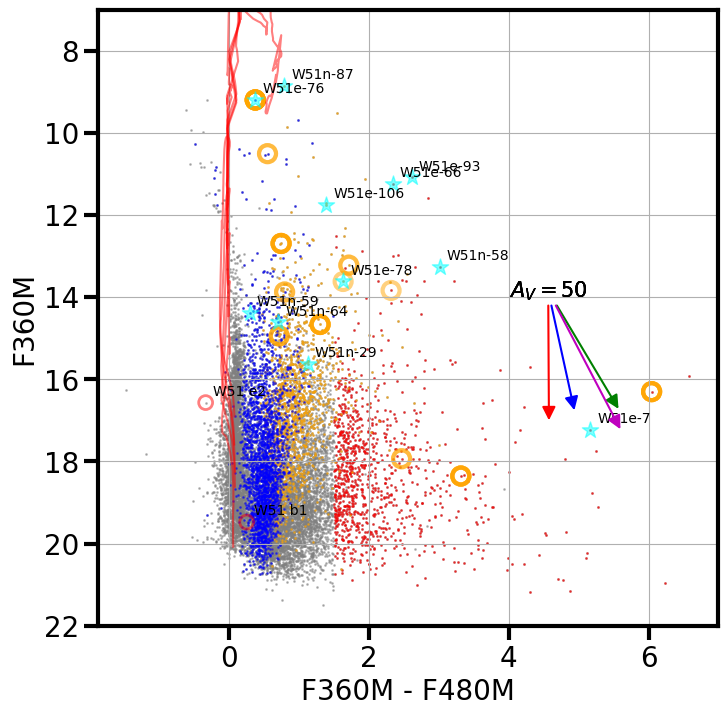

In [77]:
#plot 360-480 vs 360

fig = plt.figure(figsize=(8,8))
ax = fig.add_subplot(111)
ax.scatter(f360m_mag[0] - f480m_mag[0], f360m_mag[0], s=1, c='gray', alpha=0.5)
# plot sources in upper and lower without finite f162 or f210 magnitudes
missing_nir_idx = ~np.isfinite(f162) | ~np.isfinite(f210)
missing_nir_idx_red = missing_nir_idx & (f360m_mag[0].value - f480m_mag[0].value > 1.5)
ax.scatter(f360m_mag[0][missing_nir_idx_red] - f480m_mag[0][missing_nir_idx_red], f360m_mag[0][missing_nir_idx_red], s=1, c='red', alpha=0.5, label='Missing F162M/F210M')
ax.scatter(f360m_mag[0][upper_idx] - f480m_mag[0][upper_idx], f360m_mag[0][upper_idx], s=1, c='orange', alpha=0.5, label='Upper branch')
ax.scatter(f360m_mag[0][lower_idx] - f480m_mag[0][lower_idx], f360m_mag[0][lower_idx], s=1, c='blue', alpha=0.5, label='Lower branch')
ax.scatter(f360m_matched_vla_mag - f480m_matched_vla_mag, f360m_matched_vla_mag, s=150, edgecolor='orange', lw=3, facecolor='none',  alpha=0.5, label='VLA sources')
ax.scatter(np.array(mag_f360m_w51e_arr) - np.array(mag_f480m_w51e_arr), np.array(mag_f360m_w51e_arr), s=150, c='cyan', marker='*',alpha=0.5, label='W51e ALMA sources')
ax.scatter(np.array(mag_f360m_w51n_arr) - np.array(mag_f480m_w51n_arr), np.array(mag_f360m_w51n_arr), s=150, c='cyan', marker='*', alpha=0.5, label='W51n ALMA sources')  

for logage in [5, 5.5, 6, 6.5,7]:
    age_idx = logage_av0 == logage
    ax.plot(F360Mmag_av0[age_idx] - F480Mmag_av0[age_idx], F360Mmag_av0[age_idx] , color='r', alpha=0.5)
    print(f'logage: {logage}, age_idx: {age_idx}, f360m-f480m: {F360Mmag_av0[age_idx] - F480Mmag_av0[age_idx]}, f360m: {F360Mmag_av0[age_idx]}')
ii=0
for alma_idx, jwst_idx in zip(w51e_matched_idx, matching_idx_w51e_arr):
    if jwst_idx is not np.nan:
        ax.annotate(f'W51e-{alma_idx}', (np.array(mag_f360m_w51e_arr)[ii] - np.array(mag_f480m_w51e_arr)[ii],
                                np.array(mag_f360m_w51e_arr)[ii]),
                textcoords="offset points", xytext=(5,5), ha='left', color='k', fontsize=10)
        ii += 1
ii=0
for alma_idx, jwst_idx in zip(w51n_matched_idx, matching_idx_w51n_arr):
    if jwst_idx is not np.nan:
        ax.annotate(f'W51n-{alma_idx}', (np.array(mag_f360m_w51n_arr)[ii] - np.array(mag_f480m_w51n_arr)[ii],
                                np.array(mag_f360m_w51n_arr)[ii]),
                textcoords="offset points", xytext=(5,5), ha='left', color='k', fontsize=10)
        ii += 1 
ax.grid()
ax.scatter(f360m_mag[0][2889] - f480m_mag[0][2889], f360m_mag[0][2889], s=100, edgecolor='red', facecolor='none',lw=2, alpha=0.5)
ax.annotate('W51 b1', (f360m_mag[0].value[2889] - f480m_mag[0].value[2889], f360m_mag[0].value[2889]), textcoords="offset points", xytext=(5,5), ha='left', color='k', fontsize=10)
ax.scatter(f360m_mag[0][2899] - f480m_mag[0][2899], f360m_mag[0][2899], s=100, edgecolor='red', facecolor='none',lw=2, alpha=0.5)
ax.annotate('W51 b2', (f360m_mag[0].value[2899] - f480m_mag[0].value[2899], f360m_mag[0].value[2899]), textcoords="offset points", xytext=(5,5), ha='left', color='k', fontsize=10)
ax.scatter(f360m_mag[0][7656] - f480m_mag[0][7656], f360m_mag[0][7656], s=100, edgecolor='red', facecolor='none',lw=2,alpha=0.5)
ax.annotate('W51 c1', (f360m_mag[0].value[7656] - f480m_mag[0].value[7656], f360m_mag[0].value[7656]), textcoords="offset points", xytext=(5,5), ha='left', color='k', fontsize=10)
ax.scatter(f360m_mag[0][7220] - f480m_mag[0][7220], f360m_mag[0][7220], s=100, edgecolor='red', facecolor='none', lw=2,alpha=0.5)
ax.annotate('W51 e7', (f360m_mag[0].value[7220] - f480m_mag[0].value[7220], f360m_mag[0].value[7220]), textcoords="offset points", xytext=(5,5), ha='left', color='k', fontsize=10)
ax.scatter(f360m_mag[0][13814] - f480m_mag[0][13814], f360m_mag[0][13814], s=100, edgecolor='red', facecolor='none', lw=2,alpha=0.5)
ax.annotate('W51 e2', (f360m_mag[0].value[13814] - f480m_mag[0].value[13814], f360m_mag[0].value[13814]), textcoords="offset points", xytext=(5,5), ha='left', color='k', fontsize=10)
ax.set_xlabel('F360M - F480M')
ax.set_ylabel('F360M')
ax.set_ylim(22, 7) 
for ext_model, labels, c in zip([CT06_MWLoc(), RL85_MWGC(), G21_MWAvg(), RRP89_MWGC(), G24_SMCAvg()], ['CT06 MWLoc', 'RL85 MWGC', 'G21 MWAvg', 'RRP89 MWGC', 'G24 SMCAvg'], colorlist):
    plot_extvec_cmd(ax, color1=('f360m', 'f480m'), mag1=('f360m',),
                     ext=ext_model, extvec_scale=50, color=c,
                      start=(4,14), label=labels)

Model: CT06_MWLoc
Inputs: ('x',)
Outputs: ('y',)
Model set size: 1
Parameters:
3.6 um 4.8 um 5.6 um 7.7 um
3.6 um 4.8 um 5.6 um 7.7 um
2.998837333333334 2.42466 2.2466480000000004 2.1056000000000004
Model: RL85_MWGC
Inputs: ('x',)
Outputs: ('y',)
Model set size: 1
Parameters:
3.6 um 4.8 um 5.6 um 7.7 um
3.6 um 4.8 um 5.6 um 7.7 um
2.720512820512821 1.15 1.0964285714285715 1.0087662337662338
Model: G21_MWAvg
Inputs: ('x',)
Outputs: ('y',)
Model set size: 1
Parameters:
3.6 um 4.8 um 5.6 um 7.7 um
3.6 um 4.8 um 5.6 um 7.7 um
2.754347461357901 1.8157051852626855 1.4747379647261287 1.333467331596131
Model: RRP89_MWGC
Inputs: ('x',)
Outputs: ('y',)
Model set size: 1
Parameters:
3.6 um 4.8 um 5.6 um 7.7 um
3.6 um 4.8 um 5.6 um 7.7 um
3.2155007883163207 1.6181229773462702 1.5025427646786822 1.3134115075862656
Model: G24_SMCAvg
Inputs: ('x',)
Outputs: ('y',)
Model set size: 1
Parameters:
3.6 um 4.8 um 5.6 um 7.7 um
Extinction vector not plotted: Input x outside of range defined for G24_SMCAvg [

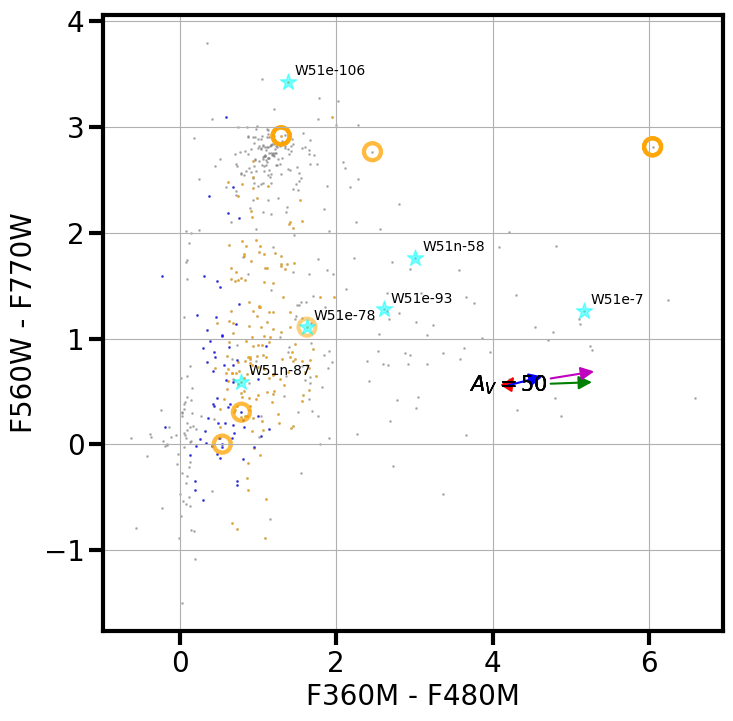

In [78]:
#plot f360-f480 vs f560-f770
fig = plt.figure(figsize=(8,8))
ax = fig.add_subplot(111)
ax.scatter(f360m_mag[0] - f480m_mag[0], f560w_mag[0]-f770w_mag[0], s=1, c='gray', alpha=0.5)
ax.scatter(f360m_mag[0][upper_idx] - f480m_mag[0][upper_idx], f560w_mag[0][upper_idx]-f770w_mag[0][upper_idx], s=1, c='orange', alpha=0.5, label='Upper branch')
ax.scatter(f360m_mag[0][lower_idx] - f480m_mag[0][lower_idx], f560w_mag[0][lower_idx]-f770w_mag[0][lower_idx], s=1, c='blue', alpha=0.5, label='Lower branch')
ax.scatter(f360m_matched_vla_mag - f480m_matched_vla_mag, f560w_matched_vla_mag-f770w_matched_vla_mag, s=150, edgecolor='orange', lw=3, facecolor='none',  alpha=0.5, label='VLA sources')
ax.scatter(np.array(mag_f360m_w51e_arr) - np.array(mag_f480m_w51e_arr), np.array(mag_f560w_w51e_arr)-np.array(mag_f770w_w51e_arr), s=150, c='cyan', marker='*',alpha=0.5, label='W51e ALMA sources')
ax.scatter(np.array(mag_f360m_w51n_arr) - np.array(mag_f480m_w51n_arr), np.array(mag_f560w_w51n_arr)-np.array(mag_f770w_w51n_arr), s=150, c='cyan', marker='*', alpha=0.5, label='W51n ALMA sources')
ii=0
for alma_idx, jwst_idx in zip(w51e_matched_idx, matching_idx_w51e_arr):
    if jwst_idx is not np.nan:
        ax.annotate(f'W51e-{alma_idx}', (np.array(mag_f360m_w51e_arr)[ii] - np.array(mag_f480m_w51e_arr)[ii],
                                np.array(mag_f560w_w51e_arr)[ii]-np.array(mag_f770w_w51e_arr)[ii]),
                textcoords="offset points", xytext=(5,5), ha='left', color='k', fontsize=10)
        ii += 1
ii=0 
for alma_idx, jwst_idx in zip(w51n_matched_idx, matching_idx_w51n_arr):
    if jwst_idx is not np.nan:
        ax.annotate(f'W51n-{alma_idx}', (np.array(mag_f360m_w51n_arr)[ii] - np.array(mag_f480m_w51n_arr)[ii],
                                np.array(mag_f560w_w51n_arr)[ii]-np.array(mag_f770w_w51n_arr)[ii]),
                textcoords="offset points", xytext=(5,5), ha='left', color='k', fontsize=10)
        ii += 1
# HeI(1-0) and Br gamma, O9.5 (Barbosa+22)
ax.scatter(f360m_mag[0][2889] - f480m_mag[0][2889], f560w_mag[0][2889]-f770w_mag[0][2889], s=100, edgecolor='red', facecolor='none',lw=2, alpha=0.5)
ax.annotate('W51 b1', (f360m_mag[0].value[2889] - f480m_mag[0].value[2889], f560w_mag[0].value[2889]-f770w_mag[0].value[2889]), textcoords="offset points", xytext=(5,5), ha='left', color='k', fontsize=10)
# HeI and Br gamma emission, O9.5 star  (Barbosa+22)
ax.scatter(f360m_mag[0][2899] - f480m_mag[0][2899], f560w_mag[0][2899]-f770w_mag[0][2899], s=100, edgecolor='red', facecolor='none',lw=2, alpha=0.5)
ax.annotate('W51 b2', (f360m_mag[0].value[2899] - f480m_mag[0].value[2899], f560w_mag[0].value[2899]-f770w_mag[0].value[2899]), textcoords="offset points", xytext=(5,5), ha='left', color='k', fontsize=10)
# c1 - not sure if it is driving source, O9 star (Barbosa+22)
ax.scatter(f360m_mag[0][7656] - f480m_mag[0][7656], f560w_mag[0][7656]-f770w_mag[0][7656], s=100, edgecolor='red', facecolor='none',lw=2,alpha=0.5)
ax.annotate('W51 c1', (f360m_mag[0].value[7656] - f480m_mag[0].value[7656], f560w_mag[0].value[7656]-f770w_mag[0].value[7656]), textcoords="offset points", xytext=(5,5), ha='left', color='k', fontsize=10)
# e7 - O9.5 (Barbosa+22), B star (Bik+19)
ax.scatter(f360m_mag[0][7220] - f480m_mag[0][7220], f560w_mag[0][7220]-f770w_mag[0][7220], s=100, edgecolor='red', facecolor='none', lw=2,alpha=0.5)
ax.annotate('W51 e7', (f360m_mag[0].value[7220] - f480m_mag[0].value[7220], f560w_mag[0].value[7220]-f770w_mag[0].value[7220]), textcoords="offset points", xytext=(5,5), ha='left', color='k', fontsize=10)
ax.scatter(f360m_mag[0][13814] - f480m_mag[0][13814], f560w_mag[0][13814]-f770w_mag[0][13814], s=100, edgecolor='red', facecolor='none', lw=2,alpha=0.5)
ax.annotate('W51 e2', (f360m_mag[0].value[13814] - f480m_mag[0].value[13814], f560w_mag[0].value[13814]-f770w_mag[0].value[13814]), textcoords="offset points", xytext=(5,5), ha='left', color='k', fontsize=10)
ax.grid()
ax.set_xlabel('F360M - F480M')
ax.set_ylabel('F560W - F770W')
for ext_model, labels, c in zip([CT06_MWLoc(), RL85_MWGC(), G21_MWAvg(), RRP89_MWGC(), G24_SMCAvg()], ['CT06 MWLoc', 'RL85 MWGC', 'G21 MWAvg', 'RRP89 MWGC', 'G24 SMCAvg'], colorlist):
    print(ext_model)
    plot_extvec_ccd(ax, color1=('f360m', 'f480m'), color2=('f560w', 'f770w'),
                     ext=ext_model, extvec_scale=50, color=c,
                      start=(3.7,0.5), label=labels)


3.6 um 4.8 um 5.6 um
3.6 um 4.8 um 5.6 um
2.998837333333334 2.42466 2.2466480000000004
3.6 um 4.8 um 5.6 um
3.6 um 4.8 um 5.6 um
2.720512820512821 1.15 1.0964285714285715
3.6 um 4.8 um 5.6 um
3.6 um 4.8 um 5.6 um
2.754347461357901 1.8157051852626855 1.4747379647261287
3.6 um 4.8 um 5.6 um
3.6 um 4.8 um 5.6 um
3.2155007883163207 1.6181229773462702 1.5025427646786822
3.6 um 4.8 um 5.6 um
Extinction vector not plotted: Input x outside of range defined for G24_SMCAvg [0.3 <= x <= 10.0, x has units 1/micron]


(21.0, 5.0)

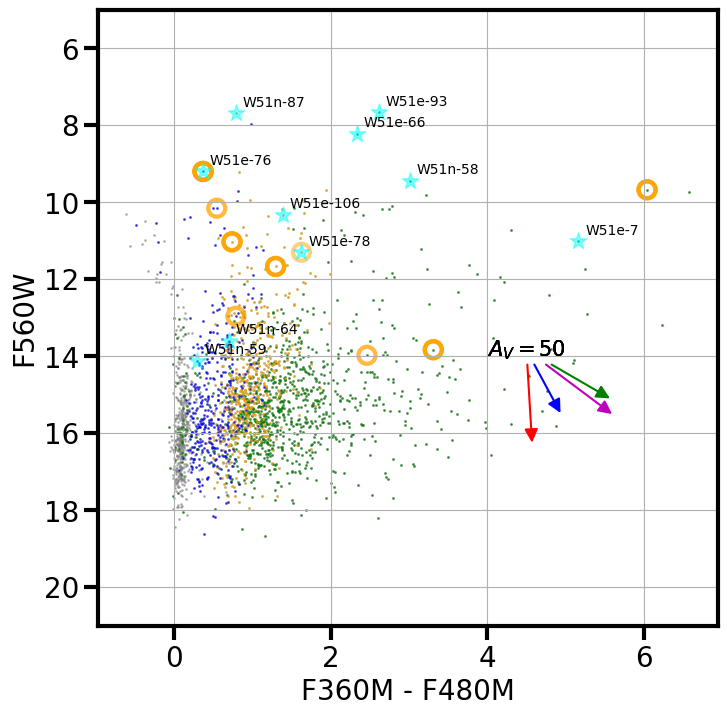

In [79]:
# 360-480 vs 560
fig = plt.figure(figsize=(8,8))
ax = fig.add_subplot(111)
ax.scatter(f360m_mag[0] - f480m_mag[0], f560w_mag[0], s=1, c='gray', alpha=0.5)
# plot sources in upper and lower without finite f162 or f210 magnitudes
missing_nir_idx = ~np.isfinite(f162) | ~np.isfinite(f210)
missing_nir_idx_red = missing_nir_idx & (f360m_mag[0].value - f480m_mag[0].value > 1.5)
ax.scatter(f360m_mag[0][missing_nir_idx] - f480m_mag[0][missing_nir_idx], f560w_mag[0][missing_nir_idx], s=1, c='green', alpha=0.5, label='Missing F162M/F210M')
ax.scatter(f360m_mag[0][upper_idx] - f480m_mag[0][upper_idx], f560w_mag[0][upper_idx], s=1, c='orange', alpha=0.5, label='Upper branch')
ax.scatter(f360m_mag[0][lower_idx] - f480m_mag[0][lower_idx], f560w_mag[0][lower_idx], s=1, c='blue', alpha=0.5, label='Lower branch')
ax.scatter(f360m_matched_vla_mag - f480m_matched_vla_mag, f560w_matched_vla_mag, s=150, edgecolor='orange', lw=3, facecolor='none',  alpha=0.5, label='VLA sources')
ax.scatter(np.array(mag_f360m_w51e_arr) - np.array(mag_f480m_w51e_arr), np.array(mag_f560w_w51e_arr), s=150, c='cyan', marker='*',alpha=0.5, label='W51e ALMA sources')
ax.scatter(np.array(mag_f360m_w51n_arr) - np.array(mag_f480m_w51n_arr), np.array(mag_f560w_w51n_arr), s=150, c='cyan', marker='*', alpha=0.5, label='W51n ALMA sources')  
ii=0
for alma_idx, jwst_idx in zip(w51e_matched_idx, matching_idx_w51e_arr):
    if jwst_idx is not np.nan:
        ax.annotate(f'W51e-{alma_idx}', (np.array(mag_f360m_w51e_arr)[ii] - np.array(mag_f480m_w51e_arr)[ii],
                                np.array(mag_f560w_w51e_arr)[ii]),
                textcoords="offset points", xytext=(5,5), ha='left', color='k', fontsize=10)
        ii += 1
ii=0
for alma_idx, jwst_idx in zip(w51n_matched_idx, matching_idx_w51n_arr):
    if jwst_idx is not np.nan:
        ax.annotate(f'W51n-{alma_idx}', (np.array(mag_f360m_w51n_arr)[ii] - np.array(mag_f480m_w51n_arr)[ii],
                                np.array(mag_f560w_w51n_arr)[ii]),
                textcoords="offset points", xytext=(5,5), ha='left', color='k', fontsize=10)
        ii += 1
ax.scatter(f360m_mag[0][2889] - f480m_mag[0][2889], f560w_mag[0][2889], s=100, edgecolor='red', facecolor='none',lw=2, alpha=0.5)
ax.annotate('W51 b1', (f360m_mag[0].value[2889] - f480m_mag[0].value[2889], f560w_mag[0].value[2889]), textcoords="offset points", xytext=(5,5), ha='left', color='k', fontsize=10)
ax.scatter(f360m_mag[0][2899] - f480m_mag[0][2899], f560w_mag[0][2899], s=100, edgecolor='red', facecolor='none',lw=2, alpha=0.5)
ax.annotate('W51 b2', (f360m_mag[0].value[2899] - f480m_mag[0].value[2899], f560w_mag[0].value[2899]), textcoords="offset points", xytext=(5,5), ha='left', color='k', fontsize=10)
ax.scatter(f360m_mag[0][7656] - f480m_mag[0][7656], f560w_mag[0][7656], s=100, edgecolor='red', facecolor='none',lw=2,alpha=0.5)
ax.annotate('W51 c1', (f360m_mag[0].value[7656] - f480m_mag[0].value[7656], f560w_mag[0].value[7656]), textcoords="offset points", xytext=(5,5), ha='left', color='k', fontsize=10)
ax.scatter(f360m_mag[0][7220] - f480m_mag[0][7220], f560w_mag[0][7220], s=100, edgecolor='red', facecolor='none', lw=2,alpha=0.5)
ax.annotate('W51 e7', (f360m_mag[0].value[7220] - f480m_mag[0].value[7220], f560w_mag[0].value[7220]), textcoords="offset points", xytext=(5,5), ha='left', color='k', fontsize=10)
ax.scatter(f360m_mag[0][13814] - f480m_mag[0][13814], f560w_mag[0][13814], s=100, edgecolor='red', facecolor='none', lw=2,alpha=0.5)
ax.annotate('W51 e2', (f360m_mag[0].value[13814] - f480m_mag[0].value[13814], f560w_mag[0].value[13814]), textcoords="offset points", xytext=(5,5), ha='left', color='k', fontsize=10)
ax.grid()
ax.set_xlabel('F360M - F480M')
ax.set_ylabel('F560W')
for ext_model, labels, c in zip([CT06_MWLoc(), RL85_MWGC(), G21_MWAvg(), RRP89_MWGC(), G24_SMCAvg()], ['CT06 MWLoc', 'RL85 MWGC', 'G21 MWAvg', 'RRP89 MWGC', 'G24 SMCAvg'], colorlist):
    plot_extvec_cmd(ax, color1=('f360m', 'f480m'), mag1=('f560w',),
                     ext=ext_model, extvec_scale=50, color=c,
                      start=(4,14), label=labels)
ax.set_ylim(21, 5)

Model: CT06_MWLoc
Inputs: ('x',)
Outputs: ('y',)
Model set size: 1
Parameters:
1.62 um 2.1 um 3.6 um 5.6 um
1.62 um 2.1 um 3.6 um 5.6 um
8.970550123456789 5.7899519999999995 2.998837333333334 2.2466480000000004
Model: RL85_MWGC
Inputs: ('x',)
Outputs: ('y',)
Model set size: 1
Parameters:
1.62 um 2.1 um 3.6 um 5.6 um
1.62 um 2.1 um 3.6 um 5.6 um
9.05960648148148 6.121052631578948 2.720512820512821 1.0964285714285715
Model: G21_MWAvg
Inputs: ('x',)
Outputs: ('y',)
Model set size: 1
Parameters:
1.62 um 2.1 um 3.6 um 5.6 um
1.62 um 2.1 um 3.6 um 5.6 um
8.961676548404936 6.104216251351036 2.754347461357901 1.4747379647261287
Model: RRP89_MWGC
Inputs: ('x',)
Outputs: ('y',)
Model set size: 1
Parameters:
1.62 um 2.1 um 3.6 um 5.6 um
1.62 um 2.1 um 3.6 um 5.6 um
8.59576224912435 5.997328812862788 3.2155007883163207 1.5025427646786822
Model: G24_SMCAvg
Inputs: ('x',)
Outputs: ('y',)
Model set size: 1
Parameters:
1.62 um 2.1 um 3.6 um 5.6 um
Extinction vector not plotted: Input x outside of rang

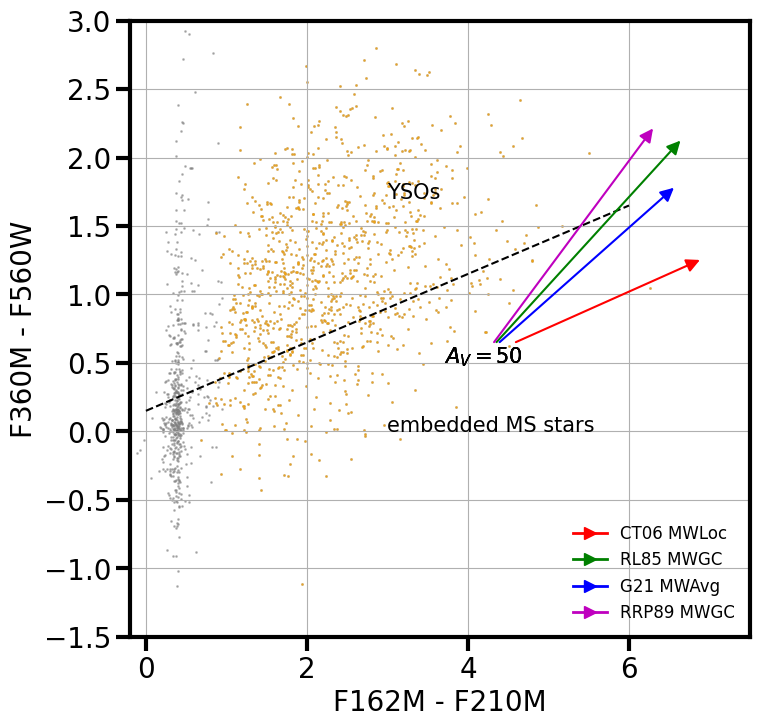

In [80]:
f560w = f560w_mag[0].to_value(u.mag)
fig = plt.figure(figsize=(8,8))
ax = fig.add_subplot(111)
ax.scatter(f162m_mag[0] - f210m_mag[0], f360m_mag[0]-f560w_mag[0], s=1, c='gray', alpha=0.5)
ax.scatter(f162m_mag[0][idx_red_sources] - f210m_mag[0][idx_red_sources],
        f360m_mag[0][idx_red_sources]-f560w_mag[0][idx_red_sources], s=1, c='orange', alpha=0.5)
#ax.plot(parsec_mags['f162m'][age_idx] - parsec_mags['f210m'][age_idx], parsec_mags['f360m'][age_idx]-parsec_mags['f560w'][age_idx], color='r')
for ext_model, labels, c in zip([CT06_MWLoc(), RL85_MWGC(), G21_MWAvg(), RRP89_MWGC(), G24_SMCAvg()], ['CT06 MWLoc', 'RL85 MWGC', 'G21 MWAvg', 'RRP89 MWGC', 'G24 SMCAvg'], colorlist):
    print(ext_model)
    plot_extvec_ccd(ax, color1=('f162m', 'f210m'), color2=('f360m', 'f560w'),
                     ext=ext_model, extvec_scale=50, color=c,
                      start=(3.7,0.5), label=labels)
ax.plot([0,6], [0.15, 1.65], c='k', ls='dashed')
ax.grid()
ax.text(3,1.7, 'YSOs', fontsize=15, color='k')
ax.text(3,0, 'embedded MS stars', fontsize=15, color='k')
plt.xlabel('F162M - F210M')
plt.ylabel('F360M - F560W')
ax.set_ylim(-1.5,3)
ax.set_xlim(-0.2,7.5)
ax.legend(fontsize=12, frameon=False)

Model: CT06_MWLoc
Inputs: ('x',)
Outputs: ('y',)
Model set size: 1
Parameters:
4.8 um 5.6 um 3.6 um 4.8 um
4.8 um 5.6 um 3.6 um 4.8 um
2.42466 2.2466480000000004 2.998837333333334 2.42466
Model: RL85_MWGC
Inputs: ('x',)
Outputs: ('y',)
Model set size: 1
Parameters:
4.8 um 5.6 um 3.6 um 4.8 um
4.8 um 5.6 um 3.6 um 4.8 um
1.15 1.0964285714285715 2.720512820512821 1.15
Model: G21_MWAvg
Inputs: ('x',)
Outputs: ('y',)
Model set size: 1
Parameters:
4.8 um 5.6 um 3.6 um 4.8 um
4.8 um 5.6 um 3.6 um 4.8 um
1.8157051852626855 1.4747379647261287 2.754347461357901 1.8157051852626855
Model: RRP89_MWGC
Inputs: ('x',)
Outputs: ('y',)
Model set size: 1
Parameters:
4.8 um 5.6 um 3.6 um 4.8 um
4.8 um 5.6 um 3.6 um 4.8 um
1.6181229773462702 1.5025427646786822 3.2155007883163207 1.6181229773462702
Model: G24_SMCAvg
Inputs: ('x',)
Outputs: ('y',)
Model set size: 1
Parameters:
4.8 um 5.6 um 3.6 um 4.8 um
Extinction vector not plotted: Input x outside of range defined for G24_SMCAvg [0.3 <= x <= 10.0, x has 

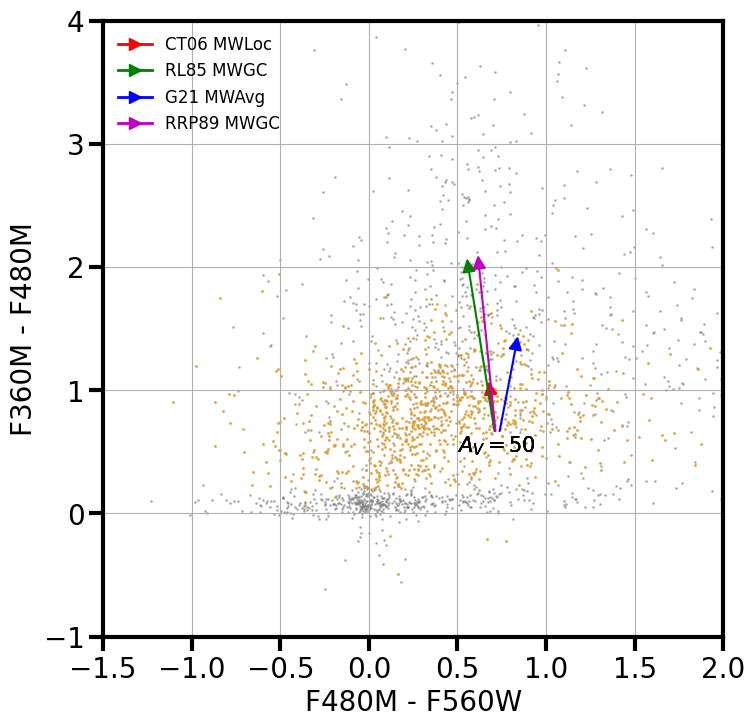

In [81]:
# 360-480 vs 480-560
fig = plt.figure(figsize=(8,8))
ax = fig.add_subplot(111)
ax.scatter(f480m_mag[0] - f560w_mag[0], f360m_mag[0]-f480m_mag[0], s=1, c='gray', alpha=0.5)
ax.scatter(f480m_mag[0][idx_red_sources] - f560w_mag[0][idx_red_sources],
        f360m_mag[0][idx_red_sources]-f480m_mag[0][idx_red_sources], s=1, c='orange', alpha=0.5)
#ax.plot(parsec_mags['f162m'][age_idx] - parsec_mags['f210m'][age_idx], parsec_mags['f360m'][age_idx]-parsec_mags['f560w'][age_idx], color='r')
for ext_model, labels, c in zip([CT06_MWLoc(), RL85_MWGC(), G21_MWAvg(), RRP89_MWGC(), G24_SMCAvg()], ['CT06 MWLoc', 'RL85 MWGC', 'G21 MWAvg', 'RRP89 MWGC', 'G24 SMCAvg'], colorlist):
    print(ext_model)
    plot_extvec_ccd(ax, color1=('f480m', 'f560w'), color2=('f360m', 'f480m'),
                     ext=ext_model, extvec_scale=50, color=c,
                      start=(0.5,0.5), label=labels)
#ax.plot([0,6], [0.15, 1.65], c='k', ls='dashed')
ax.grid()
#ax.text(3,1.7, 'YSOs', fontsize=15, color='k')
#ax.text(3,0, 'embedded MS stars', fontsize=15, color='k')
plt.xlabel('F480M - F560W')
plt.ylabel('F360M - F480M')
ax.set_ylim(-1,4)
ax.set_xlim(-1.5,2)
ax.legend(fontsize=12, frameon=False)

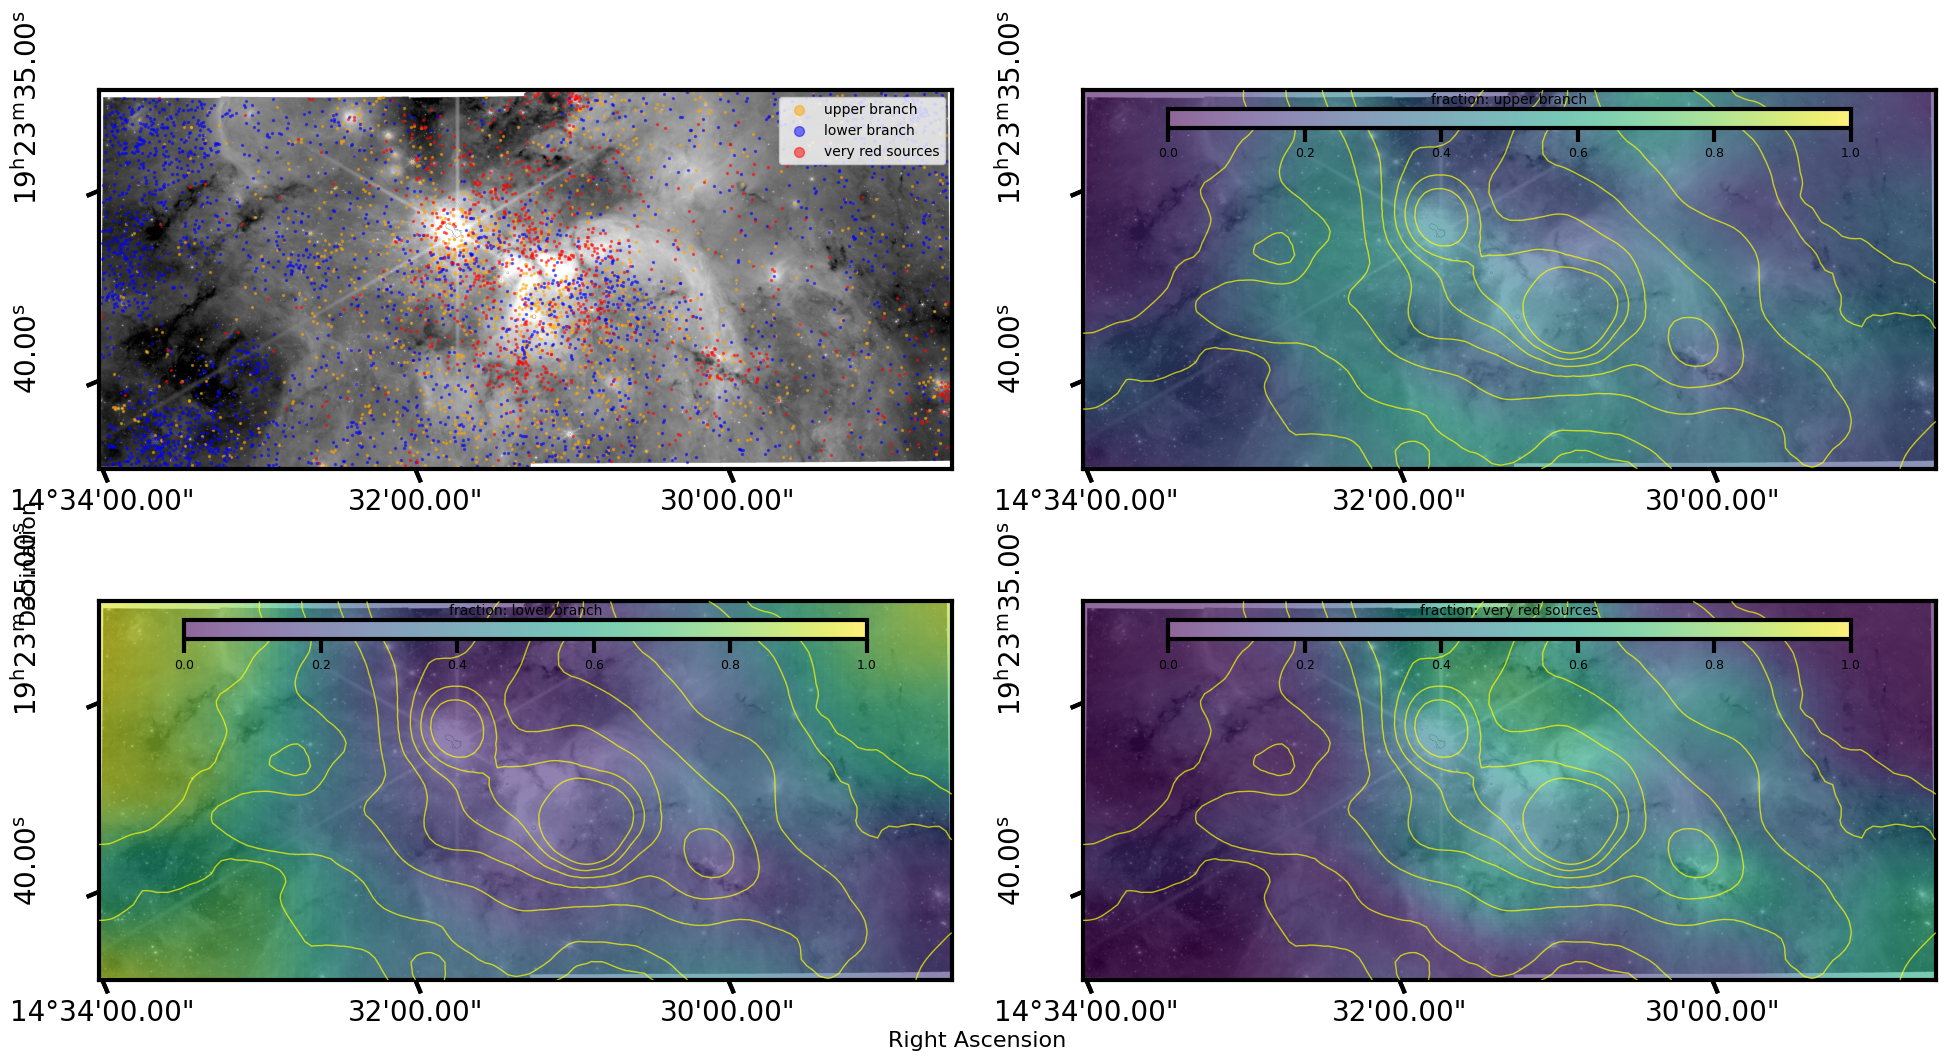

In [82]:
from astropy.visualization import simple_norm
from scipy.stats import gaussian_kde
from matplotlib.colors import LogNorm
from matplotlib.gridspec import GridSpec

# imshow the img and spatial distribution of the three populations
wcs_f480m = WCS(f480m_header)
f480m_data = fits.getdata(image_filenames['f480m'], ext=('SCI', 1))

skycoord_ref = catalog['skycoord_ref']
pixcoord_ref = WCS(f480m_header).all_world2pix(skycoord_ref.ra.deg, skycoord_ref.dec.deg, 0)


def format_wcs_axes(ax):
    # tick formatting only -- axis labels are shared across the figure via fig.supxlabel/supylabel
    ra = lon = ax.coords['ra']
    dec = lat = ax.coords['dec']
    ra.set_major_formatter('hh:mm:ss.ss')
    dec.set_major_formatter('dd:mm:ss.ss')
    ra.set_ticklabel(rotation=90, pad=30)
    ra.set_ticks_position('l')
    ra.set_ticklabel_position('l')
    ra.set_axislabel('')
    dec.set_ticks_position('b')
    dec.set_ticklabel_position('b')
    dec.set_axislabel('')


populations = [
    ('upper branch', upper_idx, 'orange'),
    ('lower branch', lower_idx, 'blue'),
    ('very red sources', missing_nir_idx_red, 'r'),
]

fig = plt.figure(figsize=(20, 10))
gs = GridSpec(2, 2, figure=fig, hspace=0.35, wspace=0.15)
panel_slots = [gs[0, 0], gs[0, 1], gs[1, 0], gs[1, 1]]

# --- top-left panel: spatial distribution of all three populations ---
ax = fig.add_subplot(panel_slots[0], projection=wcs_f480m)
norm_f480m = simple_norm(f480m_data, stretch='log', percent=99.)
ax.imshow(f480m_data, origin='lower', cmap='gray', norm=norm_f480m)
for label, idx_mask, color in populations:
    ax.scatter(pixcoord_ref[0][idx_mask], pixcoord_ref[1][idx_mask], s=2, c=color, alpha=0.5, label=label)
ax.legend(markerscale=5, fontsize=10, loc='upper right')
format_wcs_axes(ax)

# --- remaining three panels: spatial fraction of each population relative to all three combined ---
xgrid = np.linspace(0, f480m_data.shape[1], 100)
ygrid = np.linspace(0, f480m_data.shape[0], 100)
Xgrid, Ygrid = np.meshgrid(xgrid, ygrid)
grid_points = np.vstack([Xgrid.ravel(), Ygrid.ravel()])

kdes = []
for label, idx_mask, color in populations:
    xy = np.vstack([pixcoord_ref[0][idx_mask], pixcoord_ref[1][idx_mask]])
    kde = gaussian_kde(xy)
    kdes.append(kde(grid_points).reshape(Xgrid.shape))

total = sum(kdes) + 1e-10

co_planck_fn = '/orange/adamginsburg/jwst/w51/data_reprojected_480/co_planck_reprojected_to_f480m.fits'
co_plank = fits.getdata(co_planck_fn, ext=0)

for slot, (label, idx_mask, color), Z in zip(panel_slots[1:], populations, kdes):
    axi = fig.add_subplot(slot, projection=wcs_f480m)
    axi.imshow(f480m_data, origin='lower', cmap='gray', norm=norm_f480m)
    frac = Z / total
    im = axi.imshow(
        frac,
        origin='lower',
        cmap='viridis',
        alpha=0.6,
        vmin=0, vmax=1,
        extent=[xgrid.min(), xgrid.max(), ygrid.min(), ygrid.max()],
        interpolation='nearest',
    )
    axi.contour(co_plank, levels=[2, 2.78, 5.11, 9.00, 14.44, 21.44, 30.0], colors='yellow', alpha=0.7, linewidths=1)
    cax = axi.inset_axes([0.1, 0.9, 0.8, 0.05], transform=axi.transAxes)
    cbar = plt.colorbar(im, cax=cax, orientation='horizontal')
    cbar.ax.xaxis.set_label_position('top')
    cbar.set_label(f'fraction: {label}', fontsize=10)
    cbar.ax.tick_params(labelsize=9)
    format_wcs_axes(axi)

fig.supxlabel('Right Ascension', fontsize=16)
fig.supylabel('Declination', fontsize=16)
fig.subplots_adjust(left=0.06, right=0.98, bottom=0.08, top=0.97)
plt.savefig('upper_lower_map_cfit003.png')

#tab_upper = catalog[idx_red_sourceㅌ ][idx_upper]
#tab_lower = catalog[idx_red_sources][idx_lower]
#tab_upper.write('/orange/adamginsburg/jwst/w51/catalogs/upper_branch_sources_cleancat.fits')
#tab_lower.write('/orange/adamginsburg/jwst/w51/catalogs/lower_branch_sources_cleancat.fits')


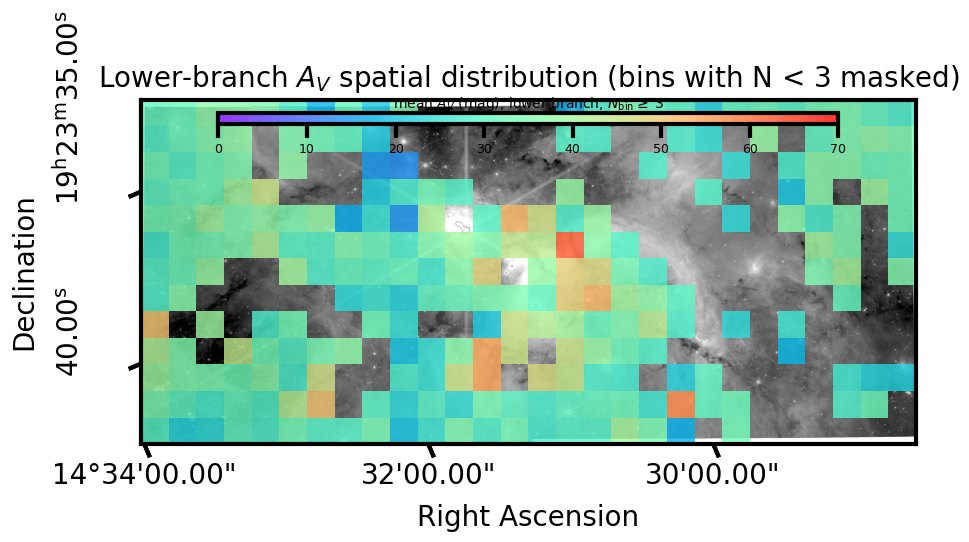

In [83]:
from scipy.stats import binned_statistic_2d

# --- spatial distribution of A_V for the lower-branch sources only ---
# bin sources spatially in pixel space and require a minimum number of
# sources per bin before reporting a mean A_V, so sparsely sampled
# regions don't masquerade as reliable statistics.
min_samples = 3  # minimum sources per spatial bin (~128 bins pass this at bin_size_px=100)
bin_size_px = 200  # spatial bin size in F480M pixels

av_lower = av_estimate[lower_idx]
x_lower = pixcoord_ref[0][lower_idx]
y_lower = pixcoord_ref[1][lower_idx]

nbins_x = max(1, int(round(f480m_data.shape[1] / bin_size_px)))
nbins_y = max(1, int(round(f480m_data.shape[0] / bin_size_px)))
xedges = np.linspace(0, f480m_data.shape[1], nbins_x + 1)
yedges = np.linspace(0, f480m_data.shape[0], nbins_y + 1)

av_mean, _, _, _ = binned_statistic_2d(
    x_lower, y_lower, av_lower, statistic='mean', bins=[xedges, yedges]
)
av_counts, _, _, _ = binned_statistic_2d(
    x_lower, y_lower, av_lower, statistic='count', bins=[xedges, yedges]
)
av_mean_reliable = np.where(av_counts >= min_samples, av_mean, np.nan)

fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(111, projection=wcs_f480m)
ax.imshow(f480m_data, origin='lower', cmap='gray', norm=norm_f480m)

im = ax.imshow(
    av_mean_reliable.T,
    origin='lower',
    cmap='rainbow',
    alpha=0.8,
    vmin=0, vmax=70,
    extent=[xedges.min(), xedges.max(), yedges.min(), yedges.max()],
    interpolation='nearest',
)
cax = ax.inset_axes([0.1, 0.93, 0.8, 0.03], transform=ax.transAxes)
cbar = plt.colorbar(im, cax=cax, orientation='horizontal')
cbar.set_label(r'mean $A_V$ (mag), lower branch, $N_{\rm bin} \geq$ ' + str(min_samples), fontsize=10)
cbar.ax.xaxis.set_label_position('top')
cbar.ax.tick_params(labelsize=9)

format_wcs_axes(ax)
ax.set_xlabel('Right Ascension')
ax.set_ylabel('Declination')
ax.set_title(f'Lower-branch $A_V$ spatial distribution (bins with N < {min_samples} masked)')
plt.savefig('av_lower_branch_spatial_map_cfit003.png', bbox_inches='tight')
plt.show()


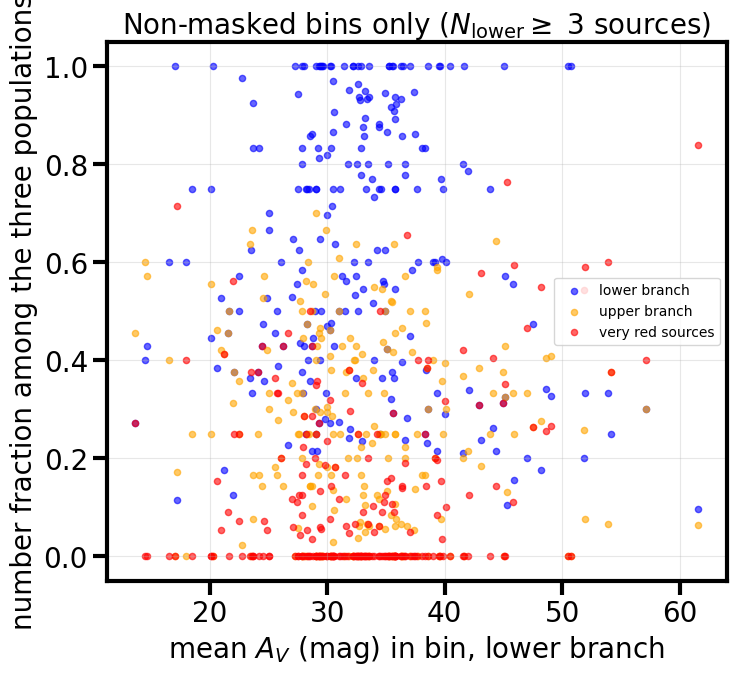

In [84]:
# --- relate A_V (lower-branch map, non-masked bins) to the number fraction ---
# --- of the three populations (lower/upper branch, very red sources) in each bin ---
populations_for_frac = {
    'lower branch': (lower_idx, 'blue'),
    'upper branch': (upper_idx, 'orange'),
    'very red sources': (missing_nir_idx_red, 'red'),
}

pop_counts = {}
for label, (idx_mask, color) in populations_for_frac.items():
    x_pop = pixcoord_ref[0][idx_mask]
    y_pop = pixcoord_ref[1][idx_mask]
    counts, _, _, _ = binned_statistic_2d(x_pop, y_pop, x_pop, statistic='count', bins=[xedges, yedges])
    pop_counts[label] = counts

total_pop_counts = sum(pop_counts.values())
reliable_bin = av_counts >= min_samples  # same bins as the non-masked A_V map
valid_bin = reliable_bin & (total_pop_counts > 0)

fig, ax = plt.subplots(figsize=(8, 7))
with np.errstate(invalid='ignore', divide='ignore'):
    for label, (idx_mask, color) in populations_for_frac.items():
        frac = pop_counts[label] / total_pop_counts
        ax.scatter(av_mean[valid_bin], frac[valid_bin], s=20, c=color, alpha=0.6, label=label)

ax.set_xlabel(r'mean $A_V$ (mag) in bin, lower branch')
ax.set_ylabel('number fraction among the three populations')
ax.set_title(f'Non-masked bins only ($N_{{\\rm lower}} \\geq$ {min_samples} sources)')
ax.set_ylim(-0.05, 1.05)
ax.legend(fontsize=10)
ax.grid(alpha=0.3)
plt.savefig('av_vs_population_fraction_cfit003.png', bbox_inches='tight')
plt.show()


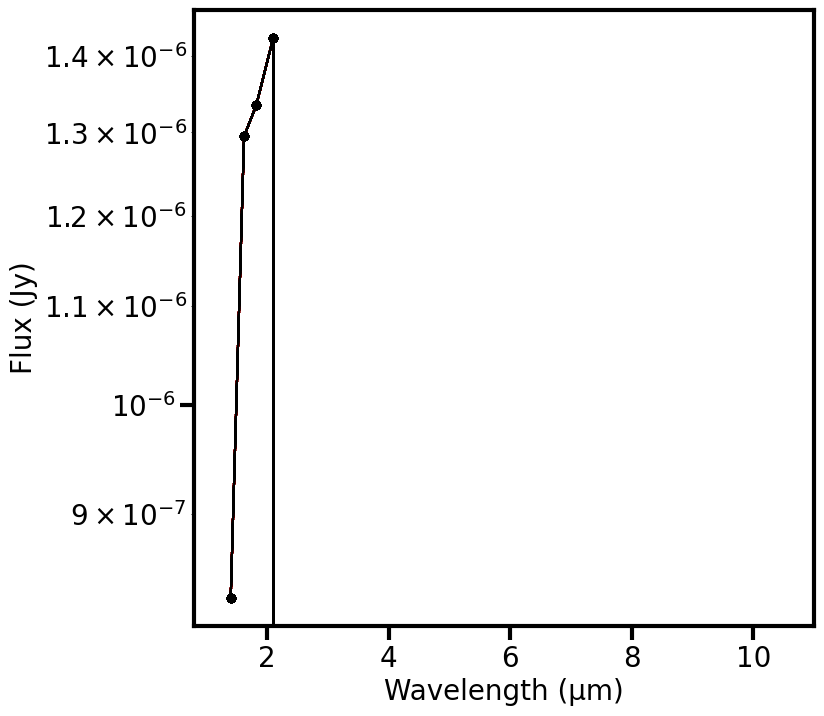

In [85]:
#plot SEDS of random 100 sources from upper and lower branch
def plot_SED(ax, catalog, idx_mask, color='k'):
    filter_names = ['f140m', 'f162m', 'f182m',  'f210m', 'f335m', 'f360m', 'f410m', 'f480m', 'f560w', 'f770w', 'f1000w', 'f1280w', 'f2100w']
    wavelengths = np.array([int(f[1:-1]) / 100 for f in filter_names]) * u.um

    src_idx = np.where(idx_mask)[0]   # convert boolean mask -> integer indices
    # get random 100 indices from src_idx
    if len(src_idx) > 100:
        src_idx = np.random.choice(src_idx, size=100, replace=False)
    # optional color normalization
   # norm = LogNorm(vmin=10, vmax=100)

    for i in src_idx:
        flux_arr = []
        for filtername in filter_names:
            flux = (
                catalog['flux_fit_' + filtername][i] * u.MJy / u.sr
                * WCS(fits.getheader(image_filenames[filtername], ext=('SCI', 1))).proj_plane_pixel_area()
            ).to(u.Jy)
            flux_arr.append(flux.value)

        ax.plot(wavelengths.value, flux_arr, marker='o', alpha=0.1,
                color=color)

    #cbar = plt.colorbar(plt.cm.ScalarMappable(norm=norm, cmap=cmap), ax=ax)
    #cbar.set_label('Paα EW (Å)')
    ax.set_yscale('log')
    ax.set_xlabel('Wavelength (µm)')
    ax.set_ylabel('Flux (Jy)')
    ax.set_xlim(0.8, 11)
fig = plt.figure(figsize=(8,8))
ax = fig.add_subplot(111)
#upper_idx_random = np.random.choice(np.where(upper_idx)[0], size=100, replace=False)
#lower_idx_random = np.random.choice(np.where(lower_idx)[0], size=100, replace=False)
plot_SED(ax, catalog, idx_mask=upper_idx, color='r')
plot_SED(ax, catalog, idx_mask=lower_idx)

